### 105. Participation entropy of channel covariance

Participation entropy is the Rényi order-2 entropy H2=-ln sum p_i^2; exp(H2)=1/sum p_i^2 is the participation ratio.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


participation entropy H2= 0.7678655910194465 participation ratio= 2.1551613454240357


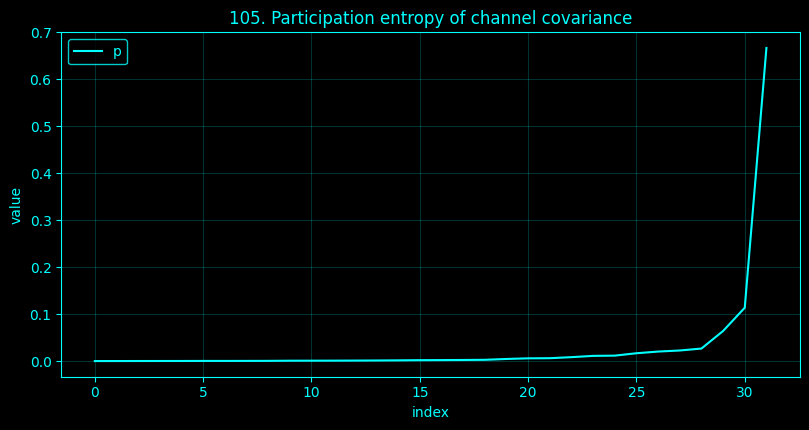

In [79]:
# =======================================================
# 105. Participation entropy of channel covariance
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Participation entropy is the Rényi order-2 entropy H2=-ln sum p_i^2; exp(H2)=1/sum
# p_i^2 is the participation ratio.
# =======================================================
def _entropy_method_105():
    y = _ent_y
    X = _ent_x
    p = _eig_probs(np.cov(X, rowvar=False))
    H2 = -np.log(np.sum(p * p) + ENT_EPS)
    _ent_print_args = ['participation entropy H2=', H2, 'participation ratio=', np.exp(H2)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_105()
_ent_auto_plot(105, 'Participation entropy of channel covariance', _ent_method_ns, ['y', 'X', 'p', 'H2', '_ent_print_args'])


### 106. Multiscale SVD entropy

Multiscale SVD entropy coarse-grains the multichannel time series and recomputes singular-value energy entropy at each scale.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


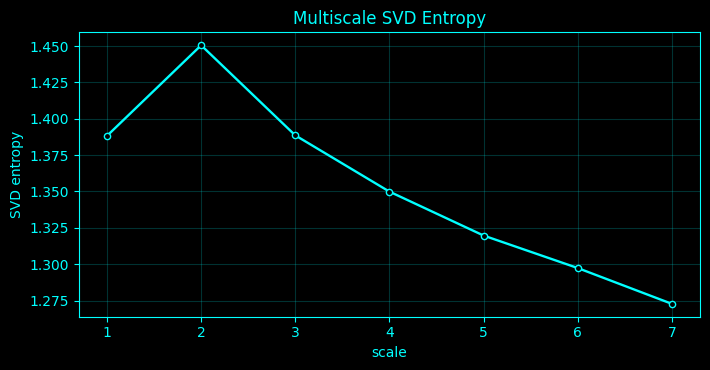

In [80]:
# =======================================================
# 106. Multiscale SVD entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Multiscale SVD entropy coarse-grains the multichannel time series and recomputes
# singular-value energy entropy at each scale.
# =======================================================
def _entropy_method_106():
    y = _ent_y
    X = _ent_x
    sc = np.arange(1, _ENT_SPEED['scales'] + 1)
    v = []
    for s in sc:
        n = len(X) // s
        cg = X[:n * s].reshape(n, s, X.shape[1]).mean(1)
        v.append(_svd_entropy(cg)[0])
    _line(sc, v, 'Multiscale SVD Entropy', 'scale', 'SVD entropy')
    return locals()
_ent_method_ns = _entropy_method_106()


### 107. Time-resolved SVD entropy

Time-resolved SVD entropy applies singular-value energy entropy to successive multichannel windows.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


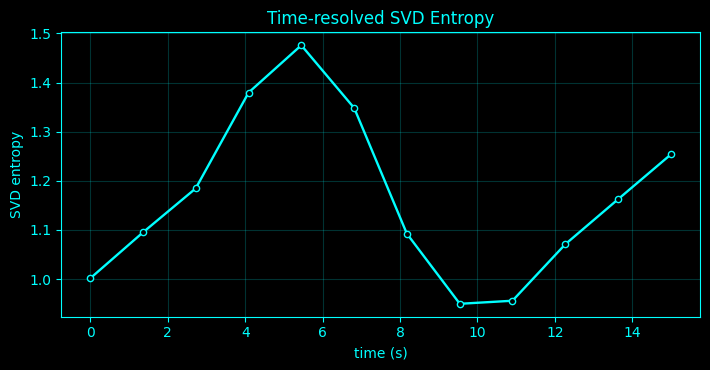

In [81]:
# =======================================================
# 107. Time-resolved SVD entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Time-resolved SVD entropy applies singular-value energy entropy to successive
# multichannel windows.
# =======================================================
def _entropy_method_107():
    y = _ent_y
    X = _ent_x
    W = max(200, int(3 * _ent_fs))
    starts = np.linspace(0, max(0, len(X) - W), _ENT_SPEED['windows']).astype(int)
    v = [_svd_entropy(X[s:s + W])[0] for s in starts]
    _line(starts / _ent_fs, v, 'Time-resolved SVD Entropy', 'time (s)', 'SVD entropy')
    return locals()
_ent_method_ns = _entropy_method_107()


### 108. Lempel-Ziv complexity entropy proxy

Lempel-Ziv complexity counts new phrases in a symbolic sequence. The normalized LZ76 quantity c(n) ln n/[n ln alphabet] is used as an entropy-rate/algorithmic-complexity proxy.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [82]:
# =======================================================
# 108. Lempel-Ziv complexity entropy proxy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Lempel-Ziv complexity counts new phrases in a symbolic sequence. The normalized LZ76
# quantity c(n) ln n/[n ln alphabet] is used as an entropy-rate/algorithmic-complexity proxy.
# =======================================================
def _entropy_method_108():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    _ent_print_args = ['Lempel-Ziv normalized complexity entropy proxy=', _lz_norm(sym, 4)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_108()
_ent_auto_plot(108, 'Lempel-Ziv complexity entropy proxy', _ent_method_ns, ['y', 'X', 'sym', '_ent_print_args'])


Lempel-Ziv normalized complexity entropy proxy= 0.8958059470155094


### 109. Permutation Lempel-Ziv complexity

Permutation Lempel-Ziv complexity first converts the signal to ordinal-pattern symbols and then applies normalized LZ76 parsing.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


Permutation Lempel-Ziv complexity= 1.080080038390947


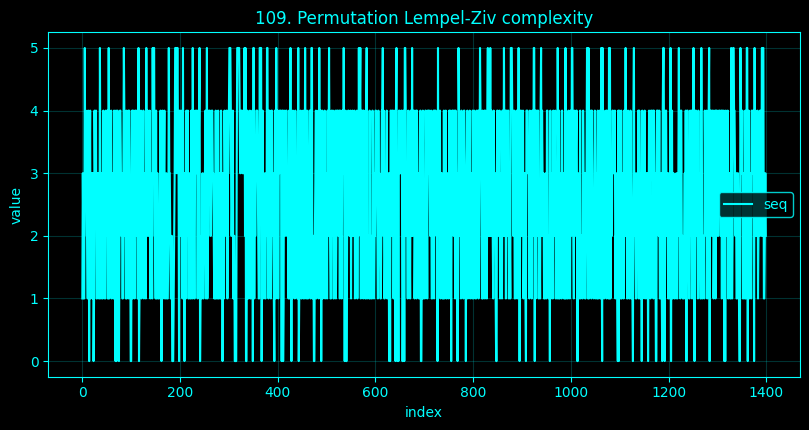

In [83]:
# =======================================================
# 109. Permutation Lempel-Ziv complexity
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Permutation Lempel-Ziv complexity first converts the signal to ordinal-pattern symbols
# and then applies normalized LZ76 parsing.
# =======================================================
def _entropy_method_109():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    labs = _ordinal_labels(y, 3)
    ids = {k: j for j, k in enumerate(sorted(set(labs)))}
    seq = [ids[k] for k in labs]
    _ent_print_args = ['Permutation Lempel-Ziv complexity=', _lz_norm(seq, max(2, len(ids)))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_109()
_ent_auto_plot(109, 'Permutation Lempel-Ziv complexity', _ent_method_ns, ['y', 'X', 'sym', 'labs', 'ids', 'seq', '_ent_print_args', 'k', 'j'])


### 110. Multiscale Lempel-Ziv complexity

Multiscale Lempel-Ziv complexity coarse-grains the signal, symbolizes each scale, and evaluates normalized LZ76 complexity.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


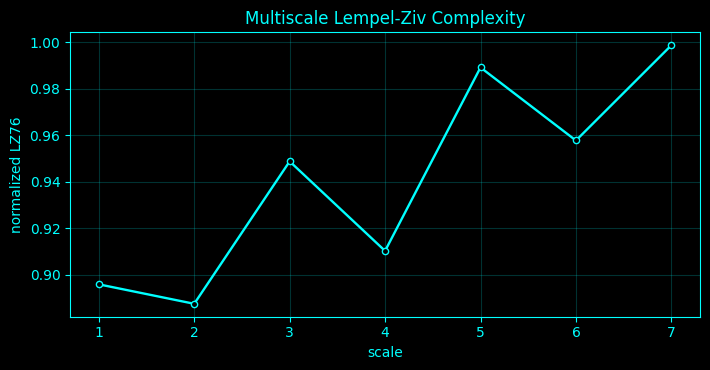

In [84]:
# =======================================================
# 110. Multiscale Lempel-Ziv complexity
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Multiscale Lempel-Ziv complexity coarse-grains the signal, symbolizes each scale, and
# evaluates normalized LZ76 complexity.
# =======================================================
def _entropy_method_110():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    sc = np.arange(1, _ENT_SPEED['scales'] + 1)
    v = [_lz_norm(_symbolize(_coarse(y, int(s)), 4), 4) for s in sc]
    _line(sc, v, 'Multiscale Lempel-Ziv Complexity', 'scale', 'normalized LZ76')
    return locals()
_ent_method_ns = _entropy_method_110()


### 111. Compression entropy

Compression entropy uses lossless compressed length per symbol as a practical entropy-rate proxy; finite headers and compressor modeling make it estimator-dependent.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


compression entropy proxy bits/symbol= 1.4435555555555555 compression ratio= 0.18044444444444444


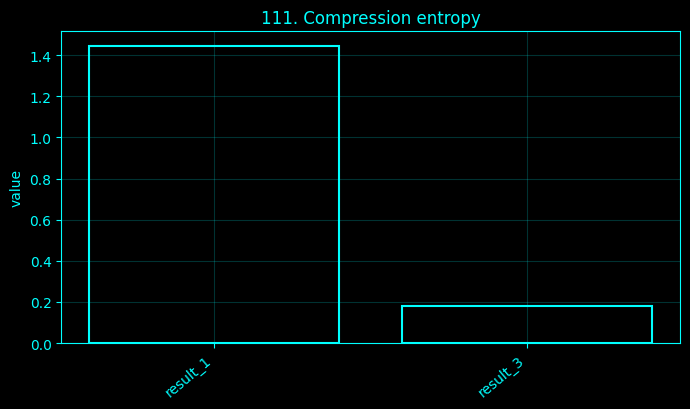

In [85]:
# =======================================================
# 111. Compression entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Compression entropy uses lossless compressed length per symbol as a practical entropy-
# rate proxy; finite headers and compressor modeling make it estimator-dependent.
# =======================================================
def _entropy_method_111():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    raw = max(1, len(_to_bytes_symbols(sym)))
    _ent_print_args = ['compression entropy proxy bits/symbol=', _comp_bits(sym) / len(sym), 'compression ratio=', len(zlib.compress(_to_bytes_symbols(sym), 9)) / raw]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_111()
_ent_auto_plot(111, 'Compression entropy', _ent_method_ns, ['y', 'X', 'sym', 'raw', '_ent_print_args'])


### 112. Normalized compression distance entropy

Normalized compression distance is NCD(x,y)=[C(xy)-min(C(x),C(y))]/max(C(x),C(y)), a compressor-based similarity proxy.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [86]:
# =======================================================
# 112. Normalized compression distance entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Normalized compression distance is NCD(x,y)=[C(xy)-min(C(x),C(y))]/max(C(x),C(y)), a
# compressor-based similarity proxy.
# =======================================================
def _entropy_method_112():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    a = _symbolize(_ent_x[:, 0], 4)
    b = _symbolize(_ent_x[:, 1], 4)
    _ent_print_args = ['normalized compression distance ch0-ch1=', _ncd(a, b)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_112()
_ent_auto_plot(112, 'Normalized compression distance entropy', _ent_method_ns, ['y', 'X', 'sym', 'a', 'b', '_ent_print_args'])


normalized compression distance ch0-ch1= 0.9409368635437881


### 113. Block Decomposition Method entropy proxy

Block Decomposition Method has structure BDM=sum_j[K(block_j)+log2 n_j]. Because no certified CTM table is bundled, K(block) is explicitly approximated by lossless compressed block length.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [87]:
# =======================================================
# 113. Block Decomposition Method entropy proxy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Block Decomposition Method has structure BDM=sum_j[K(block_j)+log2 n_j]. Because no
# certified CTM table is bundled, K(block) is explicitly approximated by lossless compressed block
# length.
# =======================================================
def _entropy_method_113():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    _ent_print_args = ['BDM entropy proxy bits=', _bdm_proxy(sym), '(compressed-block K proxy; no CTM table claimed)']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_113()
_ent_auto_plot(113, 'Block Decomposition Method entropy proxy', _ent_method_ns, ['y', 'X', 'sym', '_ent_print_args'])


BDM entropy proxy bits= 18881.479780264028 (compressed-block K proxy; no CTM table claimed)


### 114. Algorithmic complexity entropy proxy

Approximate algorithmic complexity is estimated by the length of a losslessly compressed symbolic representation; it is a computable proxy, not exact Kolmogorov complexity.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [88]:
# =======================================================
# 114. Algorithmic complexity entropy proxy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Approximate algorithmic complexity is estimated by the length of a losslessly
# compressed symbolic representation; it is a computable proxy, not exact Kolmogorov complexity.
# =======================================================
def _entropy_method_114():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    _ent_print_args = ['algorithmic complexity proxy compressed bits/symbol=', _comp_bits(sym) / len(sym)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_114()
_ent_auto_plot(114, 'Algorithmic complexity entropy proxy', _ent_method_ns, ['y', 'X', 'sym', '_ent_print_args'])


algorithmic complexity proxy compressed bits/symbol= 1.4435555555555555


### 115. Context-tree weighting entropy rate

Context-Tree Weighting recursively mixes a Krichevsky-Trofimov estimator at each binary context node with the product of its child models: P_w=0.5 P_KT+0.5 P_w0 P_w1. Entropy rate is -ln P_w/n.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [89]:
# =======================================================
# 115. Context-tree weighting entropy rate
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Context-Tree Weighting recursively mixes a Krichevsky-Trofimov estimator at each binary
# context node with the product of its child models: P_w=0.5 P_KT+0.5 P_w0 P_w1. Entropy rate is -ln
# P_w/n.
# =======================================================
def _entropy_method_115():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    bits = (y > np.median(y)).astype(int)
    lp = _ctw_logprob(bits, depth=5)
    _ent_print_args = ['CTW entropy-rate estimate bits/sample=', -lp / (len(bits) * np.log(2))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_115()
_ent_auto_plot(115, 'Context-tree weighting entropy rate', _ent_method_ns, ['y', 'X', 'sym', 'bits', 'lp', '_ent_print_args'])


CTW entropy-rate estimate bits/sample= 0.3494432891028458


### 116. Approximate Kolmogorov complexity proxy

Kolmogorov complexity is uncomputable in general. This cell therefore reports only a lossless-compression upper-bound proxy and labels it accordingly.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


approximate Kolmogorov complexity proxy bits= 3248 for 2250 symbols


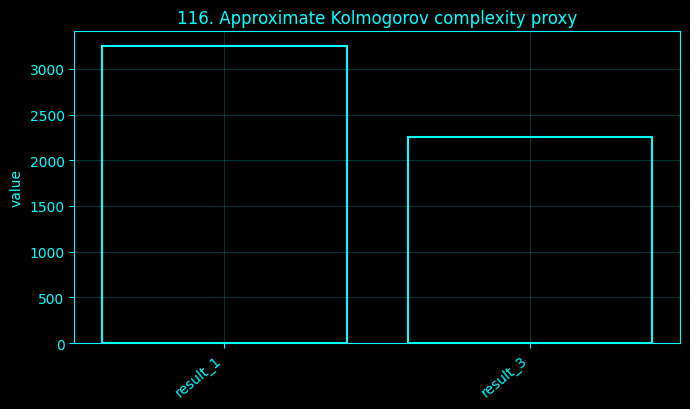

In [90]:
# =======================================================
# 116. Approximate Kolmogorov complexity proxy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Kolmogorov complexity is uncomputable in general. This cell therefore reports only a
# lossless-compression upper-bound proxy and labels it accordingly.
# =======================================================
def _entropy_method_116():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    _ent_print_args = ['approximate Kolmogorov complexity proxy bits=', _comp_bits(sym), 'for', len(sym), 'symbols']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_116()
_ent_auto_plot(116, 'Approximate Kolmogorov complexity proxy', _ent_method_ns, ['y', 'X', 'sym', '_ent_print_args'])


### 117. Entropy rate from Markov partitions

A Markov-partition entropy-rate estimate is H(S_t|S_t-1)=H(S_t,S_t-1)-H(S_t-1) after amplitude symbolization.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [91]:
# =======================================================
# 117. Entropy rate from Markov partitions
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: A Markov-partition entropy-rate estimate is H(S_t|S_t-1)=H(S_t,S_t-1)-H(S_t-1) after
# amplitude symbolization.
# =======================================================
def _entropy_method_117():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    _ent_print_args = ['Markov-partition entropy rate H(S_t|S_t-1)=', _cond_entropy_markov(sym, 1)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_117()
_ent_auto_plot(117, 'Entropy rate from Markov partitions', _ent_method_ns, ['y', 'X', 'sym', '_ent_print_args'])


Markov-partition entropy rate H(S_t|S_t-1)= 0.9586855122000468


### 118. Symbolic entropy rate

Symbolic entropy rate is estimated from block-entropy increments h_L=H(L)-H(L-1), which converge toward the entropy rate as L grows under suitable conditions.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


symbolic entropy-rate block increment= 0.5498781465865368 block entropies= [1.3862939660581102, 2.344979478258157, 2.9790353321066267, 3.598090953013964, 4.147969099600501]


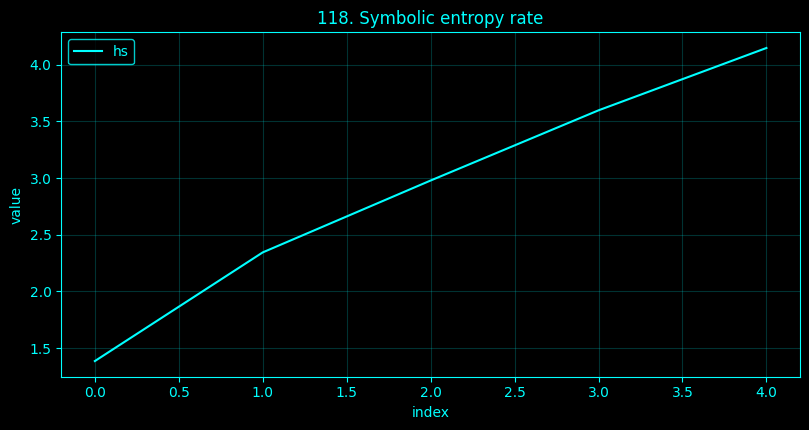

In [92]:
# =======================================================
# 118. Symbolic entropy rate
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Symbolic entropy rate is estimated from block-entropy increments h_L=H(L)-H(L-1), which
# converge toward the entropy rate as L grows under suitable conditions.
# =======================================================
def _entropy_method_118():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    hs = [_block_entropy(sym, L) for L in range(1, 6)]
    _ent_print_args = ['symbolic entropy-rate block increment=', hs[-1] - hs[-2], 'block entropies=', hs]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_118()
_ent_auto_plot(118, 'Symbolic entropy rate', _ent_method_ns, ['y', 'X', 'sym', 'hs', '_ent_print_args', 'L'])


### 119. Ordinal entropy rate

Ordinal entropy rate applies conditional entropy to the sequence of ordinal patterns rather than amplitude symbols.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [93]:
# =======================================================
# 119. Ordinal entropy rate
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Ordinal entropy rate applies conditional entropy to the sequence of ordinal patterns
# rather than amplitude symbols.
# =======================================================
def _entropy_method_119():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    labs = _ordinal_labels(y, 3)
    ids = {k: j for j, k in enumerate(sorted(set(labs)))}
    s = np.array([ids[k] for k in labs])
    _ent_print_args = ['ordinal entropy rate H(P_t|P_t-1)=', _cond_entropy_markov(s, 1)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_119()
_ent_auto_plot(119, 'Ordinal entropy rate', _ent_method_ns, ['y', 'X', 'sym', 'labs', 'ids', 's', '_ent_print_args', 'j', 'k'])


ordinal entropy rate H(P_t|P_t-1)= 1.6232326484420208


### 120. Block entropy growth curves

Block entropy H(L) is Shannon entropy of length-L symbolic words. Its growth curve separates extensive entropy-rate growth from subextensive structure.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


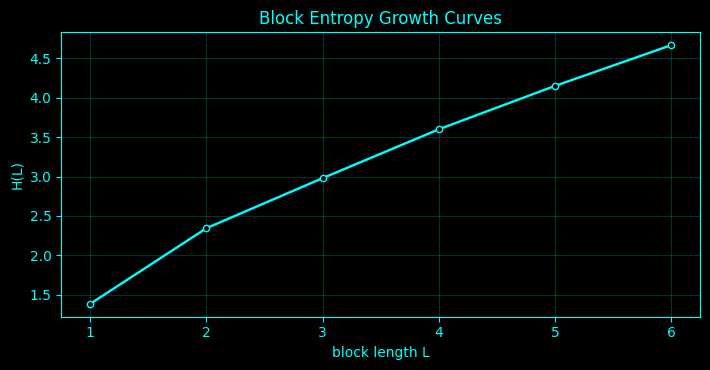

In [94]:
# =======================================================
# 120. Block entropy growth curves
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Block entropy H(L) is Shannon entropy of length-L symbolic words. Its growth curve
# separates extensive entropy-rate growth from subextensive structure.
# =======================================================
def _entropy_method_120():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    L = np.arange(1, 7)
    H = [_block_entropy(sym, int(k)) for k in L]
    _line(L, H, 'Block Entropy Growth Curves', 'block length L', 'H(L)')
    return locals()
_ent_method_ns = _entropy_method_120()


### 121. Excess entropy

Excess entropy is the subextensive intercept E=lim[H(L)-h_mu L]. The finite-data implementation estimates h_mu from the tail block-entropy slope and then estimates the intercept.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


finite-block excess entropy intercept≈ 1.4720666662443327 entropy-rate tail≈ 0.5329193082227255


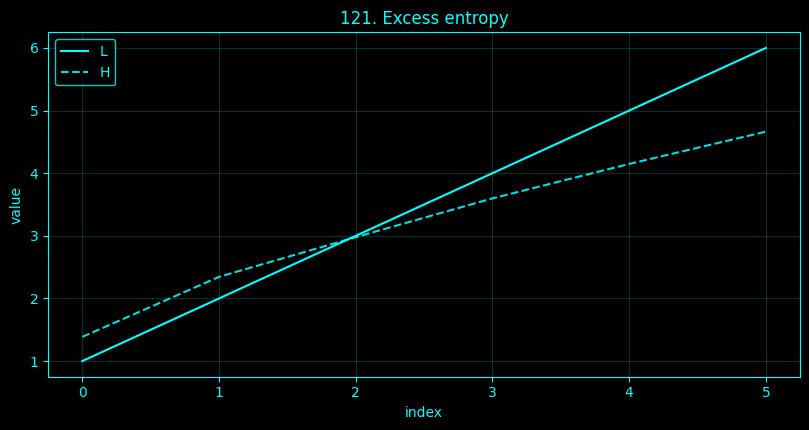

In [95]:
# =======================================================
# 121. Excess entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Excess entropy is the subextensive intercept E=lim[H(L)-h_mu L]. The finite-data
# implementation estimates h_mu from the tail block-entropy slope and then estimates the intercept.
# =======================================================
def _entropy_method_121():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    L = np.arange(1, 7)
    H = np.array([_block_entropy(sym, int(k)) for k in L])
    h = np.mean(np.diff(H)[-2:])
    E = float(np.mean(H[-3:] - h * L[-3:]))
    _ent_print_args = ['finite-block excess entropy intercept≈', E, 'entropy-rate tail≈', h]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_121()
_ent_auto_plot(121, 'Excess entropy', _ent_method_ns, ['y', 'X', 'sym', 'L', 'H', 'h', 'E', '_ent_print_args', 'k'])


### 122. Predictive information

Predictive information is mutual information between past and future blocks, I(P;F)=H(P)+H(F)-H(P,F).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [96]:
# =======================================================
# 122. Predictive information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Predictive information is mutual information between past and future blocks,
# I(P;F)=H(P)+H(F)-H(P,F).
# =======================================================
def _entropy_method_122():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    L = 3
    past = np.array([sum((int(sym[t - k - 1]) * 4 ** k for k in range(L))) for t in range(L, len(sym) - L)])
    future = np.array([sum((int(sym[t + k]) * 4 ** k for k in range(L))) for t in range(L, len(sym) - L)])
    _ent_print_args = ['predictive information I(past;future)=', _mi_symbols(past, future)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_122()
_ent_auto_plot(122, 'Predictive information', _ent_method_ns, ['y', 'X', 'sym', 'L', 'past', 'future', '_ent_print_args', 't', 'k'])


predictive information I(past;future)= 1.2952748861168395


### 123. Statistical complexity

Statistical complexity C_mu is Shannon entropy of causal-state occupancy. Causal states are approximated here by finite histories with equal rounded predictive next-symbol distributions.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


statistical complexity C_mu≈H(causal state)= 2.9650932052288335 states= 33


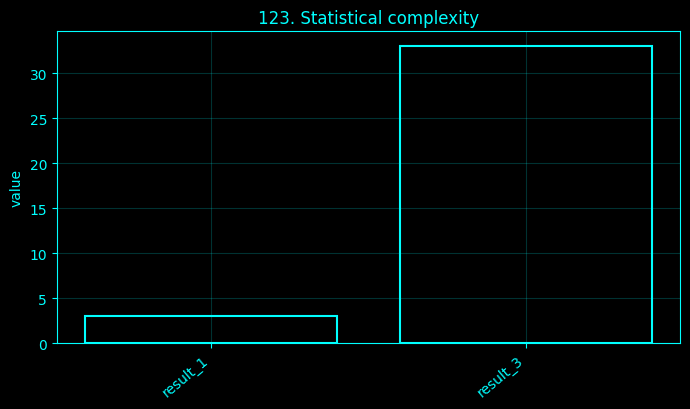

In [97]:
# =======================================================
# 123. Statistical complexity
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Statistical complexity C_mu is Shannon entropy of causal-state occupancy. Causal states
# are approximated here by finite histories with equal rounded predictive next-symbol distributions.
# =======================================================
def _entropy_method_123():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    ss, mp, states, counts = _causal_states(sym, L=3)
    h = _H(_p_from_labels(ss[ss >= 0]))
    _ent_print_args = ['statistical complexity C_mu≈H(causal state)=', h, 'states=', len(states)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_123()
_ent_auto_plot(123, 'Statistical complexity', _ent_method_ns, ['y', 'X', 'sym', 'h', '_ent_print_args', 'ss', 'mp', 'states', 'counts'])


### 124. Causal-state entropy

Causal-state entropy is H(S) over inferred predictive-equivalence states; it is the same information quantity underlying statistical complexity for an epsilon-machine.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [98]:
# =======================================================
# 124. Causal-state entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Causal-state entropy is H(S) over inferred predictive-equivalence states; it is the
# same information quantity underlying statistical complexity for an epsilon-machine.
# =======================================================
def _entropy_method_124():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    ss, mp, states, counts = _causal_states(sym, L=3)
    h = _H(_p_from_labels(ss[ss >= 0]))
    _ent_print_args = ['causal-state entropy=', h]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_124()
_ent_auto_plot(124, 'Causal-state entropy', _ent_method_ns, ['y', 'X', 'sym', 'h', '_ent_print_args', 'ss', 'mp', 'states', 'counts'])


causal-state entropy= 2.9650932052288335


### 125. ε-machine entropy

An epsilon-machine is the unifilar state model formed by predictive-equivalence causal states. The cell reports the finite-history approximation, state entropy, and observed state-transition structure.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


epsilon-machine finite-history state entropy= 2.9650932052288335 state transitions= 87


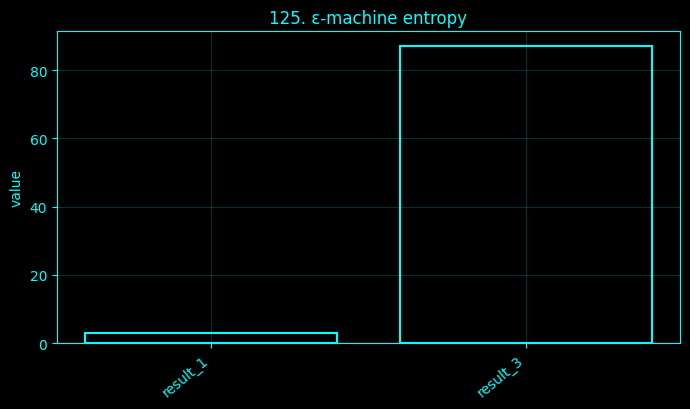

In [99]:
# =======================================================
# 125. ε-machine entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: An epsilon-machine is the unifilar state model formed by predictive-equivalence causal
# states. The cell reports the finite-history approximation, state entropy, and observed state-
# transition structure.
# =======================================================
def _entropy_method_125():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    ss, mp, states, counts = _causal_states(sym, L=3)
    h = _H(_p_from_labels(ss[ss >= 0]))
    rows = []
    for a, b in zip(ss[:-1], ss[1:]):
        if a >= 0 and b >= 0:
            rows.append((int(a), int(b)))
    _ent_print_args = ['epsilon-machine finite-history state entropy=', h, 'state transitions=', len(set(rows))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_125()
_ent_auto_plot(125, 'ε-machine entropy', _ent_method_ns, ['y', 'X', 'sym', 'h', 'rows', '_ent_print_args', 'ss', 'mp', 'states', 'counts', 'a', 'b'])


### 126. Active Information Storage

Active Information Storage is I(X_past;X_t), the information in a process past that predicts its current value.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [100]:
# =======================================================
# 126. Active Information Storage
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Active Information Storage is I(X_past;X_t), the information in a process past that
# predicts its current value.
# =======================================================
def _entropy_method_126():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    L = 3
    n = len(sym) - L
    past = np.array([sum((int(sym[t - k - 1]) * 4 ** k for k in range(L))) for t in range(L, len(sym))])
    cur = sym[L:]
    Hcur = _H(_p_from_labels(cur))
    Hjoint = _joint_symbol_entropy(past, cur)
    Hpast = _H(_p_from_labels(past))
    AIS = Hpast + Hcur - Hjoint
    Hpred = Hjoint - Hpast
    _ent_print_args = ['Active Information Storage I(past;current)=', AIS]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_126()
_ent_auto_plot(126, 'Active Information Storage', _ent_method_ns, ['y', 'X', 'sym', 'L', 'n', 'past', 'cur', 'Hcur', 'Hjoint', 'Hpast', 'AIS', 'Hpred', '_ent_print_args', 't', 'k'])


Active Information Storage I(past;current)= 0.7677175251291781


### 127. Local Active Information Storage

Local Active Information Storage is the pointwise log ratio log[p(x_t|past)/p(x_t)], whose expectation is AIS.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


Local AIS mean= 0.7677175251291785 median= 1.0646382915981125


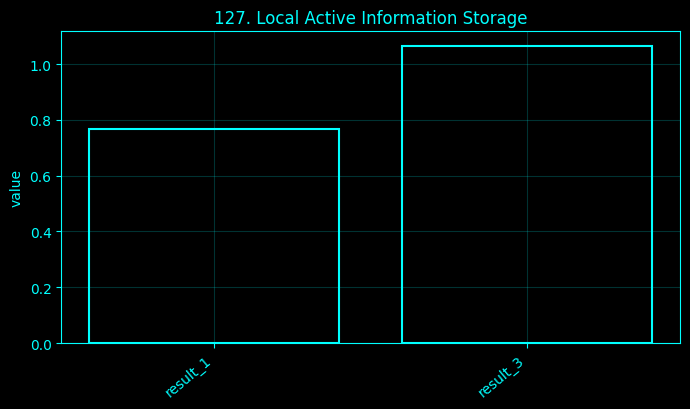

In [101]:
# =======================================================
# 127. Local Active Information Storage
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Local Active Information Storage is the pointwise log ratio log[p(x_t|past)/p(x_t)],
# whose expectation is AIS.
# =======================================================
def _entropy_method_127():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    L = 3
    n = len(sym) - L
    past = np.array([sum((int(sym[t - k - 1]) * 4 ** k for k in range(L))) for t in range(L, len(sym))])
    cur = sym[L:]
    Hcur = _H(_p_from_labels(cur))
    Hjoint = _joint_symbol_entropy(past, cur)
    Hpast = _H(_p_from_labels(past))
    AIS = Hpast + Hcur - Hjoint
    Hpred = Hjoint - Hpast
    pc = Counter(cur)
    pp = Counter(past)
    pj = Counter(zip(past, cur))
    N = len(cur)
    vals = [np.log((pj[a, b] * N + ENT_EPS) / (pp[a] * pc[b] + ENT_EPS)) for a, b in zip(past, cur)]
    _ent_print_args = ['Local AIS mean=', float(np.mean(vals)), 'median=', float(np.median(vals))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_127()
_ent_auto_plot(127, 'Local Active Information Storage', _ent_method_ns, ['y', 'X', 'sym', 'L', 'n', 'past', 'cur', 'Hcur', 'Hjoint', 'Hpast', 'AIS', 'Hpred', 'pc', 'pp', 'pj', 'N', 'vals', '_ent_print_args', 't', 'a', 'b', 'k'])


### 128. Predictive entropy

Predictive entropy is conditional uncertainty H(X_t|X_past). It complements AIS through H(X_t)=AIS+H(X_t|past).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [102]:
# =======================================================
# 128. Predictive entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Predictive entropy is conditional uncertainty H(X_t|X_past). It complements AIS through
# H(X_t)=AIS+H(X_t|past).
# =======================================================
def _entropy_method_128():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    L = 3
    n = len(sym) - L
    past = np.array([sum((int(sym[t - k - 1]) * 4 ** k for k in range(L))) for t in range(L, len(sym))])
    cur = sym[L:]
    Hcur = _H(_p_from_labels(cur))
    Hjoint = _joint_symbol_entropy(past, cur)
    Hpast = _H(_p_from_labels(past))
    AIS = Hpast + Hcur - Hjoint
    Hpred = Hjoint - Hpast
    _ent_print_args = ['Predictive entropy H(current|past)=', Hpred]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_128()
_ent_auto_plot(128, 'Predictive entropy', _ent_method_ns, ['y', 'X', 'sym', 'L', 'n', 'past', 'cur', 'Hcur', 'Hjoint', 'Hpast', 'AIS', 'Hpred', '_ent_print_args', 't', 'k'])


Predictive entropy H(current|past)= 0.6185749536375909


### 129. Past-future mutual information

Past-future mutual information is I(P;F) for finite symbolic past and future blocks and is a finite-block predictive-information estimate.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [103]:
# =======================================================
# 129. Past-future mutual information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Past-future mutual information is I(P;F) for finite symbolic past and future blocks and
# is a finite-block predictive-information estimate.
# =======================================================
def _entropy_method_129():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    L = 3
    past = np.array([sum((int(sym[t - k - 1]) * 4 ** k for k in range(L))) for t in range(L, len(sym) - L)])
    future = np.array([sum((int(sym[t + k]) * 4 ** k for k in range(L))) for t in range(L, len(sym) - L)])
    _ent_print_args = ['past-future mutual information=', _mi_symbols(past, future)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_129()
_ent_auto_plot(129, 'Past-future mutual information', _ent_method_ns, ['y', 'X', 'sym', 'L', 'past', 'future', '_ent_print_args', 't', 'k'])


past-future mutual information= 1.2952748861168395


### 130. Entropy-rate asymmetry

For a stationary process the asymptotic Shannon entropy rate is time-reversal invariant. This cell therefore reports finite-history predictive conditional-entropy asymmetry, not a fictitious difference between two exact entropy rates.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [104]:
# =======================================================
# 130. Entropy-rate asymmetry
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For a stationary process the asymptotic Shannon entropy rate is time-reversal
# invariant. This cell therefore reports finite-history predictive conditional-entropy asymmetry, not
# a fictitious difference between two exact entropy rates.
# =======================================================
def _entropy_method_130():
    y = _ent_y
    X = _ent_x
    sym = _symbolize(y, 4)
    hf = _cond_entropy_markov(sym, 3)
    hr = _cond_entropy_markov(sym[::-1], 3)
    _ent_print_args = ['finite-order predictive entropy asymmetry H_fwd-H_rev=', hf - hr, '(asymptotic Shannon entropy rate itself is time-reversal invariant)']
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_130()
_ent_auto_plot(130, 'Entropy-rate asymmetry', _ent_method_ns, ['y', 'X', 'sym', 'hf', 'hr', '_ent_print_args'])


finite-order predictive entropy asymmetry H_fwd-H_rev= 4.440892098500626e-16 (asymptotic Shannon entropy rate itself is time-reversal invariant)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and role — multivariate information-flow helpers for methods 131–177</h3>
<p>This block defines joint/conditional entropy, mutual information, PID, transfer entropy, directed information, and predictive-information utilities. Core identities include \(I(X;Y)=H(X)+H(Y)-H(X,Y)\) and transfer entropy \(T_{X\to Y}=I(X_{t^-};Y_t\mid Y_{t^-})\). PID branches explicitly state their chosen redundancy convention; directed quantities are interpreted under their estimator/model assumptions rather than as unconditional physical causation.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [105]:
# =======================================================
# Shared primitives only; numbered cells below contain the method-specific mathematics.
# SHARED NUMERICAL PRIMITIVES — methods 131–177
# Multivariate information, PID, transfer entropy and directed information.
# =======================================================
def _sym_ch(j,k=4): return _symbolize(_ent_x[:,j],k)

def _Hcols(*cols):
    n=min(map(len,cols));A=np.column_stack([np.asarray(c)[:n] for c in cols]);return _H(_p_from_labels(A))

def _MI(a,b): return float(_H(_p_from_labels(a))+_H(_p_from_labels(b))-_Hcols(a,b))

def _CMI(a,b,c):
    return float(_Hcols(a,c)+_Hcols(b,c)-_H(_p_from_labels(c))-_Hcols(a,b,c))

def _TC(cols):
    return float(sum(_H(_p_from_labels(c)) for c in cols)-_Hcols(*cols))

def _DTC(cols):
    Hjoint=_Hcols(*cols);return float(sum(_Hcols(*[cols[j] for j in range(len(cols)) if j!=i]) for i in range(len(cols)))-(len(cols)-1)*Hjoint)

def _pid_mmi(s1,s2,t):
    i1=_MI(s1,t);i2=_MI(s2,t);ij=_MI(np.array([a*16+b for a,b in zip(s1,s2)]),t);r=min(i1,i2);u1=i1-r;u2=i2-r;s=ij-r-u1-u2
    return dict(redundancy=float(r),unique_1=float(u1),unique_2=float(u2),synergy=float(max(0,s)),joint_MI=float(ij))

def _te_discrete(x,y,lag=1,cond=None):
    x=np.asarray(x,int);y=np.asarray(y,int);lag=int(lag);n=min(len(x),len(y))
    if n<=lag:return 0.0
    yt=y[lag:n];yp=y[:n-lag];xp=x[:n-lag]
    if cond is None:return _CMI(xp,yt,yp)
    cond=np.asarray(cond,int)[:n-lag];z=np.array([a*64+b for a,b in zip(yp,cond)]);return _CMI(xp,yt,z)

def _te_multi(srcs,y,lag=1):
    n=min([len(y)]+[len(s) for s in srcs]);yt=np.asarray(y)[lag:n];yp=np.asarray(y)[:n-lag];base=1;code=np.zeros(n-lag,dtype=np.int64)
    for s in srcs:
        ss=np.asarray(s)[:n-lag];code+=base*ss;base*=max(2,int(ss.max()+1))
    return _CMI(code,yt,yp)

def _local_te(x,y,lag=1):
    x=np.asarray(x,int);y=np.asarray(y,int);n=min(len(x),len(y));yt=y[lag:n];yp=y[:n-lag];xp=x[:n-lag];N=len(yt)
    cxyz=Counter(zip(xp,yp,yt));cxy=Counter(zip(xp,yp));cyy=Counter(zip(yp,yt));cy=Counter(yp)
    vals=[]
    for a,b,c in zip(xp,yp,yt):vals.append(np.log((cxyz[(a,b,c)]*cy[b]+ENT_EPS)/(cxy[(a,b)]*cyy[(b,c)]+ENT_EPS)))
    return np.asarray(vals,float)

def _te_matrix(ch=None,lag=1,cond_global=False):
    ch=int(ch or min(8,_ent_x.shape[1]));S=[_sym_ch(j) for j in range(ch)];M=np.zeros((ch,ch));g=_symbolize(np.mean(_ent_x[:,:ch],axis=1),4)
    for a in range(ch):
        for b in range(ch):
            if a!=b:M[a,b]=_te_discrete(S[a],S[b],lag, g if cond_global else None)
    return M

def _ordinal_seq(y,m=3):
    labs=_ordinal_labels(y,m);keys={k:i for i,k in enumerate(sorted(set(labs)))};return np.array([keys[k] for k in labs],int)

def _gc_info(x,y,lag=1):
    x=np.asarray(x,float);y=np.asarray(y,float);n=min(len(x),len(y));Y=y[lag:n];yr=y[:n-lag,None];xf=np.column_stack([y[:n-lag],x[:n-lag]]);br=np.linalg.lstsq(np.c_[np.ones(len(yr)),yr],Y,rcond=None)[0];bf=np.linalg.lstsq(np.c_[np.ones(len(xf)),xf],Y,rcond=None)[0];er=Y-np.c_[np.ones(len(yr)),yr]@br;ef=Y-np.c_[np.ones(len(xf)),xf]@bf;return float(.5*np.log((np.var(er)+ENT_EPS)/(np.var(ef)+ENT_EPS)))


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Execution router — entropy methods 131–177</h3>
<p>This dispatcher selects the requested multivariate-information or information-flow calculation, using the shared symbolic estimators and channel conventions defined above. It is control logic rather than a separate information-theoretic quantity.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


**Explicit implementation note — methods 131–177.**  
The catalogue dispatcher has been removed. Each numbered method below now contains its own executable mathematics in that method's code cell. Only reusable numerical primitives and the shared black/cyan plotting utilities remain centralized.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


### 131. Joint entropy

Joint entropy is H(X,Y)=-sum p(x,y) ln p(x,y) for the empirical joint symbol distribution.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [106]:
# =======================================================
# 131. Joint entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Joint entropy is H(X,Y)=-sum p(x,y) ln p(x,y) for the empirical joint symbol
# distribution.
# =======================================================
def _entropy_method_131():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    _ent_print_args = ['Joint entropy H(ch0,ch1)=', _Hcols(a, b)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_131()
_ent_auto_plot(131, 'Joint entropy', _ent_method_ns, ['S', '_ent_print_args', 'a', 'b', 'c', 'j'])


Joint entropy H(ch0,ch1)= 2.6877333319310486


### 132. Conditional entropy

Conditional entropy is H(Y|X)=H(X,Y)-H(X).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [107]:
# =======================================================
# 132. Conditional entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Conditional entropy is H(Y|X)=H(X,Y)-H(X).
# =======================================================
def _entropy_method_132():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    _ent_print_args = ['Conditional entropy H(ch1|ch0)=', _Hcols(a, b) - _H(_p_from_labels(a))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_132()
_ent_auto_plot(132, 'Conditional entropy', _ent_method_ns, ['S', '_ent_print_args', 'a', 'b', 'c', 'j'])


Conditional entropy H(ch1|ch0)= 1.3014393658729384


### 133. Channel-pair mutual information matrix

Pairwise mutual information is I(X;Y)=H(X)+H(Y)-H(X,Y), computed for every channel pair.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


,Fp1,Fpz,Fp2,F7,F3,Fz,F4,F8
Fp1,1.386294,0.084855,0.050971,0.244537,0.189746,0.206166,0.234009,0.135698
Fpz,0.084855,1.386294,0.388333,0.014774,0.031873,0.034427,0.062523,0.044892
Fp2,0.050971,0.388333,1.386294,0.054334,0.049637,0.112674,0.126007,0.144847
F7,0.244537,0.014774,0.054334,1.386294,0.559485,0.437906,0.503104,0.377174
F3,0.189746,0.031873,0.049637,0.559485,1.386294,0.425787,0.445397,0.377400
Fz,0.206166,0.034427,0.112674,0.437906,0.425787,1.386294,0.766135,0.532187
F4,0.234009,0.062523,0.126007,0.503104,0.445397,0.766135,1.386294,0.625029
F8,0.135698,0.044892,0.144847,0.377174,0.377400,0.532187,0.625029,1.386294


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


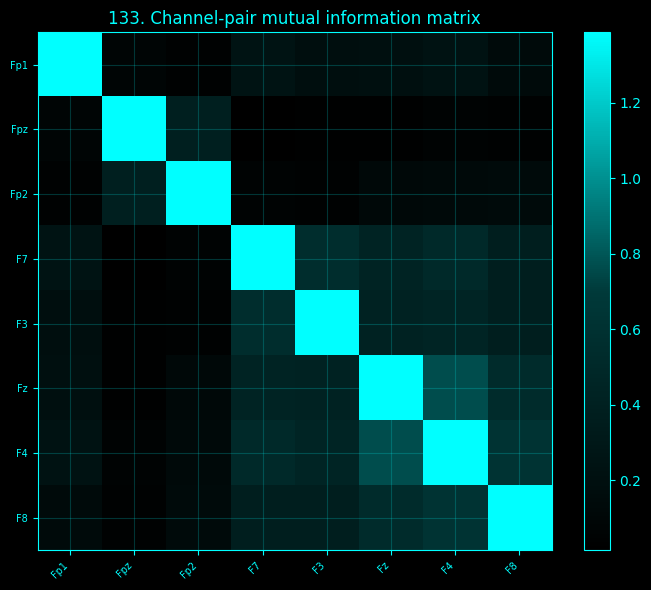

In [108]:
# =======================================================
# 133. Channel-pair mutual information matrix
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Pairwise mutual information is I(X;Y)=H(X)+H(Y)-H(X,Y), computed for every channel
# pair.
# =======================================================
def _entropy_method_133():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    n = len(S)
    M = np.zeros((n, n))
    for x in range(n):
        for y in range(n):
            if x == y:
                M[x, y] = _H(_p_from_labels(S[x]))
            else:
                mi = _MI(S[x], S[y])
                M[x, y] = mi
    _ent_display_result = pd.DataFrame(M, index=_ent_names[:n], columns=_ent_names[:n])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_133()
_ent_auto_plot(133, 'Channel-pair mutual information matrix', _ent_method_ns, ['S', 'n', 'M', 'x', '_ent_display_result', 'a', 'b', 'c', 'y', 'j', 'mi'])


### 134. Normalized mutual information matrix

Normalized mutual information uses I(X;Y)/sqrt(H(X)H(Y)), yielding a dimensionless symmetric dependence score.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,Fp1,Fpz,Fp2,F7,F3,Fz,F4,F8
Fp1,1.000000,0.061210,0.036768,0.176396,0.136873,0.148717,0.168802,0.097885
Fpz,0.061210,1.000000,0.280123,0.010657,0.022992,0.024834,0.045101,0.032382
Fp2,0.036768,0.280123,1.000000,0.039194,0.035806,0.081277,0.090895,0.104485
F7,0.176396,0.010657,0.039194,1.000000,0.403583,0.315882,0.362913,0.272073
F3,0.136873,0.022992,0.035806,0.403583,1.000000,0.307140,0.321286,0.272237
Fz,0.148717,0.024834,0.081277,0.315882,0.307140,1.000000,0.552650,0.383892
F4,0.168802,0.045101,0.090895,0.362913,0.321286,0.552650,1.000000,0.450863
F8,0.097885,0.032382,0.104485,0.272073,0.272237,0.383892,0.450863,1.000000


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


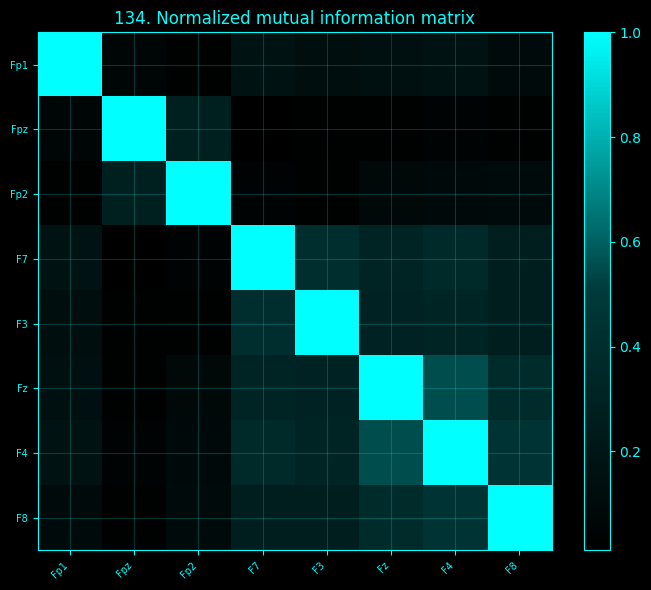

In [109]:
# =======================================================
# 134. Normalized mutual information matrix
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Normalized mutual information uses I(X;Y)/sqrt(H(X)H(Y)), yielding a dimensionless
# symmetric dependence score.
# =======================================================
def _entropy_method_134():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    n = len(S)
    M = np.zeros((n, n))
    for x in range(n):
        for y in range(n):
            if x == y:
                M[x, y] = 1
            else:
                mi = _MI(S[x], S[y])
                M[x, y] = mi / np.sqrt((_H(_p_from_labels(S[x])) + ENT_EPS) * (_H(_p_from_labels(S[y])) + ENT_EPS))
    _ent_display_result = pd.DataFrame(M, index=_ent_names[:n], columns=_ent_names[:n])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_134()
_ent_auto_plot(134, 'Normalized mutual information matrix', _ent_method_ns, ['S', 'n', 'M', 'x', '_ent_display_result', 'a', 'b', 'c', 'y', 'j', 'mi'])


### 135. Conditional mutual information

Conditional mutual information is I(X;Y|Z)=H(X,Z)+H(Y,Z)-H(Z)-H(X,Y,Z).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [110]:
# =======================================================
# 135. Conditional mutual information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Conditional mutual information is I(X;Y|Z)=H(X,Z)+H(Y,Z)-H(Z)-H(X,Y,Z).
# =======================================================
def _entropy_method_135():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    _ent_print_args = ['Conditional MI I(ch0;ch1|ch2)=', _CMI(a, b, c)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_135()
_ent_auto_plot(135, 'Conditional mutual information', _ent_method_ns, ['S', '_ent_print_args', 'a', 'b', 'c', 'j'])


Conditional MI I(ch0;ch1|ch2)= 0.15233842787225216


### 136. Time-delayed mutual information matrix

Time-delayed mutual information evaluates I(X_t;Y_t+tau) across channel pairs at a fixed positive lag.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


,Fp1,Fpz,Fp2,F7,F3,Fz,F4,F8
Fp1,0.000000,0.062408,0.035340,0.196876,0.143644,0.180716,0.204503,0.111546
Fpz,0.057470,0.000000,0.260075,0.009427,0.013220,0.015563,0.032506,0.021001
Fp2,0.029123,0.274318,0.000000,0.033393,0.023367,0.061046,0.069227,0.068215
F7,0.211212,0.014068,0.047936,0.000000,0.422528,0.415557,0.475845,0.351450
F3,0.161326,0.025821,0.048033,0.439303,0.000000,0.382702,0.422079,0.357291
Fz,0.168791,0.016505,0.062167,0.335377,0.278389,0.000000,0.527994,0.386825
F4,0.198479,0.036585,0.075259,0.384215,0.315829,0.555500,0.000000,0.427671
F8,0.109889,0.025819,0.077717,0.284148,0.260283,0.423371,0.444931,0.000000


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


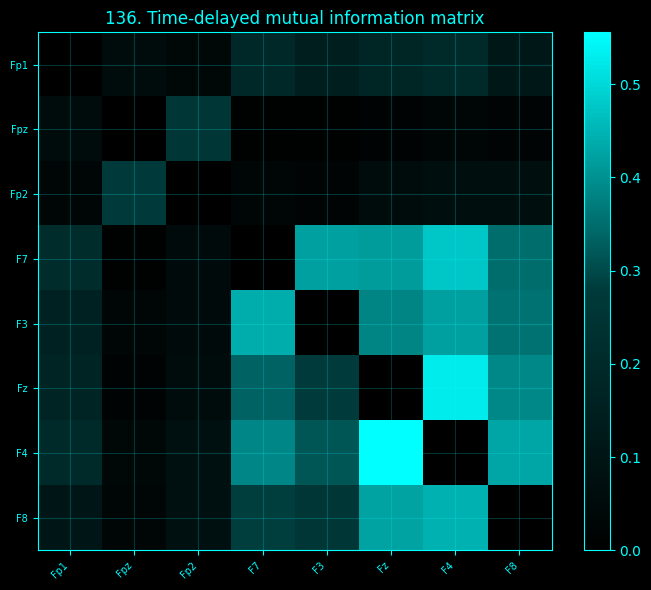

In [111]:
# =======================================================
# 136. Time-delayed mutual information matrix
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Time-delayed mutual information evaluates I(X_t;Y_t+tau) across channel pairs at a
# fixed positive lag.
# =======================================================
def _entropy_method_136():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    lag = max(1, int(0.02 * _ent_fs))
    n = len(S)
    M = np.zeros((n, n))
    for x in range(n):
        for y in range(n):
            if x != y:
                M[x, y] = _MI(S[x][:-lag], S[y][lag:])
    _ent_display_result = pd.DataFrame(M, index=_ent_names[:n], columns=_ent_names[:n])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_136()
_ent_auto_plot(136, 'Time-delayed mutual information matrix', _ent_method_ns, ['S', 'lag', 'n', 'M', 'x', '_ent_display_result', 'a', 'b', 'c', 'y', 'j'])


### 137. Lagged mutual information sweep

A lagged MI sweep evaluates I(X_t;Y_t+tau) across a range of lags to reveal delayed statistical dependence.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


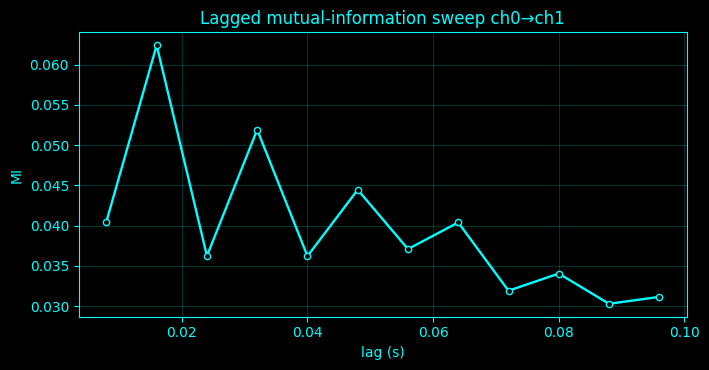

In [112]:
# =======================================================
# 137. Lagged mutual information sweep
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: A lagged MI sweep evaluates I(X_t;Y_t+tau) across a range of lags to reveal delayed
# statistical dependence.
# =======================================================
def _entropy_method_137():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    lags = np.arange(1, max(3, int(0.1 * _ent_fs)) + 1)
    v = [_MI(a[:-l], b[l:]) for l in lags]
    _line(lags / _ent_fs, v, 'Lagged mutual-information sweep ch0→ch1', 'lag (s)', 'MI')
    return locals()
_ent_method_ns = _entropy_method_137()


### 138. Partial mutual information

Partial mutual information is implemented as conditional mutual information I(X;Y|Z), removing dependence statistically explained by the conditioning variable.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [113]:
# =======================================================
# 138. Partial mutual information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Partial mutual information is implemented as conditional mutual information I(X;Y|Z),
# removing dependence statistically explained by the conditioning variable.
# =======================================================
def _entropy_method_138():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    _ent_print_args = ['Partial mutual information I(ch0;ch1|ch2)=', _CMI(a, b, c)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_138()
_ent_auto_plot(138, 'Partial mutual information', _ent_method_ns, ['S', '_ent_print_args', 'a', 'b', 'c', 'j'])


Partial mutual information I(ch0;ch1|ch2)= 0.15233842787225216


### 139. Interaction information

Interaction information for three variables is I(X;Y;Z)=I(X;Y)-I(X;Y|Z); its sign depends on the redundancy/synergy convention.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [114]:
# =======================================================
# 139. Interaction information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Interaction information for three variables is I(X;Y;Z)=I(X;Y)-I(X;Y|Z); its sign
# depends on the redundancy/synergy convention.
# =======================================================
def _entropy_method_139():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    _ent_print_args = ['Interaction information I(ch0;ch1;ch2)=', _MI(a, b) - _CMI(a, b, c)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_139()
_ent_auto_plot(139, 'Interaction information', _ent_method_ns, ['S', '_ent_print_args', 'a', 'b', 'c', 'j'])


Interaction information I(ch0;ch1;ch2)= -0.06748382768708039


### 140. Total correlation

Total correlation is TC=sum_i H(X_i)-H(X_1,...,X_n), a multivariate generalization of mutual information.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [115]:
# =======================================================
# 140. Total correlation
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Total correlation is TC=sum_i H(X_i)-H(X_1,...,X_n), a multivariate generalization of
# mutual information.
# =======================================================
def _entropy_method_140():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    _ent_print_args = ['Total correlation=', _TC(cols)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_140()
_ent_auto_plot(140, 'Total correlation', _ent_method_ns, ['S', 'cols', '_ent_print_args', 'a', 'b', 'c', 'j'])


Total correlation= 1.0350478939159782


### 141. Dual total correlation

Dual total correlation is DTC=sum_i H(X_-i)-(n-1)H(X_1,...,X_n), also called binding information.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [116]:
# =======================================================
# 141. Dual total correlation
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Dual total correlation is DTC=sum_i H(X_-i)-(n-1)H(X_1,...,X_n), also called binding
# information.
# =======================================================
def _entropy_method_141():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    _ent_print_args = ['Dual total correlation=', _DTC(cols)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_141()
_ent_auto_plot(141, 'Dual total correlation', _ent_method_ns, ['S', 'cols', '_ent_print_args', 'a', 'b', 'c', 'j'])


Dual total correlation= 1.1660714136157448


### 142. O-information

O-information is Omega=TC-DTC: positive values indicate redundancy-dominated dependence and negative values synergy-dominated dependence.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [117]:
# =======================================================
# 142. O-information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: O-information is Omega=TC-DTC: positive values indicate redundancy-dominated dependence
# and negative values synergy-dominated dependence.
# =======================================================
def _entropy_method_142():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    _ent_print_args = ['O-information Ω=TC-DTC=', _TC(cols) - _DTC(cols)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_142()
_ent_auto_plot(142, 'O-information', _ent_method_ns, ['S', 'cols', '_ent_print_args', 'a', 'b', 'c', 'j'])


O-information Ω=TC-DTC= -0.13102351969976667


### 143. S-information

S-information is TC+DTC, a symmetric measure of total interdependence complementary to O-information.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [118]:
# =======================================================
# 143. S-information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: S-information is TC+DTC, a symmetric measure of total interdependence complementary to
# O-information.
# =======================================================
def _entropy_method_143():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    _ent_print_args = ['S-information=TC+DTC=', _TC(cols) + _DTC(cols)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_143()
_ent_auto_plot(143, 'S-information', _ent_method_ns, ['S', 'cols', '_ent_print_args', 'a', 'b', 'c', 'j'])


S-information=TC+DTC= 2.201119307531723


### 144. Multi-information

Multi-information is another name for total correlation, sum marginal entropies minus joint entropy.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [119]:
# =======================================================
# 144. Multi-information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Multi-information is another name for total correlation, sum marginal entropies minus
# joint entropy.
# =======================================================
def _entropy_method_144():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    _ent_print_args = ['Multi-information=', _TC(cols)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_144()
_ent_auto_plot(144, 'Multi-information', _ent_method_ns, ['S', 'cols', '_ent_print_args', 'a', 'b', 'c', 'j'])


Multi-information= 1.0350478939159782


### 145. Redundancy-synergy entropy decomposition

The redundancy-synergy dominance summary uses O-information: positive Omega is reported as redundancy dominance and negative Omega as synergy dominance; it is not a full PID.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


{'TC': 1.0350478939159782, 'DTC': 1.1660714136157448, 'O_information': -0.13102351969976667, 'redundancy_dominance': 0, 'synergy_dominance': 0.13102351969976667}


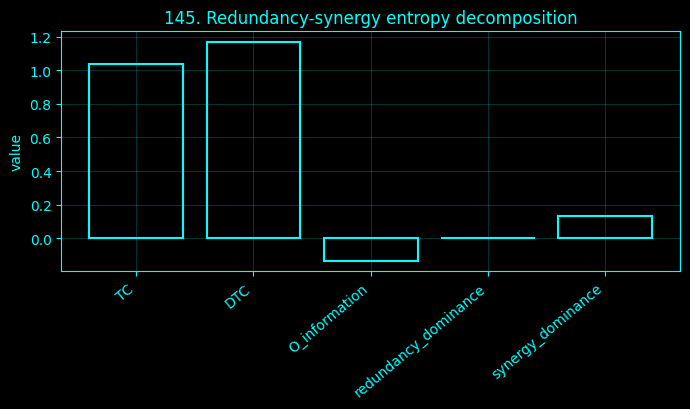

In [120]:
# =======================================================
# 145. Redundancy-synergy entropy decomposition
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: The redundancy-synergy dominance summary uses O-information: positive Omega is reported
# as redundancy dominance and negative Omega as synergy dominance; it is not a full PID.
# =======================================================
def _entropy_method_145():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    tc, dt = (_TC(cols), _DTC(cols))
    om = tc - dt
    _ent_print_args = [{'TC': tc, 'DTC': dt, 'O_information': om, 'redundancy_dominance': max(om, 0), 'synergy_dominance': max(-om, 0)}]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_145()
_ent_auto_plot(145, 'Redundancy-synergy entropy decomposition', _ent_method_ns, ['S', 'cols', 'om', '_ent_print_args', 'a', 'b', 'c', 'tc', 'dt', 'j'])


### 146. Partial Information Decomposition

This notebook uses the bivariate minimum-mutual-information PID: R=min[I(S1;T),I(S2;T)], U1=I(S1;T)-R, U2=I(S2;T)-R, and synergy=I(S1,S2;T)-R-U1-U2.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


MMI PID {'redundancy': 0.05097126070377245, 'unique_1': 0.0, 'unique_2': 0.3373613548695533, 'synergy': 0.11845508839085239, 'joint_MI': 0.5067877039641782}


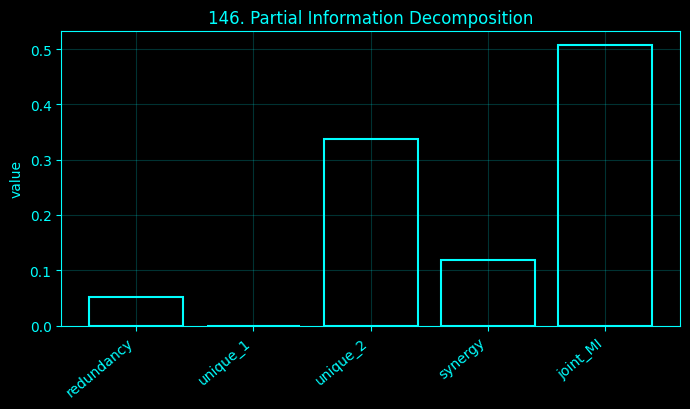

In [121]:
# =======================================================
# 146. Partial Information Decomposition
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: This notebook uses the bivariate minimum-mutual-information PID:
# R=min[I(S1;T),I(S2;T)], U1=I(S1;T)-R, U2=I(S2;T)-R, and synergy=I(S1,S2;T)-R-U1-U2.
# =======================================================
def _entropy_method_146():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    d = _pid_mmi(a, b, c)
    _ent_print_args = ['MMI PID', d]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_146()
_ent_auto_plot(146, 'Partial Information Decomposition', _ent_method_ns, ['S', 'cols', 'd', '_ent_print_args', 'a', 'b', 'c', 'j'])


### 147. Redundant information

Redundant information is the MMI PID atom R=min[I(S1;T),I(S2;T)].

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [122]:
# =======================================================
# 147. Redundant information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Redundant information is the MMI PID atom R=min[I(S1;T),I(S2;T)].
# =======================================================
def _entropy_method_147():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    d = _pid_mmi(a, b, c)
    _ent_print_args = ['redundant information=', d['redundancy']]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_147()
_ent_auto_plot(147, 'Redundant information', _ent_method_ns, ['S', 'cols', 'd', '_ent_print_args', 'a', 'b', 'c', 'j'])


redundant information= 0.05097126070377245


### 148. Unique information

Unique information atoms are U1=I(S1;T)-R and U2=I(S2;T)-R under the stated MMI PID convention.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


unique information source1/source2= 0.0 0.3373613548695533


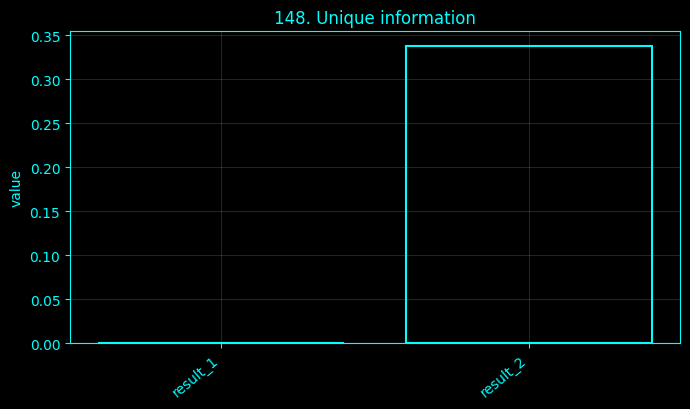

In [123]:
# =======================================================
# 148. Unique information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Unique information atoms are U1=I(S1;T)-R and U2=I(S2;T)-R under the stated MMI PID
# convention.
# =======================================================
def _entropy_method_148():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    d = _pid_mmi(a, b, c)
    _ent_print_args = ['unique information source1/source2=', d['unique_1'], d['unique_2']]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_148()
_ent_auto_plot(148, 'Unique information', _ent_method_ns, ['S', 'cols', 'd', '_ent_print_args', 'a', 'b', 'c', 'j'])


### 149. Synergistic information

Synergistic information is the residual joint source information not assigned to redundancy or unique atoms under MMI PID.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [124]:
# =======================================================
# 149. Synergistic information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Synergistic information is the residual joint source information not assigned to
# redundancy or unique atoms under MMI PID.
# =======================================================
def _entropy_method_149():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    d = _pid_mmi(a, b, c)
    _ent_print_args = ['synergistic information=', d['synergy']]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_149()
_ent_auto_plot(149, 'Synergistic information', _ent_method_ns, ['S', 'cols', 'd', '_ent_print_args', 'a', 'b', 'c', 'j'])


synergistic information= 0.11845508839085239


### 150. PID-based channel triplet analysis

PID-based triplet analysis evaluates the stated MMI PID for channel-source pairs and a distinct target.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


,source1,source2,target,redundancy,unique1,unique2,synergy
0,Fp1,Fpz,Fp2,0.050971,0.000000,0.337361,0.118455
1,Fp1,Fpz,F7,0.014774,0.229763,0.000000,0.090811
2,Fp1,Fpz,F3,0.031873,0.157873,0.000000,0.065706
3,Fp1,Fpz,Fz,0.034427,0.171739,0.000000,0.131165
4,Fp1,Fp2,Fpz,0.084855,0.000000,0.303478,0.152338
5,Fp1,Fp2,F7,0.054334,0.190203,0.000000,0.142548
6,Fp1,Fp2,F3,0.049637,0.140109,0.000000,0.087049
7,Fp1,Fp2,Fz,0.112674,0.093492,0.000000,0.168703
8,Fp1,F7,Fpz,0.014774,0.070081,0.000000,0.090811
9,Fp1,F7,Fp2,0.050971,0.000000,0.003363,0.139186


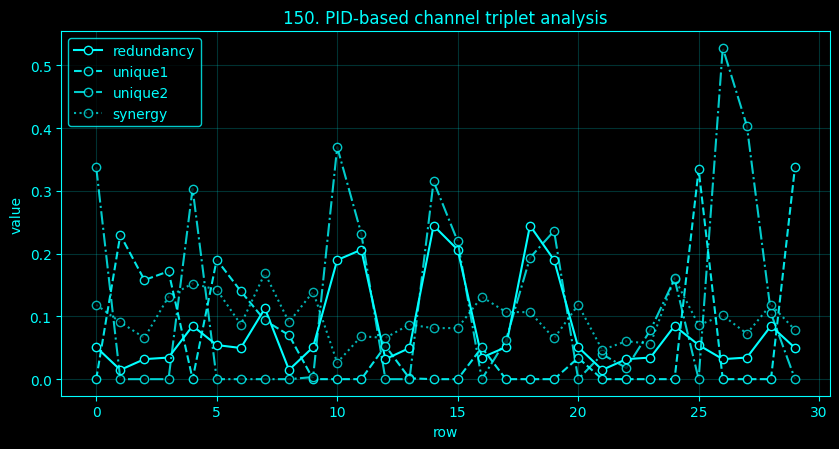

In [125]:
# =======================================================
# 150. PID-based channel triplet analysis
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: PID-based triplet analysis evaluates the stated MMI PID for channel-source pairs and a
# distinct target.
# =======================================================
def _entropy_method_150():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    rows = []
    n = min(6, len(S))
    for s1 in range(n):
        for s2 in range(s1 + 1, n):
            for t in range(n):
                if t not in (s1, s2):
                    d = _pid_mmi(S[s1], S[s2], S[t])
                    rows.append([_ent_names[s1], _ent_names[s2], _ent_names[t], d['redundancy'], d['unique_1'], d['unique_2'], d['synergy']])
    df = pd.DataFrame(rows, columns=['source1', 'source2', 'target', 'redundancy', 'unique1', 'unique2', 'synergy'])
    _ent_display_result = df.head(30)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_150()
_ent_auto_plot(150, 'PID-based channel triplet analysis', _ent_method_ns, ['S', 'cols', 'rows', 'n', 's1', 'df', '_ent_display_result', 'a', 'b', 'c', 's2', 'j', 't', 'd'])


### 151. PID source-target decomposition

PID source-target decomposition ranks source-pair/target triplets by their redundancy, unique and synergy atoms.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


,source1,source2,target,redundancy,unique1,unique2,synergy
32,Fpz,Fz,Fp1,0.084855,0.000000,0.121311,0.181593
7,Fp1,Fp2,Fz,0.112674,0.093492,0.000000,0.168703
24,Fpz,F7,Fp1,0.084855,0.000000,0.159682,0.160892
4,Fp1,Fp2,Fpz,0.084855,0.000000,0.303478,0.152338
5,Fp1,Fp2,F7,0.054334,0.190203,0.000000,0.142548
9,Fp1,F7,Fp2,0.050971,0.000000,0.003363,0.139186
36,Fp2,F7,Fp1,0.050971,0.000000,0.193566,0.139186
39,Fp2,F7,Fz,0.112674,0.000000,0.325231,0.135203
33,Fpz,Fz,Fp2,0.112674,0.275658,0.000000,0.134462
3,Fp1,Fpz,Fz,0.034427,0.171739,0.000000,0.131165


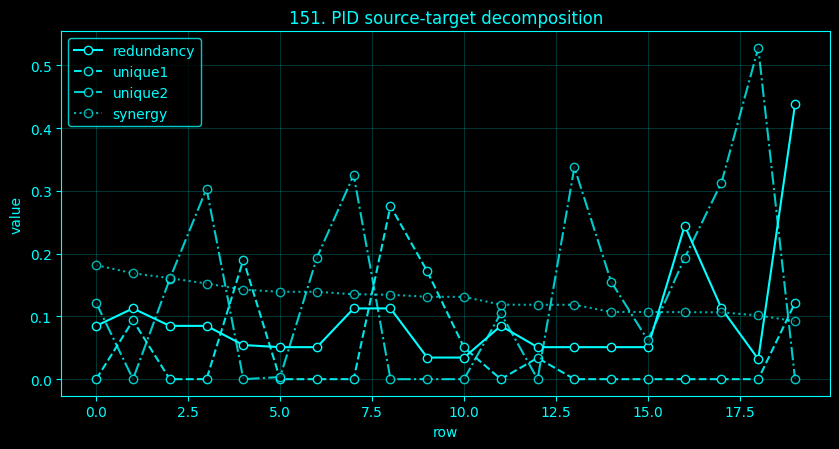

In [126]:
# =======================================================
# 151. PID source-target decomposition
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: PID source-target decomposition ranks source-pair/target triplets by their redundancy,
# unique and synergy atoms.
# =======================================================
def _entropy_method_151():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    rows = []
    n = min(6, len(S))
    for s1 in range(n):
        for s2 in range(s1 + 1, n):
            for t in range(n):
                if t not in (s1, s2):
                    d = _pid_mmi(S[s1], S[s2], S[t])
                    rows.append([_ent_names[s1], _ent_names[s2], _ent_names[t], d['redundancy'], d['unique_1'], d['unique_2'], d['synergy']])
    df = pd.DataFrame(rows, columns=['source1', 'source2', 'target', 'redundancy', 'unique1', 'unique2', 'synergy'])
    _ent_display_result = df.sort_values('synergy', ascending=False).head(20)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_151()
_ent_auto_plot(151, 'PID source-target decomposition', _ent_method_ns, ['S', 'cols', 'rows', 'n', 's1', 'df', '_ent_display_result', 'a', 'b', 'c', 's2', 'j', 't', 'd'])


### 152. Synergy-dominant EEG channel motifs

Synergy-dominant motifs are triplets whose MMI synergy exceeds their redundancy.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


,source1,source2,target,redundancy,unique1,unique2,synergy,score
3,Fp1,Fpz,Fz,0.034427,0.171739,0.000000,0.131165,0.096738
16,Fp1,Fz,Fpz,0.034427,0.050428,0.000000,0.131165,0.096738
32,Fpz,Fz,Fp1,0.084855,0.000000,0.121311,0.181593,0.096738
5,Fp1,Fp2,F7,0.054334,0.190203,0.000000,0.142548,0.088214
36,Fp2,F7,Fp1,0.050971,0.000000,0.193566,0.139186,0.088214
9,Fp1,F7,Fp2,0.050971,0.000000,0.003363,0.139186,0.088214
8,Fp1,F7,Fpz,0.014774,0.070081,0.000000,0.090811,0.076037
1,Fp1,Fpz,F7,0.014774,0.229763,0.000000,0.090811,0.076037
24,Fpz,F7,Fp1,0.084855,0.000000,0.159682,0.160892,0.076037
49,F7,F3,Fpz,0.014774,0.000000,0.017100,0.084338,0.069564


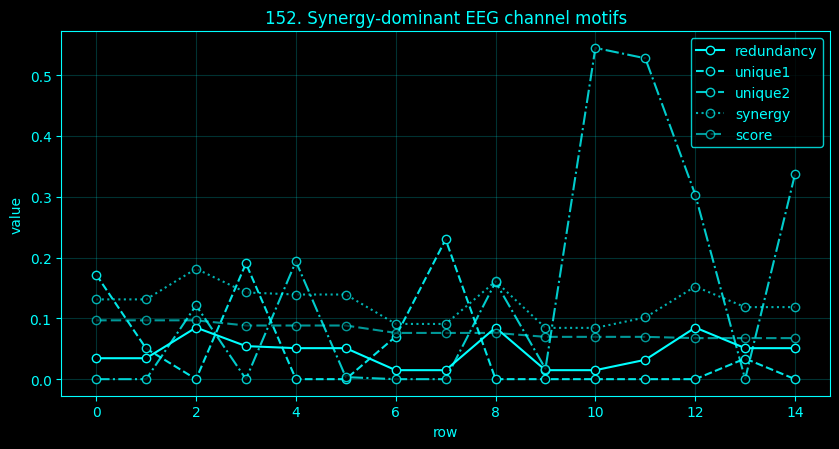

In [127]:
# =======================================================
# 152. Synergy-dominant EEG channel motifs
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Synergy-dominant motifs are triplets whose MMI synergy exceeds their redundancy.
# =======================================================
def _entropy_method_152():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    rows = []
    n = min(6, len(S))
    for s1 in range(n):
        for s2 in range(s1 + 1, n):
            for t in range(n):
                if t not in (s1, s2):
                    d = _pid_mmi(S[s1], S[s2], S[t])
                    rows.append([_ent_names[s1], _ent_names[s2], _ent_names[t], d['redundancy'], d['unique_1'], d['unique_2'], d['synergy']])
    df = pd.DataFrame(rows, columns=['source1', 'source2', 'target', 'redundancy', 'unique1', 'unique2', 'synergy'])
    _ent_display_result = df.assign(score=df.synergy - df.redundancy).sort_values('score', ascending=False).head(15)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_152()
_ent_auto_plot(152, 'Synergy-dominant EEG channel motifs', _ent_method_ns, ['S', 'cols', 'rows', 'n', 's1', 'df', '_ent_display_result', 'a', 'b', 'c', 's2', 'j', 't', 'd'])


### 153. Redundancy-dominant EEG channel motifs

Redundancy-dominant motifs are triplets whose MMI redundancy exceeds their synergy.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


,source1,source2,target,redundancy,unique1,unique2,synergy,score
59,F3,Fz,F7,0.437906,0.121579,0.000000,0.092472,0.345433
51,F7,F3,Fz,0.425787,0.012119,0.000000,0.080354,0.345433
55,F7,Fz,F3,0.425787,0.133698,0.000000,0.080354,0.345433
10,Fp1,F7,F3,0.189746,0.000000,0.369738,0.026333,0.163413
48,F7,F3,Fp1,0.189746,0.054791,0.000000,0.026333,0.163413
14,Fp1,F3,F7,0.244537,0.000000,0.314948,0.081124,0.163413
18,Fp1,Fz,F7,0.244537,0.000000,0.193369,0.106674,0.137863
52,F7,Fz,Fp1,0.206166,0.038371,0.000000,0.068303,0.137863
11,Fp1,F7,Fz,0.206166,0.000000,0.231740,0.068303,0.137863
15,Fp1,F3,Fz,0.206166,0.000000,0.219621,0.081444,0.124722


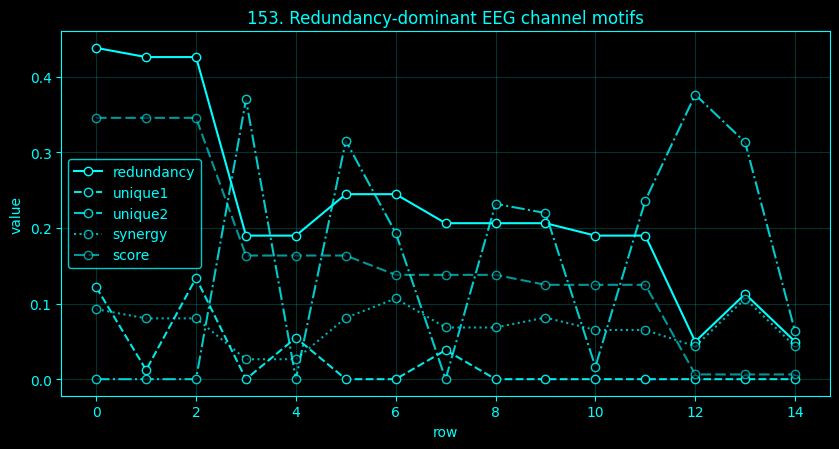

In [128]:
# =======================================================
# 153. Redundancy-dominant EEG channel motifs
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Redundancy-dominant motifs are triplets whose MMI redundancy exceeds their synergy.
# =======================================================
def _entropy_method_153():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    rows = []
    n = min(6, len(S))
    for s1 in range(n):
        for s2 in range(s1 + 1, n):
            for t in range(n):
                if t not in (s1, s2):
                    d = _pid_mmi(S[s1], S[s2], S[t])
                    rows.append([_ent_names[s1], _ent_names[s2], _ent_names[t], d['redundancy'], d['unique_1'], d['unique_2'], d['synergy']])
    df = pd.DataFrame(rows, columns=['source1', 'source2', 'target', 'redundancy', 'unique1', 'unique2', 'synergy'])
    _ent_display_result = df.assign(score=df.redundancy - df.synergy).sort_values('score', ascending=False).head(15)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_153()
_ent_auto_plot(153, 'Redundancy-dominant EEG channel motifs', _ent_method_ns, ['S', 'cols', 'rows', 'n', 's1', 'df', '_ent_display_result', 'a', 'b', 'c', 's2', 'j', 't', 'd'])


### 154. Conditional Transfer Entropy

Conditional Transfer Entropy is T_X→Y|Z=I(X_t-past;Y_t|Y_past,Z_past).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [129]:
# =======================================================
# 154. Conditional Transfer Entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Conditional Transfer Entropy is T_X→Y|Z=I(X_t-past;Y_t|Y_past,Z_past).
# =======================================================
def _entropy_method_154():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    _ent_print_args = ['Conditional TE ch0→ch1 | ch2=', _te_discrete(a, b, 1, c)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_154()
_ent_auto_plot(154, 'Conditional Transfer Entropy', _ent_method_ns, ['S', 'cols', '_ent_print_args', 'a', 'b', 'c', 'j'])


Conditional TE ch0→ch1 | ch2= 0.08575588248768895


### 155. Partial Transfer Entropy

Partial Transfer Entropy conditions source-to-target information transfer on additional observed processes to remove shared predictive drivers.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [130]:
# =======================================================
# 155. Partial Transfer Entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Partial Transfer Entropy conditions source-to-target information transfer on additional
# observed processes to remove shared predictive drivers.
# =======================================================
def _entropy_method_155():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    cond = np.array([u * 4 + v for u, v in zip(c, S[3])])
    _ent_print_args = ['Partial TE ch0→ch1 conditioned on ch2,ch3=', _te_discrete(a, b, 1, cond)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_155()
_ent_auto_plot(155, 'Partial Transfer Entropy', _ent_method_ns, ['S', 'cols', 'cond', '_ent_print_args', 'a', 'b', 'c', 'j', 'u', 'v'])


Partial TE ch0→ch1 conditioned on ch2,ch3= 0.10389582414858278


### 156. Multivariate Transfer Entropy

Multivariate Transfer Entropy uses a vector of source histories: I(X1_past,...,Xk_past;Y_t|Y_past).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [131]:
# =======================================================
# 156. Multivariate Transfer Entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Multivariate Transfer Entropy uses a vector of source histories:
# I(X1_past,...,Xk_past;Y_t|Y_past).
# =======================================================
def _entropy_method_156():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    _ent_print_args = ['Multivariate TE {ch0,ch2,ch3}→ch1=', _te_multi([a, c, S[3]], b, 1)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_156()
_ent_auto_plot(156, 'Multivariate Transfer Entropy', _ent_method_ns, ['S', 'cols', '_ent_print_args', 'a', 'b', 'c', 'j'])


Multivariate TE {ch0,ch2,ch3}→ch1= 0.24317133637272814


### 157. Local Transfer Entropy

Local Transfer Entropy is the pointwise log ratio log[p(y_t|y_past,x_past)/p(y_t|y_past)]; its expectation is TE.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


Local TE mean= 0.06262490878530887 median= 0.06191161705414633 negative fraction= 0.4130724766562917


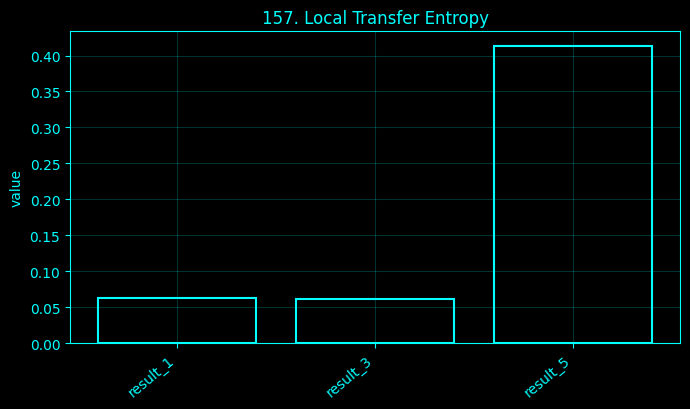

In [132]:
# =======================================================
# 157. Local Transfer Entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Local Transfer Entropy is the pointwise log ratio
# log[p(y_t|y_past,x_past)/p(y_t|y_past)]; its expectation is TE.
# =======================================================
def _entropy_method_157():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    lt = _local_te(a, b, 1)
    _ent_print_args = ['Local TE mean=', float(np.mean(lt)), 'median=', float(np.median(lt)), 'negative fraction=', float(np.mean(lt < 0))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_157()
_ent_auto_plot(157, 'Local Transfer Entropy', _ent_method_ns, ['S', 'cols', 'lt', '_ent_print_args', 'a', 'b', 'c', 'j'])


### 158. Symbolic Transfer Entropy

Symbolic Transfer Entropy estimates TE after quantizing amplitudes into discrete symbols.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [133]:
# =======================================================
# 158. Symbolic Transfer Entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Symbolic Transfer Entropy estimates TE after quantizing amplitudes into discrete
# symbols.
# =======================================================
def _entropy_method_158():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    _ent_print_args = ['Symbolic Transfer Entropy ch0→ch1=', _te_discrete(a, b)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_158()
_ent_auto_plot(158, 'Symbolic Transfer Entropy', _ent_method_ns, ['S', 'cols', '_ent_print_args', 'a', 'b', 'c', 'j'])


Symbolic Transfer Entropy ch0→ch1= 0.06262490878530835


### 159. Permutation Transfer Entropy

Permutation Transfer Entropy estimates directed predictive information using ordinal-pattern symbols instead of amplitude bins.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


Permutation Transfer Entropy= 0.1013045850597818


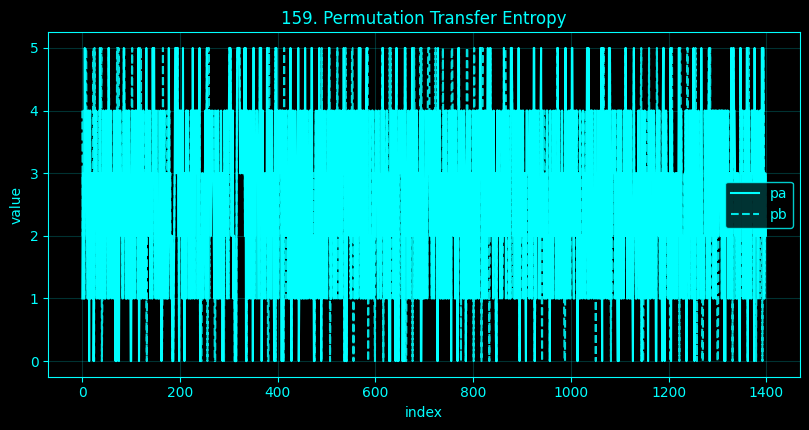

In [134]:
# =======================================================
# 159. Permutation Transfer Entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Permutation Transfer Entropy estimates directed predictive information using ordinal-
# pattern symbols instead of amplitude bins.
# =======================================================
def _entropy_method_159():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    pa = _ordinal_seq(_ent_x[:, 0], 3)
    pb = _ordinal_seq(_ent_x[:, 1], 3)
    _ent_print_args = ['Permutation Transfer Entropy=', _te_discrete(pa, pb)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_159()
_ent_auto_plot(159, 'Permutation Transfer Entropy', _ent_method_ns, ['S', 'cols', 'pa', 'pb', '_ent_print_args', 'a', 'b', 'c', 'j'])


### 160. Effective Transfer Entropy

Effective Transfer Entropy subtracts the mean TE from shuffled-source surrogates to reduce finite-sample bias.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


Effective TE = observed - shuffle mean = 0.05575010435768331 observed= 0.06262490878530835 null= 0.006874804427625047


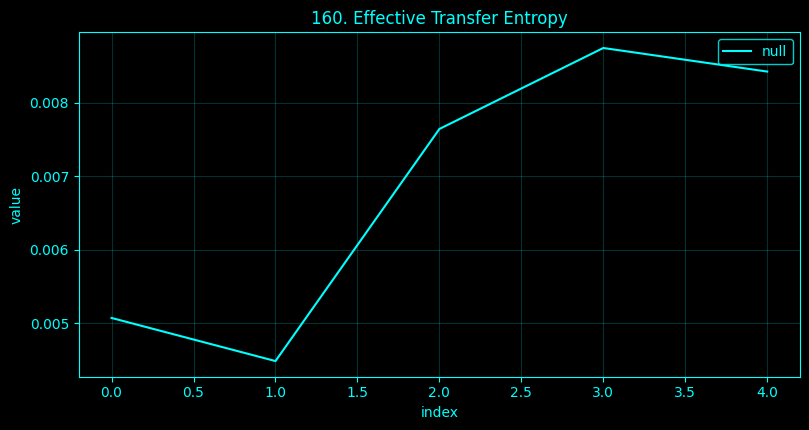

In [135]:
# =======================================================
# 160. Effective Transfer Entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Effective Transfer Entropy subtracts the mean TE from shuffled-source surrogates to
# reduce finite-sample bias.
# =======================================================
def _entropy_method_160():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    obs = _te_discrete(a, b)
    rng = np.random.default_rng(160)
    null = []
    for _ in range(_ENT_SPEED['sur']):
        null.append(_te_discrete(rng.permutation(a), b))
    _ent_print_args = ['Effective TE = observed - shuffle mean =', obs - np.mean(null), 'observed=', obs, 'null=', np.mean(null)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_160()
_ent_auto_plot(160, 'Effective Transfer Entropy', _ent_method_ns, ['S', 'cols', 'obs', 'rng', 'null', '_', '_ent_print_args', 'a', 'b', 'c', 'j'])


### 161. Normalized Transfer Entropy

Normalized Transfer Entropy divides TE by target innovation entropy H(Y_t|Y_past), expressing transferred information as a fraction of unpredictable target entropy.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


Normalized TE= 0.0542644843508387 TE= 0.06262490878530835 target innovation entropy= 1.154068071122953


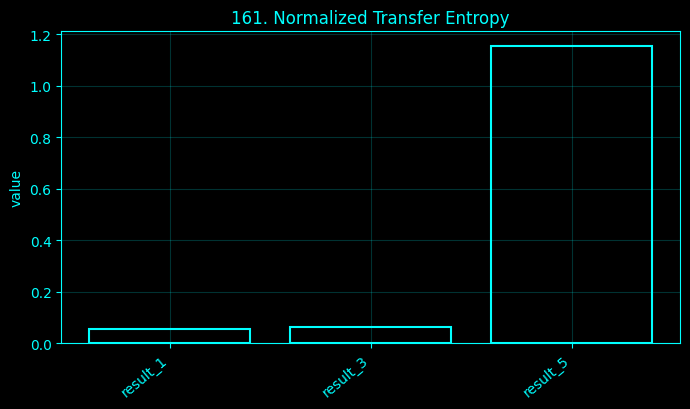

In [136]:
# =======================================================
# 161. Normalized Transfer Entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Normalized Transfer Entropy divides TE by target innovation entropy H(Y_t|Y_past),
# expressing transferred information as a fraction of unpredictable target entropy.
# =======================================================
def _entropy_method_161():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    te = _te_discrete(a, b)
    hcond = _Hcols(b[1:], b[:-1]) - _H(_p_from_labels(b[:-1]))
    _ent_print_args = ['Normalized TE=', te / (hcond + ENT_EPS), 'TE=', te, 'target innovation entropy=', hcond]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_161()
_ent_auto_plot(161, 'Normalized Transfer Entropy', _ent_method_ns, ['S', 'cols', 'te', 'hcond', '_ent_print_args', 'a', 'b', 'c', 'j'])


### 162. Delayed Transfer Entropy sweep

Delayed Transfer Entropy sweeps source-target lag in T_X→Y(tau).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


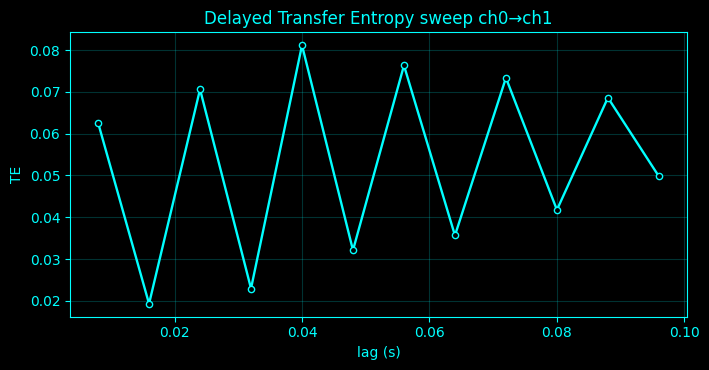

In [137]:
# =======================================================
# 162. Delayed Transfer Entropy sweep
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Delayed Transfer Entropy sweeps source-target lag in T_X→Y(tau).
# =======================================================
def _entropy_method_162():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    lags = np.arange(1, max(3, int(0.1 * _ent_fs)) + 1)
    _line(lags / _ent_fs, [_te_discrete(a, b, int(l)) for l in lags], 'Delayed Transfer Entropy sweep ch0→ch1', 'lag (s)', 'TE')
    return locals()
_ent_method_ns = _entropy_method_162()


### 163. Frequency-band Transfer Entropy

Frequency-band Transfer Entropy applies the TE estimator after band-pass filtering and symbolization.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,band,TE_ch0_to_ch1
0,delta,0.010599
1,theta,0.021489
2,alpha,0.016668
3,beta,0.008506
4,gamma,0.008077


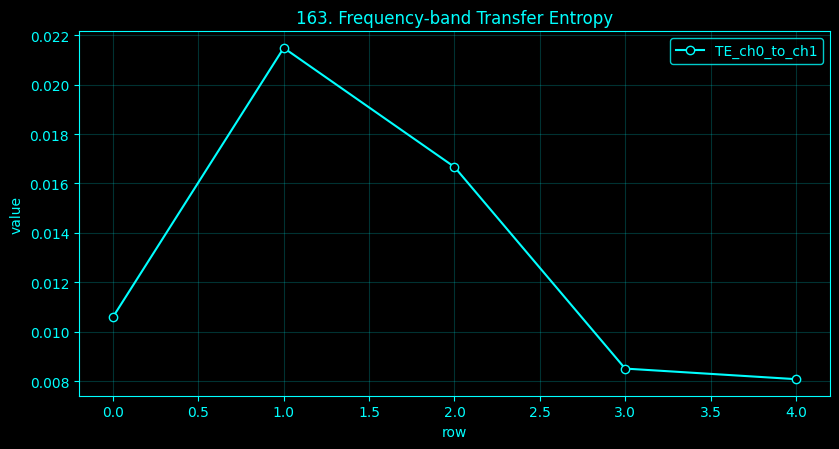

In [138]:
# =======================================================
# 163. Frequency-band Transfer Entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Frequency-band Transfer Entropy applies the TE estimator after band-pass filtering and
# symbolization.
# =======================================================
def _entropy_method_163():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    rows = []
    for name, (lo, hi) in _ENT_BANDS.items():
        if lo < _ent_fs / 2 - 0.5:
            x = _symbolize(_band(_ent_x[:, 0], lo, hi), 4)
            y = _symbolize(_band(_ent_x[:, 1], lo, hi), 4)
            rows.append([name, _te_discrete(x, y)])
    _ent_display_result = pd.DataFrame(rows, columns=['band', 'TE_ch0_to_ch1'])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_163()
_ent_auto_plot(163, 'Frequency-band Transfer Entropy', _ent_method_ns, ['S', 'cols', 'rows', '_ent_display_result', 'a', 'b', 'c', 'name', 'j', 'lo', 'hi', 'x', 'y'])


### 164. Time-frequency Transfer Entropy

Time-frequency Transfer Entropy estimates TE from band-envelope states inside local time windows, producing a band-by-time directed-information table.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,band,time_s,TE
0,delta,0.000,0.028414
1,delta,2.136,0.066571
2,delta,4.280,0.042559
3,delta,6.424,0.051337
4,delta,8.568,0.022070
5,delta,10.712,0.054862
6,delta,12.856,0.051501
7,delta,15.000,0.020099
8,theta,0.000,0.034252
9,theta,2.136,0.077784


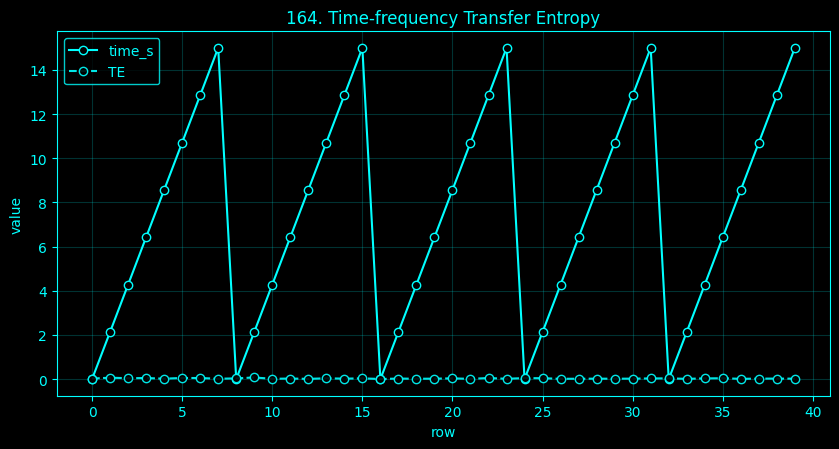

In [139]:
# =======================================================
# 164. Time-frequency Transfer Entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Time-frequency Transfer Entropy estimates TE from band-envelope states inside local
# time windows, producing a band-by-time directed-information table.
# =======================================================
def _entropy_method_164():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    rows = []
    W = max(200, int(3 * _ent_fs))
    starts = np.linspace(0, max(0, len(_ent_x) - W), min(8, _ENT_SPEED['windows'])).astype(int)
    for name, (lo, hi) in _ENT_BANDS.items():
        if lo >= _ent_fs / 2 - 0.5:
            continue
        ex = np.abs(signal.hilbert(_band(_ent_x[:, 0], lo, hi)))
        ey = np.abs(signal.hilbert(_band(_ent_x[:, 1], lo, hi)))
        for st in starts:
            rows.append([name, st / _ent_fs, _te_discrete(_symbolize(ex[st:st + W], 4), _symbolize(ey[st:st + W], 4))])
    _ent_display_result = pd.DataFrame(rows, columns=['band', 'time_s', 'TE'])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_164()
_ent_auto_plot(164, 'Time-frequency Transfer Entropy', _ent_method_ns, ['S', 'cols', 'rows', 'W', 'starts', '_ent_display_result', 'a', 'b', 'c', 'name', 'ex', 'ey', 'st', 'j', 'lo', 'hi'])


### 165. Conditional TE network analysis

Conditional TE network analysis computes pairwise TE while conditioning on a global multichannel state symbol.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


,Fp1,Fpz,Fp2,F7,F3,Fz,F4,F8
Fp1,0.000000,0.069090,0.073033,0.091962,0.070780,0.068669,0.074371,0.066275
Fpz,0.093844,0.000000,0.058471,0.088456,0.129434,0.106356,0.090587,0.115594
Fp2,0.080279,0.050394,0.000000,0.097096,0.154869,0.090931,0.089186,0.110005
F7,0.050786,0.026117,0.051382,0.000000,0.096688,0.078854,0.069974,0.088435
F3,0.030585,0.035432,0.059906,0.055048,0.000000,0.027330,0.034345,0.031990
Fz,0.030001,0.045363,0.034862,0.061367,0.077767,0.000000,0.028391,0.062671
F4,0.047338,0.039082,0.044983,0.064716,0.081776,0.046754,0.000000,0.083373
F8,0.020071,0.051668,0.056004,0.039953,0.038318,0.037001,0.036297,0.000000


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


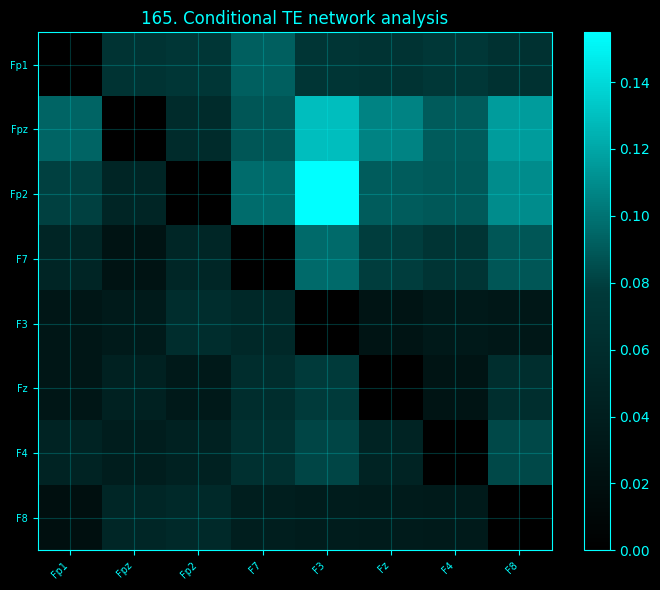

In [140]:
# =======================================================
# 165. Conditional TE network analysis
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Conditional TE network analysis computes pairwise TE while conditioning on a global
# multichannel state symbol.
# =======================================================
def _entropy_method_165():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    M = _te_matrix(cond_global=True)
    _ent_display_result = pd.DataFrame(M, index=_ent_names[:len(M)], columns=_ent_names[:len(M)])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_165()
_ent_auto_plot(165, 'Conditional TE network analysis', _ent_method_ns, ['S', 'cols', 'M', '_ent_display_result', 'a', 'b', 'c', 'j'])


### 166. TE source-sink entropy

TE source-sink entropy normalizes outgoing and incoming TE weights per node and computes Shannon entropy of each directional weight distribution.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,node,source_entropy,sink_entropy,net_TE
0,Fp1,1.940453,1.936739,-0.108368
1,Fpz,1.883297,1.902944,-0.086216
2,Fp2,1.913096,1.867641,0.006132
3,F7,1.922808,1.867481,0.137748
4,F3,1.751377,1.854809,-0.131749
5,Fz,1.822278,1.849097,0.035857
6,F4,1.884754,1.797014,0.188767
7,F8,1.761122,1.883825,-0.042171


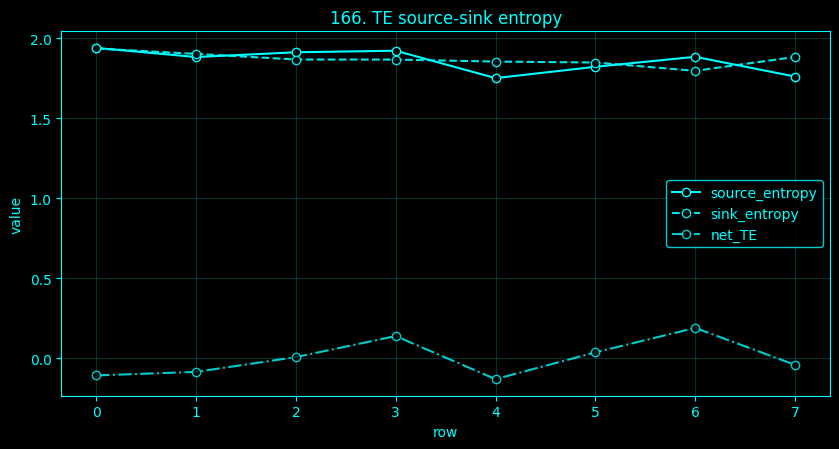

In [141]:
# =======================================================
# 166. TE source-sink entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: TE source-sink entropy normalizes outgoing and incoming TE weights per node and
# computes Shannon entropy of each directional weight distribution.
# =======================================================
def _entropy_method_166():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    M = _te_matrix(ch=min(8, len(S)))
    out = M.sum(1)
    inn = M.sum(0)
    rows = []
    for j in range(len(M)):
        po = M[j] / (out[j] + ENT_EPS)
        pi = M[:, j] / (inn[j] + ENT_EPS)
        rows.append([_ent_names[j], _H(po[po > 0]), _H(pi[pi > 0]), out[j] - inn[j]])
    _ent_display_result = pd.DataFrame(rows, columns=['node', 'source_entropy', 'sink_entropy', 'net_TE'])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_166()
_ent_auto_plot(166, 'TE source-sink entropy', _ent_method_ns, ['S', 'cols', 'M', 'out', 'inn', 'rows', 'j', '_ent_display_result', 'a', 'b', 'c', 'po', 'pi'])


### 167. TE hub entropy

TE hub entropy normalizes total in+out TE strength across nodes and measures how concentrated network information flow is.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


TE hub entropy= 2.0721432416170655


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


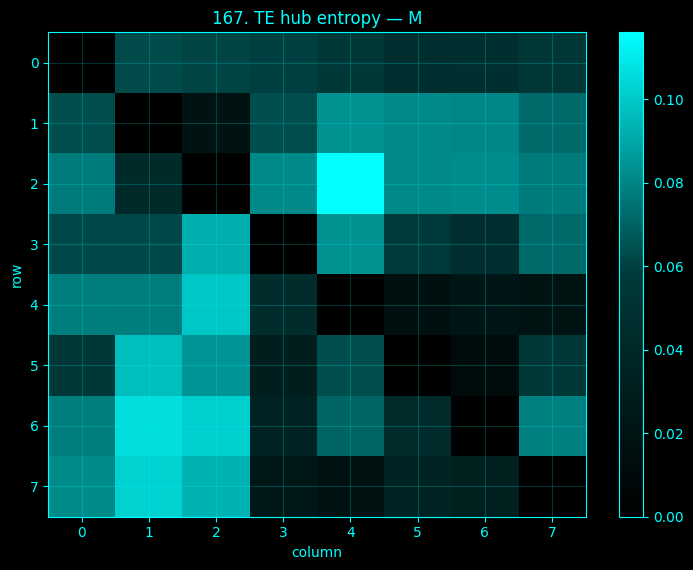

In [142]:
# =======================================================
# 167. TE hub entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: TE hub entropy normalizes total in+out TE strength across nodes and measures how
# concentrated network information flow is.
# =======================================================
def _entropy_method_167():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    M = _te_matrix(ch=min(8, len(S)))
    out = M.sum(1)
    inn = M.sum(0)
    strength = out + inn
    p = strength / (strength.sum() + ENT_EPS)
    _ent_print_args = ['TE hub entropy=', _H(p)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_167()
_ent_auto_plot(167, 'TE hub entropy', _ent_method_ns, ['S', 'cols', 'M', 'out', 'inn', 'strength', 'p', '_ent_print_args', 'a', 'b', 'c', 'j'])


### 168. TE motif entropy

TE motif entropy thresholds strong directed TE edges and measures entropy of triad edge-count motif classes.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


TE motif edge-count entropy= 1.5262302285647495


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


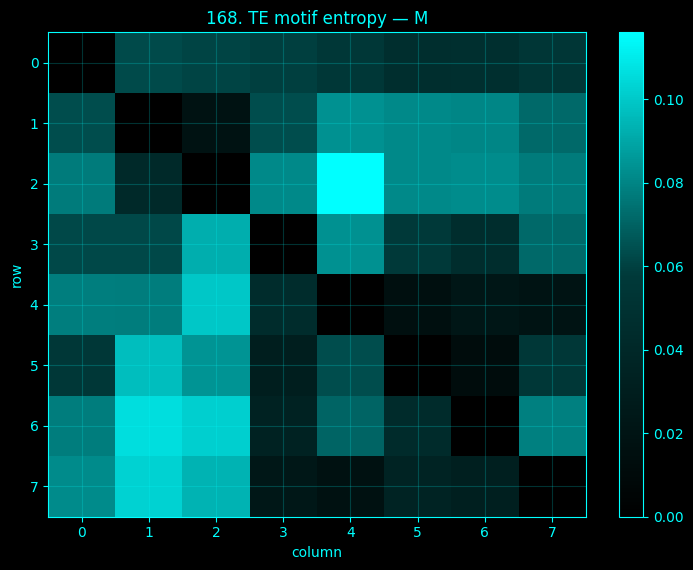

In [143]:
# =======================================================
# 168. TE motif entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: TE motif entropy thresholds strong directed TE edges and measures entropy of triad
# edge-count motif classes.
# =======================================================
def _entropy_method_168():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    M = _te_matrix(ch=min(8, len(S)))
    out = M.sum(1)
    inn = M.sum(0)
    th = np.quantile(M[M > 0], 0.75) if np.any(M > 0) else np.inf
    A = M > th
    mot = []
    for tri in __import__('itertools').combinations(range(len(M)), 3):
        mot.append(int(np.sum(A[np.ix_(tri, tri)])))
    _ent_print_args = ['TE motif edge-count entropy=', _H(_p_from_labels(mot))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_168()
_ent_auto_plot(168, 'TE motif entropy', _ent_method_ns, ['S', 'cols', 'M', 'out', 'inn', 'th', 'A', 'mot', 'tri', '_ent_print_args', 'a', 'b', 'c', 'j'])


### 169. TE cascade entropy

TE cascade entropy measures the distributional entropy of two-step cascade weights T_i→j T_j→k.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


TE cascade entropy= 2.4523892246065033


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


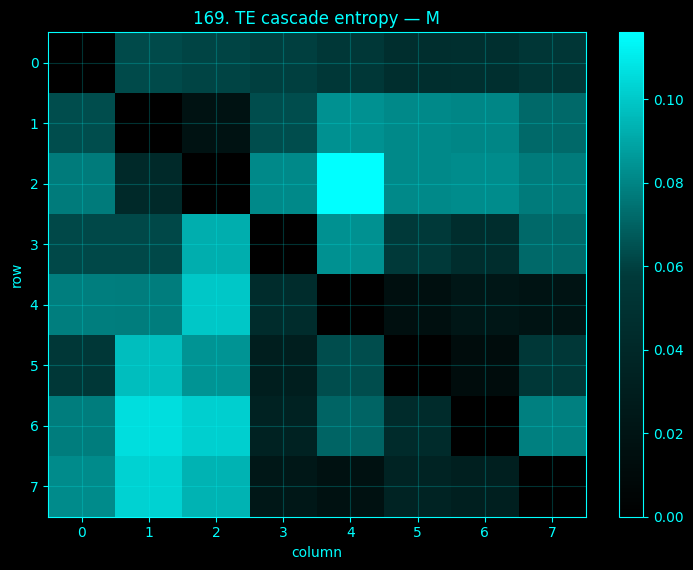

In [144]:
# =======================================================
# 169. TE cascade entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: TE cascade entropy measures the distributional entropy of two-step cascade weights
# T_i→j T_j→k.
# =======================================================
def _entropy_method_169():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    M = _te_matrix(ch=min(8, len(S)))
    out = M.sum(1)
    inn = M.sum(0)
    casc = []
    for aa in range(len(M)):
        for bb in range(len(M)):
            for cc in range(len(M)):
                if len({aa, bb, cc}) == 3:
                    casc.append(M[aa, bb] * M[bb, cc])
    casc = np.asarray(casc)
    _ent_print_args = ['TE cascade entropy=', _H(_hist_p(casc, 16))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_169()
_ent_auto_plot(169, 'TE cascade entropy', _ent_method_ns, ['S', 'cols', 'M', 'out', 'inn', 'casc', 'aa', '_ent_print_args', 'a', 'b', 'c', 'bb', 'j', 'cc'])


### 170. Directed Information

Massey directed information is sum_t I(X^t;Y_t|Y^(t-1)). The cell reports a first-order finite-history rate I((X_t-1,X_t);Y_t|Y_t-1).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [145]:
# =======================================================
# 170. Directed Information
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Massey directed information is sum_t I(X^t;Y_t|Y^(t-1)). The cell reports a first-order
# finite-history rate I((X_t-1,X_t);Y_t|Y_t-1).
# =======================================================
def _entropy_method_170():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    n = min(len(a), len(b))
    xp = a[:-1]
    xc = a[1:]
    yt = b[1:]
    yp = b[:-1]
    code = xp * 4 + xc
    rate = _CMI(code, yt, yp)
    _ent_print_args = ['Directed information rate (first-order finite-history)=', rate]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_170()
_ent_auto_plot(170, 'Directed Information', _ent_method_ns, ['S', 'cols', 'n', 'xp', 'xc', 'yt', 'yp', 'code', 'rate', '_ent_print_args', 'a', 'b', 'c', 'j'])


Directed information rate (first-order finite-history)= 0.31280187868956943


### 171. Causation Entropy

Causation Entropy is conditional mutual information from a candidate source past to a target future given an existing conditioning set; with the target past as condition it coincides with first-order TE.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike linear correlation, it can capture nonlinear statistical dependence. In delay-selection problems, mutual information between a signal and a delayed copy is examined as the delay changes; a local minimum is often used as a compromise between coordinates that are too redundant and coordinates that are almost unrelated. The estimate is sensitive to finite sample size and to how probability densities are estimated.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [146]:
# =======================================================
# 171. Causation Entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Causation Entropy is conditional mutual information from a candidate source past to a
# target future given an existing conditioning set; with the target past as condition it coincides
# with first-order TE.
# =======================================================
def _entropy_method_171():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    _ent_print_args = ['Causation Entropy C(ch0→ch1 | ch1 past)=', _te_discrete(a, b)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_171()
_ent_auto_plot(171, 'Causation Entropy', _ent_method_ns, ['S', 'cols', '_ent_print_args', 'a', 'b', 'c', 'j'])


Causation Entropy C(ch0→ch1 | ch1 past)= 0.06262490878530835


### 172. Conditional Causation Entropy

Conditional Causation Entropy enlarges the conditioning set to include another observed process.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [147]:
# =======================================================
# 172. Conditional Causation Entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Conditional Causation Entropy enlarges the conditioning set to include another observed
# process.
# =======================================================
def _entropy_method_172():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    _ent_print_args = ['Conditional Causation Entropy C(ch0→ch1 | ch1,ch2 past)=', _te_discrete(a, b, 1, c)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_172()
_ent_auto_plot(172, 'Conditional Causation Entropy', _ent_method_ns, ['S', 'cols', '_ent_print_args', 'a', 'b', 'c', 'j'])


Conditional Causation Entropy C(ch0→ch1 | ch1,ch2 past)= 0.08575588248768895


### 173. Information Flow Decomposition

The information-flow decomposition uses the exact chain rule I((Y_past,X_past);Y_t)=I(Y_past;Y_t)+I(X_past;Y_t|Y_past), separating self-predictive information from TE.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


{'self_predictive_AIS': 0.2322252023464655, 'conditional_source_TE': 0.06262490878530835, 'joint_predictive_information': 0.2948501111317743, 'chain_rule_residual': 4.440892098500626e-16}


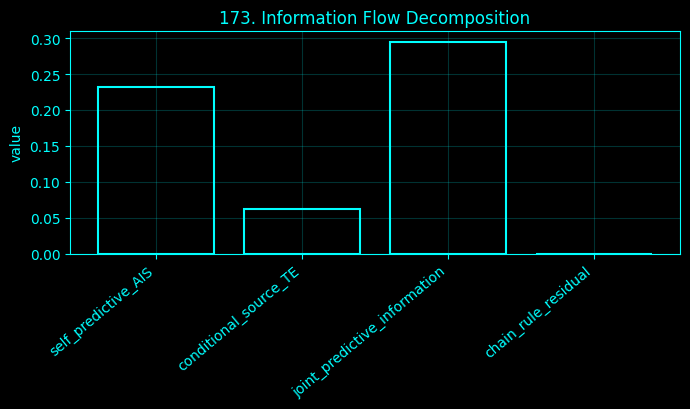

In [148]:
# =======================================================
# 173. Information Flow Decomposition
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: The information-flow decomposition uses the exact chain rule
# I((Y_past,X_past);Y_t)=I(Y_past;Y_t)+I(X_past;Y_t|Y_past), separating self-predictive information
# from TE.
# =======================================================
def _entropy_method_173():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    ais = _MI(b[:-1], b[1:])
    te = _te_discrete(a, b)
    joint = _MI(np.array([u * 4 + v for u, v in zip(b[:-1], a[:-1])]), b[1:])
    _ent_print_args = [{'self_predictive_AIS': ais, 'conditional_source_TE': te, 'joint_predictive_information': joint, 'chain_rule_residual': joint - (ais + te)}]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_173()
_ent_auto_plot(173, 'Information Flow Decomposition', _ent_method_ns, ['S', 'cols', 'ais', 'te', 'joint', '_ent_print_args', 'a', 'b', 'c', 'j', 'u', 'v'])


### 174. Granger-causality information entropy

For linear Gaussian variables, Granger/transfer information is 0.5 ln(var restricted / var full), the entropy reduction produced by adding the source predictor.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [149]:
# =======================================================
# 174. Granger-causality information entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For linear Gaussian variables, Granger/transfer information is 0.5 ln(var restricted /
# var full), the entropy reduction produced by adding the source predictor.
# =======================================================
def _entropy_method_174():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    _ent_print_args = ['Gaussian Granger/TE information ch0→ch1=', _gc_info(_ent_x[:, 0], _ent_x[:, 1])]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_174()
_ent_auto_plot(174, 'Granger-causality information entropy', _ent_method_ns, ['S', 'cols', '_ent_print_args', 'a', 'b', 'c', 'j'])


Gaussian Granger/TE information ch0→ch1= 0.0005538068579127562


### 175. Directed information rate

Directed information rate is reported using the same finite-history Massey conditional-information approximation as the directed-information cell.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [150]:
# =======================================================
# 175. Directed information rate
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Directed information rate is reported using the same finite-history Massey conditional-
# information approximation as the directed-information cell.
# =======================================================
def _entropy_method_175():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    n = min(len(a), len(b))
    xp = a[:-1]
    xc = a[1:]
    yt = b[1:]
    yp = b[:-1]
    code = xp * 4 + xc
    rate = _CMI(code, yt, yp)
    _ent_print_args = ['Directed information rate (first-order finite-history)=', rate]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_175()
_ent_auto_plot(175, 'Directed information rate', _ent_method_ns, ['S', 'cols', 'n', 'xp', 'xc', 'yt', 'yp', 'code', 'rate', '_ent_print_args', 'a', 'b', 'c', 'j'])


Directed information rate (first-order finite-history)= 0.31280187868956943


### 176. Feedback information decomposition

Feedback information diagnostics report TE in both directions, their sum as symmetric exchange and their difference as net directional balance; these summaries are not claimed to be orthogonal PID atoms.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


{'TE_X_to_Y': 0.06262490878530835, 'TE_Y_to_X': 0.06356836536114274, 'symmetric_exchange': 0.1261932741464511, 'net_feedback_direction': -0.0009434565758343894}


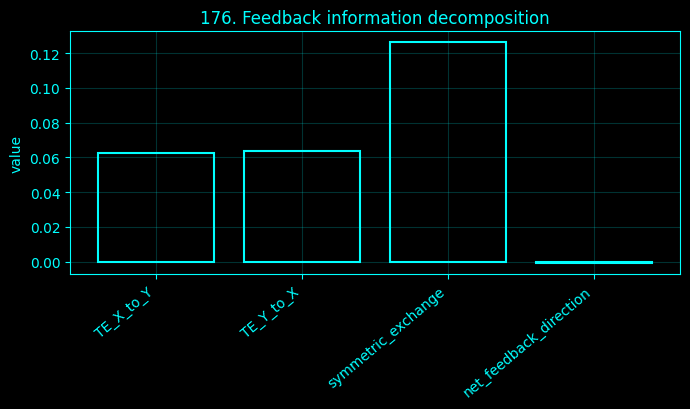

In [151]:
# =======================================================
# 176. Feedback information decomposition
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Feedback information diagnostics report TE in both directions, their sum as symmetric
# exchange and their difference as net directional balance; these summaries are not claimed to be
# orthogonal PID atoms.
# =======================================================
def _entropy_method_176():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    xy = _te_discrete(a, b)
    yx = _te_discrete(b, a)
    _ent_print_args = [{'TE_X_to_Y': xy, 'TE_Y_to_X': yx, 'symmetric_exchange': xy + yx, 'net_feedback_direction': xy - yx}]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_176()
_ent_auto_plot(176, 'Feedback information decomposition', _ent_method_ns, ['S', 'cols', 'xy', 'yx', '_ent_print_args', 'a', 'b', 'c', 'j'])


### 177. Causal conditioning entropy

Causal conditioning entropy H(Y_t|Y_past,X_past) is the remaining target uncertainty after conditioning on both target and source histories.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


causal conditioning entropy H(Y_t|Y_past,X_past)= 1.0914431623376446 without source= 1.154068071122953 reduction= 0.06262490878530835


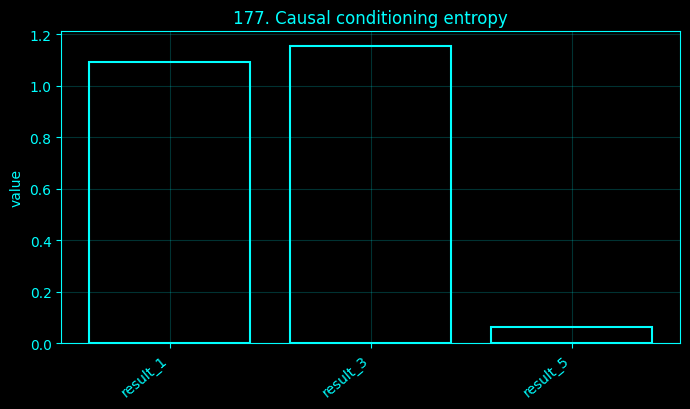

In [152]:
# =======================================================
# 177. Causal conditioning entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Causal conditioning entropy H(Y_t|Y_past,X_past) is the remaining target uncertainty
# after conditioning on both target and source histories.
# =======================================================
def _entropy_method_177():
    S = [_sym_ch(j) for j in range(min(8, _ent_x.shape[1]))]
    a, b, c = (S[0], S[1], S[2])
    cols = S[:4]
    h0 = _Hcols(b[1:], b[:-1]) - _H(_p_from_labels(b[:-1]))
    h1 = _Hcols(b[1:], b[:-1], a[:-1]) - _Hcols(b[:-1], a[:-1])
    _ent_print_args = ['causal conditioning entropy H(Y_t|Y_past,X_past)=', h1, 'without source=', h0, 'reduction=', h0 - h1]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_177()
_ent_auto_plot(177, 'Causal conditioning entropy', _ent_method_ns, ['S', 'cols', 'h0', 'h1', '_ent_print_args', 'a', 'b', 'c', 'j'])


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and role — graph, microstate, recurrence, phase, and divergence helpers for methods 178–233</h3>
<p>This foundation builds the probability objects used by graph/network entropy, topographic and microstate entropy, recurrence-line statistics, phase/CFC entropy, and distribution divergences. Examples include the trace-one graph Laplacian density \(\rho=L/\mathrm{Tr}(L)\) with von Neumann entropy \(-\mathrm{Tr}(\rho\log\rho)\), and Jensen–Shannon divergence \(\tfrac12D_{KL}(P\|M)+\tfrac12D_{KL}(Q\|M)\), \(M=(P+Q)/2\).</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [153]:
# =======================================================
# Shared primitives only; numbered cells below contain the method-specific mathematics.
# SHARED NUMERICAL PRIMITIVES — methods 178–233
# Graph/topographic/microstate/recurrence/phase/divergence entropy.
# =======================================================
import itertools
import networkx as nx
from scipy.spatial import Delaunay

_ENT_POS = {
'Fp1':(-0.50,0.98),'Fpz':(0.00,1.05),'Fp2':(0.50,0.98),'F7':(-0.92,0.62),'F3':(-0.48,0.62),'Fz':(0.00,0.67),'F4':(0.48,0.62),'F8':(0.92,0.62),
'FC5':(-0.70,0.32),'FC1':(-0.25,0.30),'FC2':(0.25,0.30),'FC6':(0.70,0.32),'M1':(-1.05,0.00),'T7':(-1.00,0.00),'C3':(-0.50,0.00),'Cz':(0.00,0.00),'C4':(0.50,0.00),'T8':(1.00,0.00),'M2':(1.05,0.00),
'CP5':(-0.70,-0.32),'CP1':(-0.25,-0.30),'CP2':(0.25,-0.30),'CP6':(0.70,-0.32),'P7':(-0.92,-0.62),'P3':(-0.48,-0.62),'Pz':(0.00,-0.67),'P4':(0.48,-0.62),'P8':(0.92,-0.62),'POz':(0.00,-0.84),'O1':(-0.45,-0.98),'Oz':(0.00,-1.05),'O2':(0.45,-0.98)}

def _safe_prob(v):
    v=np.asarray(v,float).ravel();v=np.clip(v,0,None);s=v.sum();return v/s if s>ENT_EPS else np.ones(max(1,len(v)))/max(1,len(v))

def _corr_graph(X=None, threshold=.35, absolute=True):
    X=np.asarray(_ent_x if X is None else X,float);R=np.corrcoef(X,rowvar=False);W=np.abs(R) if absolute else R.copy();np.fill_diagonal(W,0.)
    A=np.where(W>=float(threshold),W,0.);G=nx.from_numpy_array(A)
    return G,W,A

def _edge_weight_entropy(A):
    w=np.asarray(A,float)[np.triu_indices_from(A,1)];w=w[w>0];return _H(_safe_prob(w)) if len(w) else 0.0

def _degree_distribution_entropy(G):
    deg=np.array([d for _,d in G.degree()],int);return _H(_p_from_labels(deg)) if len(deg) else 0.0

def _laplacian_probs(A):
    L=np.diag(np.sum(A,axis=1))-A;lam=np.linalg.eigvalsh((L+L.T)/2);lam=np.clip(lam,0,None);return _safe_prob(lam),L

def _heat_density_entropy(A,beta=1.0):
    _,L=_laplacian_probs(A);lam=np.linalg.eigvalsh((L+L.T)/2);z=np.exp(-float(beta)*np.clip(lam,0,None));return _H(_safe_prob(z))

def _regions_indices():
    groups={'frontal':['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6'],
            'central':['T7','C3','Cz','C4','T8','M1','M2'],
            'posterior':['CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']}
    out={}
    for k,names in groups.items():out[k]=[i for i,n in enumerate(_ent_names) if n in names]
    return out

def _scalp_xy():
    xy=[]
    for k,n in enumerate(_ent_names):xy.append(_ENT_POS.get(n,(math.cos(2*math.pi*k/len(_ent_names)),math.sin(2*math.pi*k/len(_ent_names)))))
    return np.asarray(xy,float)

def _spatial_edges():
    xy=_scalp_xy()
    if len(xy)<3:return [(i,i+1) for i in range(len(xy)-1)]
    tri=Delaunay(xy);E=set()
    for s in tri.simplices:
        for a,b in itertools.combinations(s,2):E.add(tuple(sorted((int(a),int(b)))))
    return sorted(E)

def _pair_asymmetry(values):
    vals=np.asarray(values,float);pairs=[]
    lr=[('Fp1','Fp2'),('F7','F8'),('F3','F4'),('FC5','FC6'),('FC1','FC2'),('T7','T8'),('C3','C4'),('CP5','CP6'),('CP1','CP2'),('P7','P8'),('P3','P4'),('O1','O2'),('M1','M2')]
    idx={n:i for i,n in enumerate(_ent_names)}
    for l,r in lr:
        if l in idx and r in idx:pairs.append(abs(vals[idx[l]]-vals[idx[r]])/(abs(vals[idx[l]])+abs(vals[idx[r]])+ENT_EPS))
    return np.asarray(pairs,float)

def _microstates(K=4):
    X=np.asarray(_ent_x,float);step=max(1,len(X)//max(300,_ENT_SPEED['patterns']));Z=X[::step]
    gfp=np.std(Z,axis=1);keep=gfp>np.quantile(gfp,.25);Z=Z[keep];Z=Z/(np.linalg.norm(Z,axis=1,keepdims=True)+ENT_EPS)
    if len(Z)<K:return np.zeros(len(Z),int),np.eye(K,Z.shape[1])[:K]
    ids=np.linspace(0,len(Z)-1,K).astype(int);C=Z[ids].copy()
    for _ in range({'full':40,'balanced':30,'fast':20,'ultra':12}[FAST_OPTION]):
        R=Z@C.T;lab=np.argmax(np.abs(R),axis=1);C2=[]
        for k in range(K):
            zz=Z[lab==k]
            if not len(zz):C2.append(C[k]);continue
            sg=np.sign(zz@C[k]);sg[sg==0]=1;v=np.mean(zz*sg[:,None],axis=0);C2.append(v/(np.linalg.norm(v)+ENT_EPS))
        C2=np.asarray(C2)
        if np.linalg.norm(np.abs(C2@C.T)-np.eye(K))<1e-5: C=C2;break
        C=C2
    lab=np.argmax(np.abs(Z@C.T),axis=1)
    return lab,C

def _run_lengths(seq):
    seq=np.asarray(seq); 
    if not len(seq):return np.array([],int),np.array([],int)
    cuts=np.r_[0,1+np.flatnonzero(seq[1:]!=seq[:-1]),len(seq)];return seq[cuts[:-1]],np.diff(cuts)

def _recurrence(y=None,m=3,tau=1,rr=.05):
    y=_ent_y if y is None else np.asarray(y,float);X=_embed(_cap(y, {'full':1200,'balanced':900,'fast':650,'ultra':420}[FAST_OPTION]),m,tau,cap=False)
    if len(X)<3:return np.zeros((len(X),len(X)),bool)
    D=squareform(pdist(X,'euclidean'));d=D[np.triu_indices(len(D),1)];eps=np.quantile(d,float(rr));R=D<=eps;np.fill_diagonal(R,False);return R

def _line_lengths_bool(v,val=True,minlen=1):
    v=np.asarray(v,bool)==bool(val);z=np.r_[False,v,False];d=np.diff(z.astype(int));starts=np.flatnonzero(d==1);ends=np.flatnonzero(d==-1);L=ends-starts;return L[L>=minlen]

def _diag_lengths(R):
    out=[];n=len(R)
    for k in range(-n+1,n):out.extend(_line_lengths_bool(np.diag(R,k),True,2).tolist())
    return np.asarray(out,int)

def _vert_lengths(R,val=True):
    out=[]
    for j in range(R.shape[1]):out.extend(_line_lengths_bool(R[:,j],val,2).tolist())
    return np.asarray(out,int)

def _phase(y):return np.angle(signal.hilbert(np.asarray(y,float)))

def _plv(a,b):return float(abs(np.mean(np.exp(1j*(np.asarray(a)-np.asarray(b))))))

def _pac_distribution(y,plo=4,phi=8,alo=30,ahi=45,bins=18):
    if ahi>=.48*_ent_fs: ahi=.45*_ent_fs
    if phi>=alo:return np.ones(bins)/bins
    ph=_phase(_band(y,plo,phi));amp=np.abs(signal.hilbert(_band(y,alo,ahi)));edges=np.linspace(-np.pi,np.pi,bins+1);idx=np.clip(np.digitize(ph,edges)-1,0,bins-1);v=np.array([np.mean(amp[idx==k]) if np.any(idx==k) else 0 for k in range(bins)]);return _safe_prob(v)

def _common_hist_probs(x,y,bins=32):
    x=np.asarray(x,float);y=np.asarray(y,float);lo=min(np.min(x),np.min(y));hi=max(np.max(x),np.max(y));e=np.linspace(lo,hi,bins+1);p=np.histogram(x,e)[0].astype(float)+.5;q=np.histogram(y,e)[0].astype(float)+.5;return _safe_prob(p),_safe_prob(q),e

def _jsd(p,q):
    p=_safe_prob(p);q=_safe_prob(q);m=.5*(p+q);return float(.5*np.sum(p*np.log((p+ENT_EPS)/(m+ENT_EPS)))+.5*np.sum(q*np.log((q+ENT_EPS)/(m+ENT_EPS))))

def _kl(p,q):
    p=_safe_prob(p);q=_safe_prob(q);return float(np.sum(p*np.log((p+ENT_EPS)/(q+ENT_EPS))))

def _renyi_div(p,q,alpha=2.):
    p=_safe_prob(p);q=_safe_prob(q);a=float(alpha);return float(np.log(np.sum((p**a)*(q**(1-a)))+ENT_EPS)/(a-1))

def _tsallis_div(p,q,qord=2.):
    p=_safe_prob(p);q=_safe_prob(q);qq=float(qord);return float((np.sum((p**qq)*(q**(1-qq)))-1)/(qq-1))


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Execution router — entropy methods 178–233</h3>
<p>This dispatcher routes each catalogue index to the corresponding graph, topographic, microstate, recurrence, phase-coupling, or divergence analysis. It adds no new entropy definition and reuses a common EEG-derived graph/state representation where mathematically appropriate.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


**Explicit implementation note — methods 178–233.**  
The catalogue dispatcher has been removed. Each numbered method below now contains its own executable mathematics in that method's code cell. Only reusable numerical primitives and the shared black/cyan plotting utilities remain centralized.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


### 178. Graph entropy

Let $w_e\ge0$ be thresholded functional-connectivity edge weights and $p_e=w_e/\sum_f w_f$. This cell defines graph entropy as $H_E=-\sum_e p_e\ln p_e$. The definition is explicit because “graph entropy” is not unique.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


graph edge-weight Shannon entropy= 6.033566754340919


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


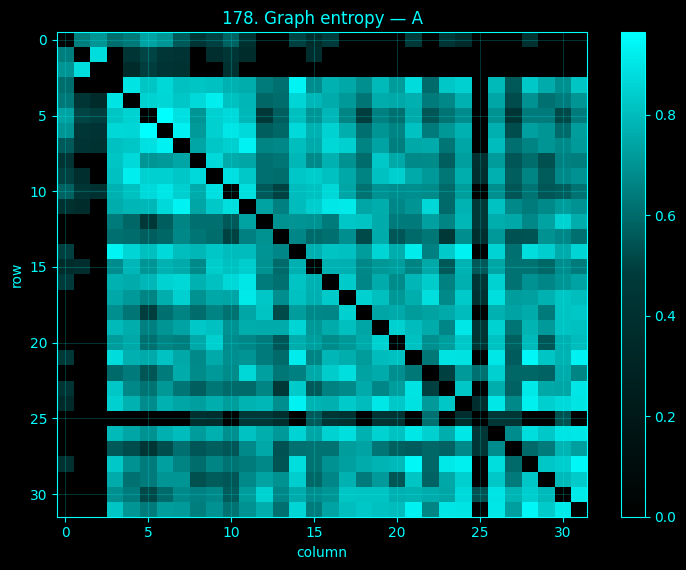

In [154]:
# =======================================================
# 178. Graph entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Let $w_e\ge0$ be thresholded functional-connectivity edge weights and $p_e=w_e/\sum_f
# w_f$. This cell defines graph entropy as $H_E=-\sum_e p_e\ln p_e$. The definition is explicit
# because “graph entropy” is not unique.
# =======================================================
def _entropy_method_178():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    _ent_print_args = ['graph edge-weight Shannon entropy=', _edge_weight_entropy(A)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_178()
_ent_auto_plot(178, 'Graph entropy', _ent_method_ns, ['X', 'y', '_ent_print_args', 'G', 'W', 'A'])


### 179. Degree-distribution entropy

If $p_k$ is the fraction of vertices with degree $k$, degree-distribution entropy is $H_D=-\sum_k p_k\ln p_k$. It measures heterogeneity of graph degree classes, not edge-weight uncertainty.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


degree-distribution entropy= 1.585298131547803


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


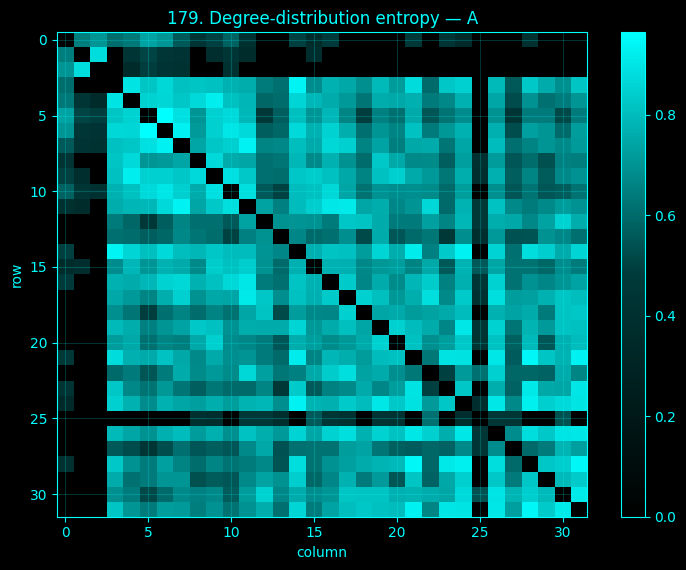

In [155]:
# =======================================================
# 179. Degree-distribution entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: If $p_k$ is the fraction of vertices with degree $k$, degree-distribution entropy is
# $H_D=-\sum_k p_k\ln p_k$. It measures heterogeneity of graph degree classes, not edge-weight
# uncertainty.
# =======================================================
def _entropy_method_179():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    _ent_print_args = ['degree-distribution entropy=', _degree_distribution_entropy(G)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_179()
_ent_auto_plot(179, 'Degree-distribution entropy', _ent_method_ns, ['X', 'y', '_ent_print_args', 'G', 'W', 'A'])


### 180. Node-strength entropy

For weighted node strength $s_i=\sum_jw_{ij}$, set $p_i=s_i/\sum_js_j$. Node-strength entropy is $-\sum_i p_i\ln p_i$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


node-strength entropy= 3.4192412045616845


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


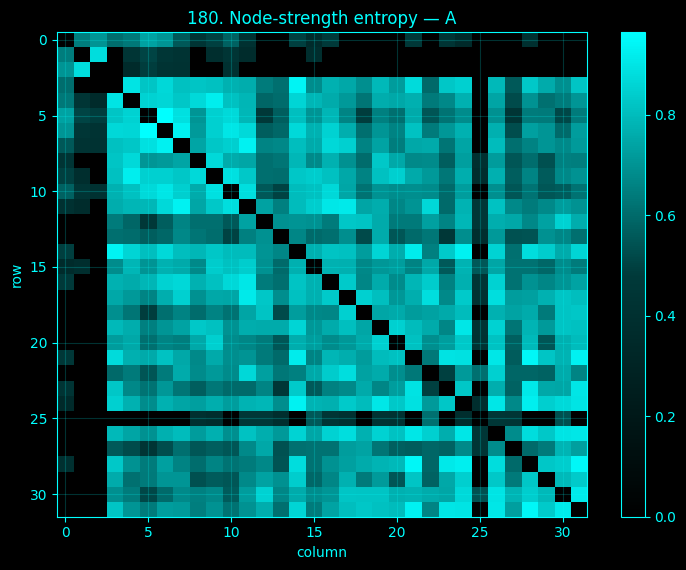

In [156]:
# =======================================================
# 180. Node-strength entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For weighted node strength $s_i=\sum_jw_{ij}$, set $p_i=s_i/\sum_js_j$. Node-strength
# entropy is $-\sum_i p_i\ln p_i$.
# =======================================================
def _entropy_method_180():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    s = A.sum(1)
    _ent_print_args = ['node-strength entropy=', _H(_safe_prob(s))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_180()
_ent_auto_plot(180, 'Node-strength entropy', _ent_method_ns, ['X', 'y', 's', '_ent_print_args', 'G', 'W', 'A'])


### 181. Laplacian graph entropy

For the combinatorial Laplacian $L=D-W$ with eigenvalues $\lambda_i\ge0$, this cell uses $p_i=\lambda_i/\mathrm{tr}(L)$ and $H_L=-\sum_i p_i\ln p_i$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Laplacian graph entropy 3.384322237869619


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


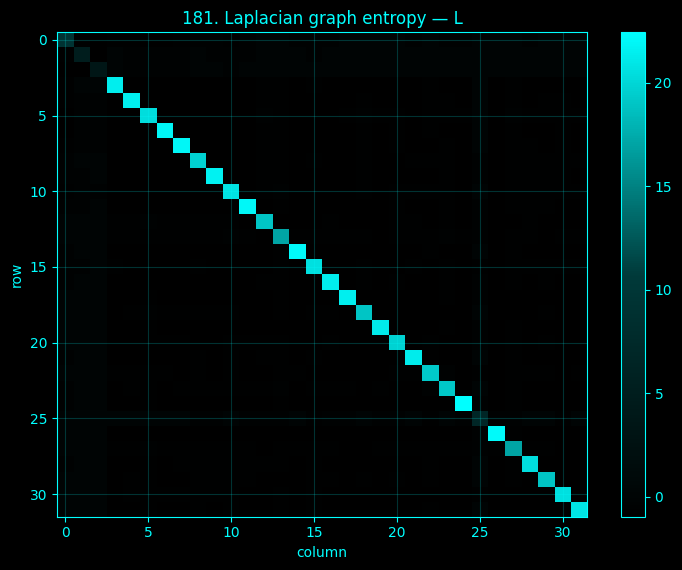

In [157]:
# =======================================================
# 181. Laplacian graph entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For the combinatorial Laplacian $L=D-W$ with eigenvalues $\lambda_i\ge0$, this cell
# uses $p_i=\lambda_i/\mathrm{tr}(L)$ and $H_L=-\sum_i p_i\ln p_i$.
# =======================================================
def _entropy_method_181():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    p, L = _laplacian_probs(A)
    h = _H(p)
    _ent_print_args = ['Laplacian graph entropy', h]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_181()
_ent_auto_plot(181, 'Laplacian graph entropy', _ent_method_ns, ['X', 'y', 'h', '_ent_print_args', 'G', 'W', 'A', 'p', 'L'])


### 182. Von Neumann graph entropy

The trace-one graph density operator is $\rho=L/\mathrm{tr}(L)$. Von Neumann entropy is $S(\rho)=-\mathrm{tr}(\rho\ln\rho)=-\sum_i\lambda_i(\rho)\ln\lambda_i(\rho)$. With this Laplacian density it numerically equals method 181 by construction.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Von Neumann graph entropy S(L/tr L) 3.384322237869619


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


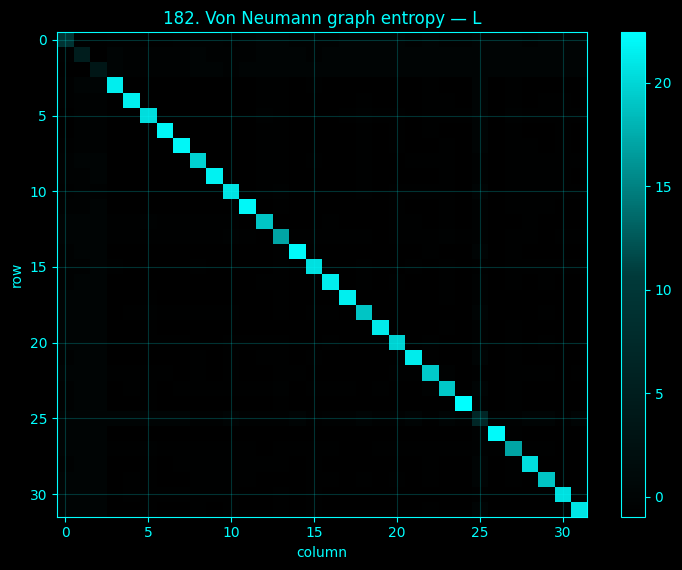

In [158]:
# =======================================================
# 182. Von Neumann graph entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: The trace-one graph density operator is $\rho=L/\mathrm{tr}(L)$. Von Neumann entropy is
# $S(\rho)=-\mathrm{tr}(\rho\ln\rho)=-\sum_i\lambda_i(\rho)\ln\lambda_i(\rho)$. With this Laplacian
# density it numerically equals method 181 by construction.
# =======================================================
def _entropy_method_182():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    p, L = _laplacian_probs(A)
    h = _H(p)
    _ent_print_args = ['Von Neumann graph entropy S(L/tr L)', h]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_182()
_ent_auto_plot(182, 'Von Neumann graph entropy', _ent_method_ns, ['X', 'y', 'h', '_ent_print_args', 'G', 'W', 'A', 'p', 'L'])


### 183. Network spectral entropy

A scale-dependent network spectral density is $\rho_\beta=e^{-\beta L}/\mathrm{tr}(e^{-\beta L})$. Its entropy $S_\beta=-\mathrm{tr}(\rho_\beta\ln\rho_\beta)$ describes diffusion-mode occupancy as the diffusion scale $\beta$ changes.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Spectral entropy treats the normalized power spectrum as a probability distribution over frequency bins and applies Shannon entropy to that distribution. If power is concentrated in only a few frequencies, the distribution is uneven and entropy is low. If power is spread broadly across many frequencies, entropy is higher. The result therefore describes spectral dispersion, not temporal unpredictability in exactly the same sense as Sample Entropy or permutation entropy.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


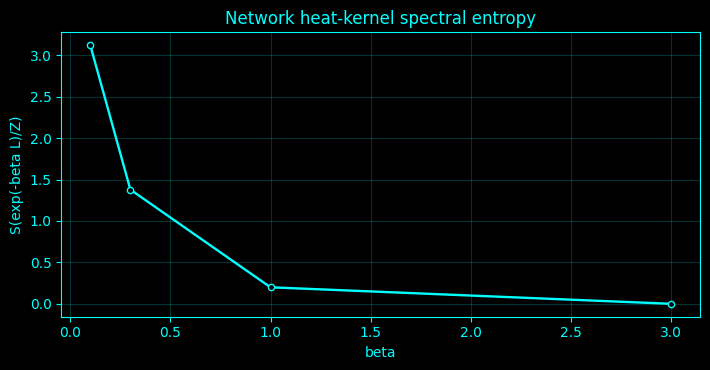

In [159]:
# =======================================================
# 183. Network spectral entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: A scale-dependent network spectral density is $\rho_\beta=e^{-\beta
# L}/\mathrm{tr}(e^{-\beta L})$. Its entropy $S_\beta=-\mathrm{tr}(\rho_\beta\ln\rho_\beta)$ describes
# diffusion-mode occupancy as the diffusion scale $\beta$ changes.
# =======================================================
def _entropy_method_183():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    betas = np.array([0.1, 0.3, 1.0, 3.0])
    _line(betas, [_heat_density_entropy(A, b) for b in betas], 'Network heat-kernel spectral entropy', 'beta', 'S(exp(-beta L)/Z)')
    return locals()
_ent_method_ns = _entropy_method_183()


### 184. Modularity entropy

After modularity communities are estimated, each community is assigned its within-community edge mass $m_c$. This cell reports Shannon entropy of $p_c=m_c/\sum_dm_d$ alongside weighted modularity $Q$; it is a block-mass entropy, not a new definition of $Q$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


modularity block-mass entropy= 0.6499049614174075 weighted modularity= 0.04165666794769385


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


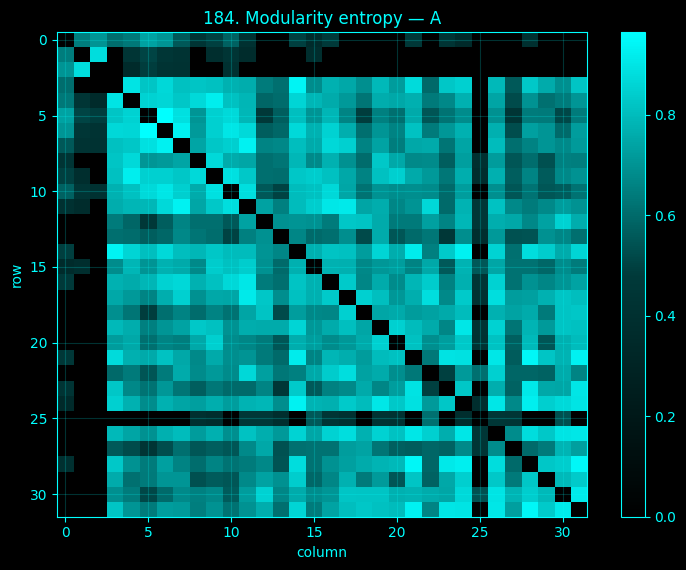

In [160]:
# =======================================================
# 184. Modularity entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: After modularity communities are estimated, each community is assigned its within-
# community edge mass $m_c$. This cell reports Shannon entropy of $p_c=m_c/\sum_dm_d$ alongside
# weighted modularity $Q$; it is a block-mass entropy, not a new definition of $Q$.
# =======================================================
def _entropy_method_184():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    if G.number_of_edges() == 0:
        _ent_print_args = ['graph has no thresholded edges']
        print(*_ent_print_args)
        return locals()
    comm = list(nx.algorithms.community.greedy_modularity_communities(G, weight='weight'))
    mass = []
    for c in comm:
        ids = sorted(c)
        mass.append(np.sum(A[np.ix_(ids, ids)]) / 2)
    _ent_print_args = ['modularity block-mass entropy=', _H(_safe_prob(mass)), 'weighted modularity=', nx.algorithms.community.modularity(G, comm, weight='weight')]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_184()
_ent_auto_plot(184, 'Modularity entropy', _ent_method_ns, ['X', 'y', 'comm', 'mass', 'c', '_ent_print_args', 'G', 'W', 'A', 'ids'])


### 185. Community-assignment entropy

For community labels $C$, community-assignment entropy is $H(C)=-\sum_cp_c\ln p_c$ where $p_c$ is the fraction of nodes in community $c$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


community-assignment entropy= 0.6853142072764582 communities= 2


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


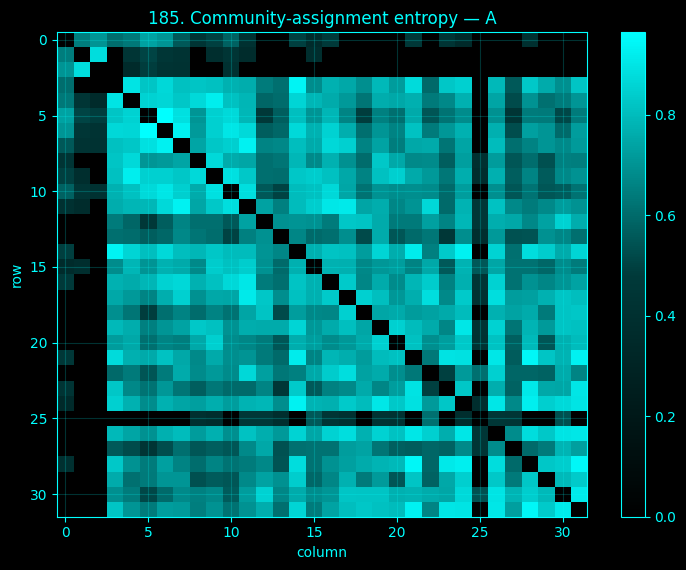

In [161]:
# =======================================================
# 185. Community-assignment entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For community labels $C$, community-assignment entropy is $H(C)=-\sum_cp_c\ln p_c$
# where $p_c$ is the fraction of nodes in community $c$.
# =======================================================
def _entropy_method_185():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    if G.number_of_edges() == 0:
        _ent_print_args = ['graph has no thresholded edges']
        print(*_ent_print_args)
        return locals()
    comm = list(nx.algorithms.community.greedy_modularity_communities(G, weight='weight'))
    _ent_print_args = ['community-assignment entropy=', _H(_safe_prob([len(c) for c in comm])), 'communities=', len(comm)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_185()
_ent_auto_plot(185, 'Community-assignment entropy', _ent_method_ns, ['X', 'y', 'comm', '_ent_print_args', 'G', 'W', 'A', 'c'])


### 186. MST branch entropy

The maximum spanning tree preserves the strongest connected backbone. Its branch entropy is Shannon entropy of the MST degree distribution, $H=-\sum_kp_k\ln p_k$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


MST branch-degree entropy= 1.2449791504260663


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


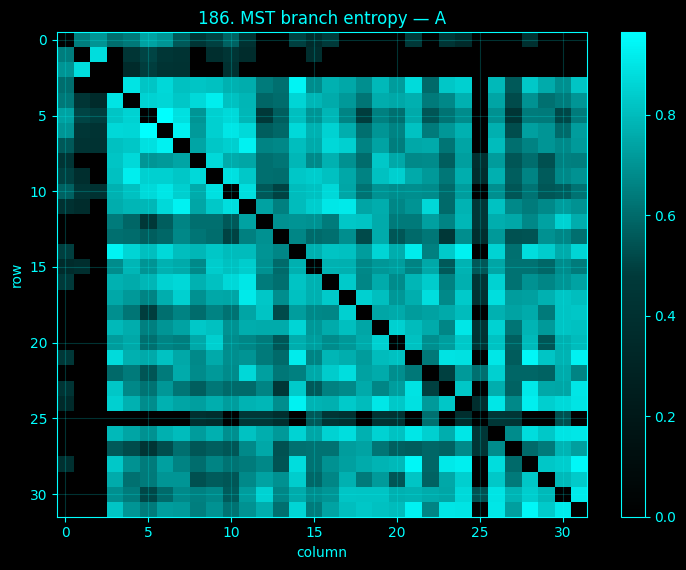

In [162]:
# =======================================================
# 186. MST branch entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: The maximum spanning tree preserves the strongest connected backbone. Its branch
# entropy is Shannon entropy of the MST degree distribution, $H=-\sum_kp_k\ln p_k$.
# =======================================================
def _entropy_method_186():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    H = nx.from_numpy_array(W)
    T = nx.maximum_spanning_tree(H, weight='weight')
    _ent_print_args = ['MST branch-degree entropy=', _degree_distribution_entropy(T)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_186()
_ent_auto_plot(186, 'MST branch entropy', _ent_method_ns, ['X', 'y', 'H', 'T', '_ent_print_args', 'G', 'W', 'A'])


### 187. Cycle-basis entropy

A cycle basis is summarized by cycle lengths $\ell$. The cell reports Shannon entropy of the empirical length distribution $p(\ell)$; this measures diversity of basis-cycle sizes and depends on the chosen cycle basis.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


cycle-basis length entropy= 2.5535129566378565e-15 cycles= 394


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


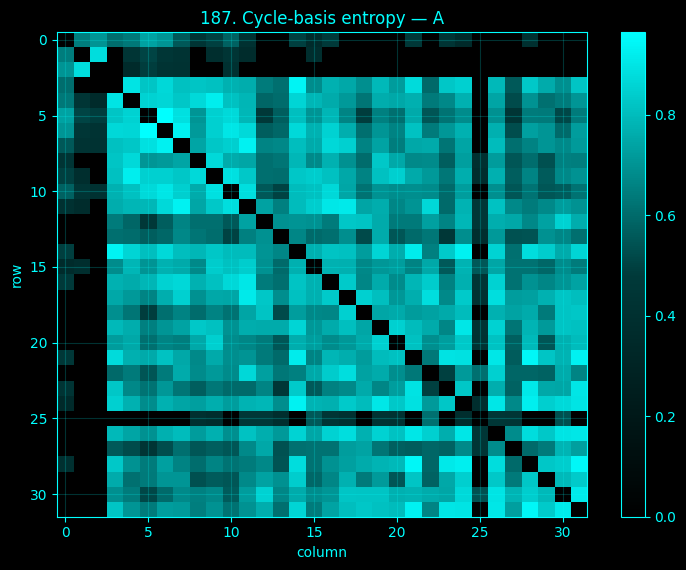

In [163]:
# =======================================================
# 187. Cycle-basis entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: A cycle basis is summarized by cycle lengths $\ell$. The cell reports Shannon entropy
# of the empirical length distribution $p(\ell)$; this measures diversity of basis-cycle sizes and
# depends on the chosen cycle basis.
# =======================================================
def _entropy_method_187():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    cyc = nx.cycle_basis(G)
    lens = [len(c) for c in cyc]
    _ent_print_args = ['cycle-basis length entropy=', _H(_p_from_labels(lens)) if lens else 0.0, 'cycles=', len(cyc)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_187()
_ent_auto_plot(187, 'Cycle-basis entropy', _ent_method_ns, ['X', 'y', 'cyc', 'lens', '_ent_print_args', 'G', 'W', 'A', 'c'])


### 188. Functional-connectivity entropy

Functional-connectivity entropy uses all positive upper-triangle connection magnitudes as weights $p_e\propto |r_{ij}|$ and computes $-\sum_ep_e\ln p_e$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


functional-connectivity edge entropy= 6.111483117065338


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


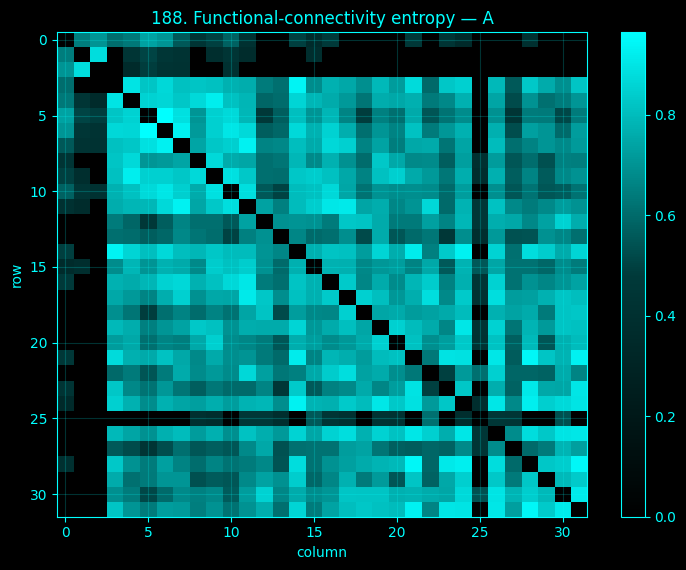

In [164]:
# =======================================================
# 188. Functional-connectivity entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Functional-connectivity entropy uses all positive upper-triangle connection magnitudes
# as weights $p_e\propto |r_{ij}|$ and computes $-\sum_ep_e\ln p_e$.
# =======================================================
def _entropy_method_188():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    _ent_print_args = ['functional-connectivity edge entropy=', _edge_weight_entropy(W)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_188()
_ent_auto_plot(188, 'Functional-connectivity entropy', _ent_method_ns, ['X', 'y', '_ent_print_args', 'G', 'W', 'A'])


### 189. Threshold-sweep graph entropy

The connectivity threshold is swept and edge-weight entropy is recomputed at each threshold. This tests whether graph-entropy conclusions depend on an arbitrary sparsification level.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


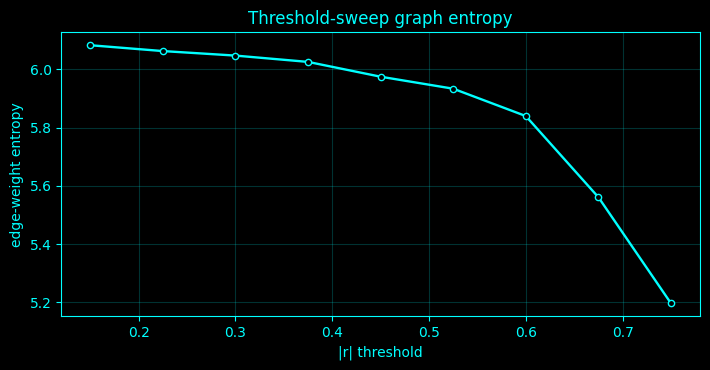

In [165]:
# =======================================================
# 189. Threshold-sweep graph entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: The connectivity threshold is swept and edge-weight entropy is recomputed at each
# threshold. This tests whether graph-entropy conclusions depend on an arbitrary sparsification level.
# =======================================================
def _entropy_method_189():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    th = np.linspace(0.15, 0.75, 9)
    vals = []
    for q in th:
        vals.append(_edge_weight_entropy(np.where(W >= q, W, 0)))
    _line(th, vals, 'Threshold-sweep graph entropy', '|r| threshold', 'edge-weight entropy')
    return locals()
_ent_method_ns = _entropy_method_189()


### 190. Band-specific network entropy

Each canonical EEG band is band-pass filtered, a channel correlation graph is formed, and Shannon entropy of its edge weights is computed. Frequency bands above the effective Nyquist frequency are omitted.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,band,network_entropy
0,delta,5.988784
1,theta,5.978733
2,alpha,5.996586
3,beta,5.962820
4,gamma,6.021689


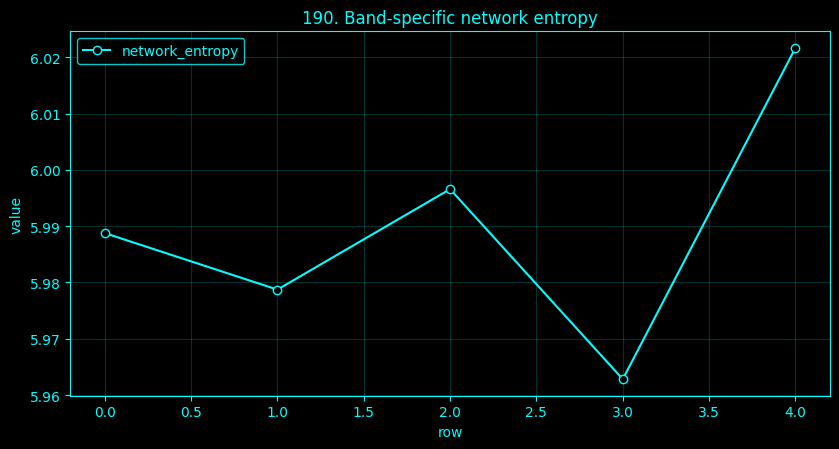

In [166]:
# =======================================================
# 190. Band-specific network entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Each canonical EEG band is band-pass filtered, a channel correlation graph is formed,
# and Shannon entropy of its edge weights is computed. Frequency bands above the effective Nyquist
# frequency are omitted.
# =======================================================
def _entropy_method_190():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    rows = []
    for name, (lo, hi) in _ENT_BANDS.items():
        if hi < 0.48 * _ent_fs:
            B = np.column_stack([_band(X[:, j], lo, hi) for j in range(X.shape[1])])
            _, WW, _ = _corr_graph(B, 0.35)
            rows.append([name, _edge_weight_entropy(WW)])
    _ent_display_result = pd.DataFrame(rows, columns=['band', 'network_entropy'])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_190()
_ent_auto_plot(190, 'Band-specific network entropy', _ent_method_ns, ['X', 'y', 'rows', '_ent_display_result', 'G', 'W', 'A', 'name', 'lo', 'hi', 'B', '_', 'WW', 'j'])


### 191. Dynamic network entropy

For each sliding window $t$, a functional graph is estimated and $H_E(t)=-\sum_ep_e(t)\ln p_e(t)$ is reported. Window count is controlled by full/balanced/fast/ultra.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


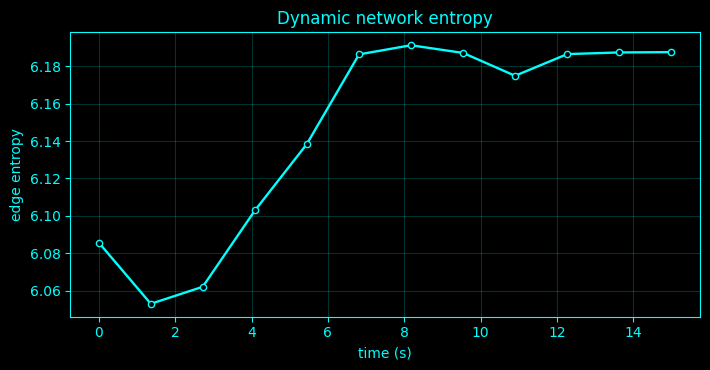

In [167]:
# =======================================================
# 191. Dynamic network entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For each sliding window $t$, a functional graph is estimated and
# $H_E(t)=-\sum_ep_e(t)\ln p_e(t)$ is reported. Window count is controlled by
# full/balanced/fast/ultra.
# =======================================================
def _entropy_method_191():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    Wn = max(100, int(3 * _ent_fs))
    starts = np.linspace(0, max(0, len(X) - Wn), _ENT_SPEED['windows']).astype(int)
    v = []
    for s in starts:
        _, WW, _ = _corr_graph(X[s:s + Wn], 0.35)
        v.append(_edge_weight_entropy(WW))
    _line(starts / _ent_fs, v, 'Dynamic network entropy', 'time (s)', 'edge entropy')
    return locals()
_ent_method_ns = _entropy_method_191()


### 192. Regional graph entropy

Channels are aggregated into broad anatomical regions. The regional weight matrix contains mean inter-region absolute correlations, and its positive edge masses are normalized before Shannon entropy is computed.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


regional graph entropy= 1.0913542572007386


,frontal,central,posterior
frontal,0.613254,0.583033,0.529076
central,0.583033,0.618601,0.704764
posterior,0.529076,0.704764,0.655324


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


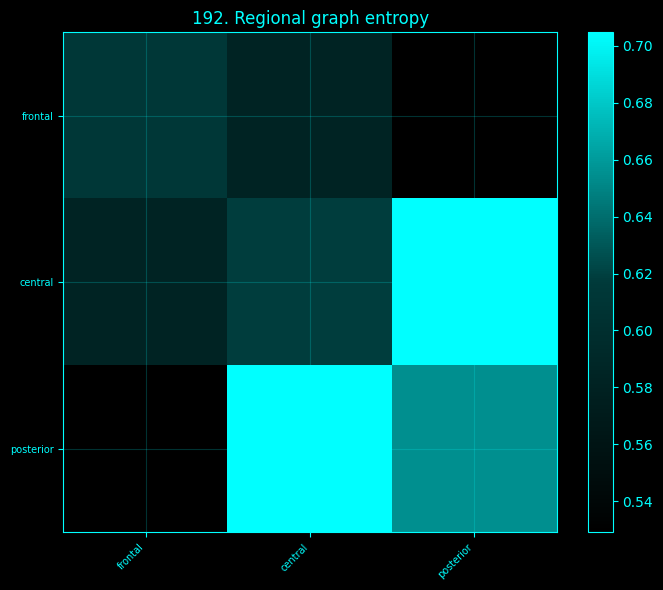

In [168]:
# =======================================================
# 192. Regional graph entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Channels are aggregated into broad anatomical regions. The regional weight matrix
# contains mean inter-region absolute correlations, and its positive edge masses are normalized before
# Shannon entropy is computed.
# =======================================================
def _entropy_method_192():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    regs = _regions_indices()
    names = list(regs)
    M = np.zeros((len(names), len(names)))
    for a, ra in enumerate(names):
        for b, rb in enumerate(names):
            if regs[ra] and regs[rb]:
                M[a, b] = np.mean(W[np.ix_(regs[ra], regs[rb])])
    _ent_print_args = ['regional graph entropy=', _edge_weight_entropy(M)]
    print(*_ent_print_args)
    _ent_display_result = pd.DataFrame(M, index=names, columns=names)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_192()
_ent_auto_plot(192, 'Regional graph entropy', _ent_method_ns, ['X', 'y', 'regs', 'names', 'M', '_ent_print_args', '_ent_display_result', 'G', 'W', 'A', 'a', 'ra', 'b', 'rb'])


### 193. Hubness entropy

Hubness is represented by weighted degree/strength $h_i$. Hubness entropy is $H=-\sum_i(h_i/\sum_jh_j)\ln(h_i/\sum_jh_j)$; low values indicate concentration on a few hubs.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


hubness entropy= 3.4192412045616845


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


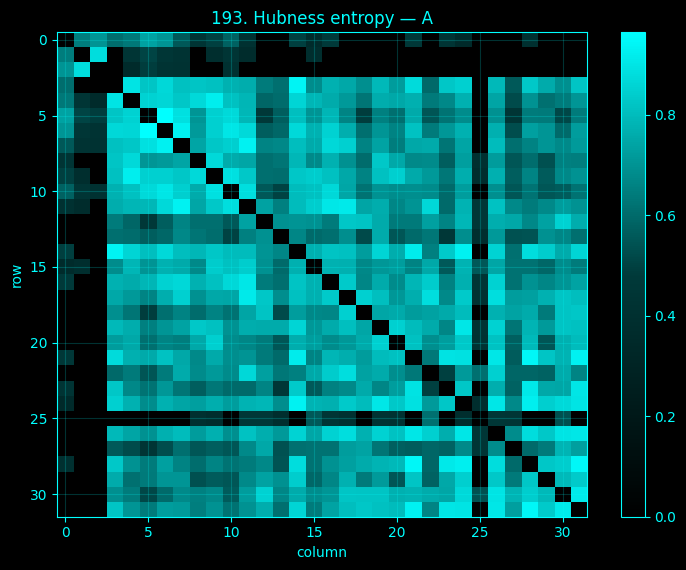

In [169]:
# =======================================================
# 193. Hubness entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Hubness is represented by weighted degree/strength $h_i$. Hubness entropy is
# $H=-\sum_i(h_i/\sum_jh_j)\ln(h_i/\sum_jh_j)$; low values indicate concentration on a few hubs.
# =======================================================
def _entropy_method_193():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    h = np.array([d for _, d in G.degree(weight='weight')], float)
    _ent_print_args = ['hubness entropy=', _H(_safe_prob(h))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_193()
_ent_auto_plot(193, 'Hubness entropy', _ent_method_ns, ['X', 'y', 'h', '_ent_print_args', 'G', 'W', 'A', '_', 'd'])


### 194. Topographic entropy

With channel powers $P_i=\mathrm{Var}(x_i)$, topographic entropy is $H=-\sum_i p_i\ln p_i$ for $p_i=P_i/\sum_jP_j$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


topographic power entropy= 3.4657359027997265


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


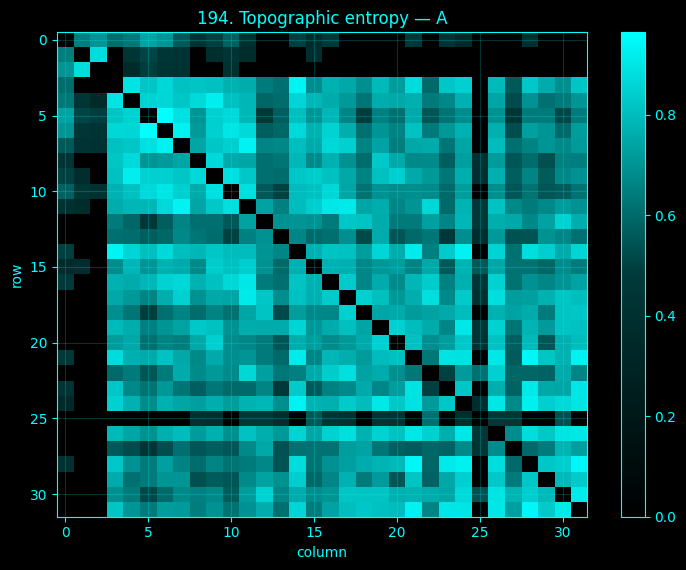

In [170]:
# =======================================================
# 194. Topographic entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: With channel powers $P_i=\mathrm{Var}(x_i)$, topographic entropy is $H=-\sum_i p_i\ln
# p_i$ for $p_i=P_i/\sum_jP_j$.
# =======================================================
def _entropy_method_194():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    _ent_print_args = ['topographic power entropy=', _H(_safe_prob(powv))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_194()
_ent_auto_plot(194, 'Topographic entropy', _ent_method_ns, ['X', 'y', 'powv', '_ent_print_args', 'G', 'W', 'A'])


### 195. Scalp-map amplitude entropy

At each time sample, scalp amplitudes are converted to nonnegative masses $p_i(t)=|x_i(t)|/\sum_j|x_j(t)|$. The cell averages $H(t)=-\sum_ip_i(t)\ln p_i(t)$ over time.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


mean scalp-map amplitude entropy= 3.2651139245179124


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


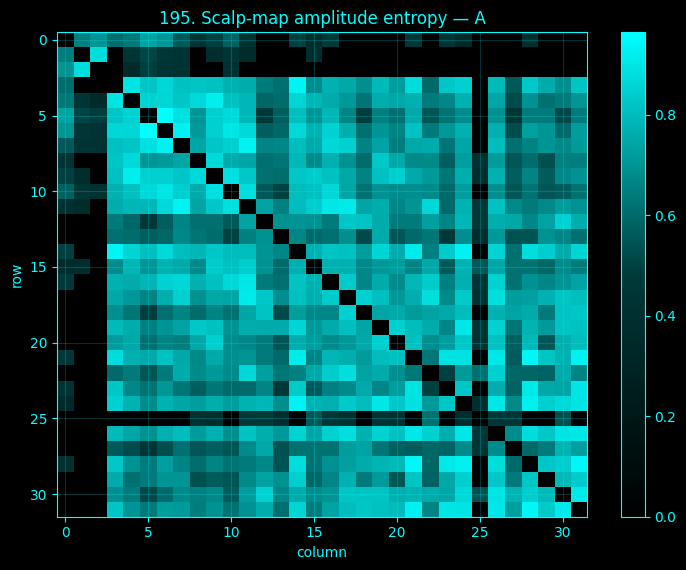

In [171]:
# =======================================================
# 195. Scalp-map amplitude entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: At each time sample, scalp amplitudes are converted to nonnegative masses
# $p_i(t)=|x_i(t)|/\sum_j|x_j(t)|$. The cell averages $H(t)=-\sum_ip_i(t)\ln p_i(t)$ over time.
# =======================================================
def _entropy_method_195():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    Z = np.abs(X)
    P = Z / (Z.sum(1, keepdims=True) + ENT_EPS)
    ht = -np.sum(P * np.log(P + ENT_EPS), axis=1)
    _ent_print_args = ['mean scalp-map amplitude entropy=', float(np.mean(ht))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_195()
_ent_auto_plot(195, 'Scalp-map amplitude entropy', _ent_method_ns, ['X', 'y', 'powv', 'Z', 'P', 'ht', '_ent_print_args', 'G', 'W', 'A'])


### 196. Scalp-map gradient entropy

Electrodes are connected by a 2-D Delaunay mesh. Edge gradient magnitude is approximated by $g_{ij}=|P_i-P_j|/\|r_i-r_j\|$, then normalized across mesh edges and entropized.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


scalp-map gradient entropy= 3.9971021642286084 Delaunay edges= 81


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


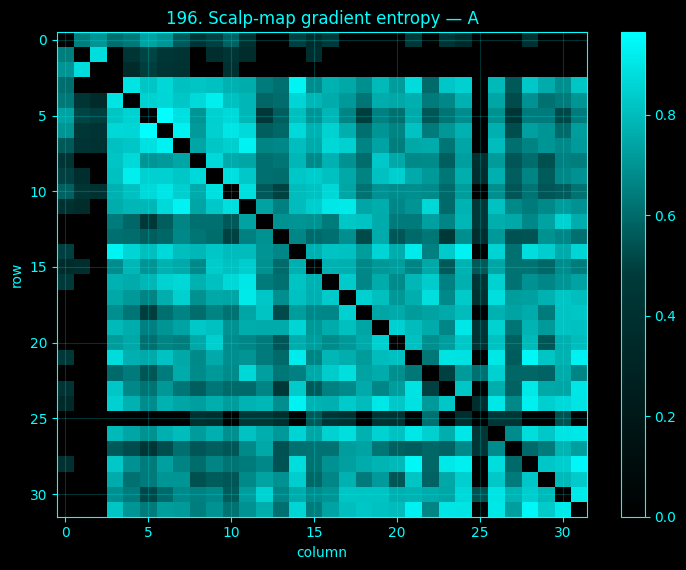

In [172]:
# =======================================================
# 196. Scalp-map gradient entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Electrodes are connected by a 2-D Delaunay mesh. Edge gradient magnitude is
# approximated by $g_{ij}=|P_i-P_j|/\|r_i-r_j\|$, then normalized across mesh edges and entropized.
# =======================================================
def _entropy_method_196():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    xy = _scalp_xy()
    edges = _spatial_edges()
    g = []
    for a, b in edges:
        g.append(abs(powv[a] - powv[b]) / (np.linalg.norm(xy[a] - xy[b]) + ENT_EPS))
    _ent_print_args = ['scalp-map gradient entropy=', _H(_safe_prob(g)), 'Delaunay edges=', len(edges)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_196()
_ent_auto_plot(196, 'Scalp-map gradient entropy', _ent_method_ns, ['X', 'y', 'powv', 'xy', 'edges', 'g', '_ent_print_args', 'G', 'W', 'A', 'a', 'b'])


### 197. Topographic bandpower entropy

For each EEG band, channel band powers are normalized as a spatial probability vector and Shannon entropy is computed. This measures how broadly band power is distributed over the scalp.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,band,topographic_entropy
0,delta,2.936375
1,theta,3.225448
2,alpha,3.310057
3,beta,3.139804
4,gamma,3.063532


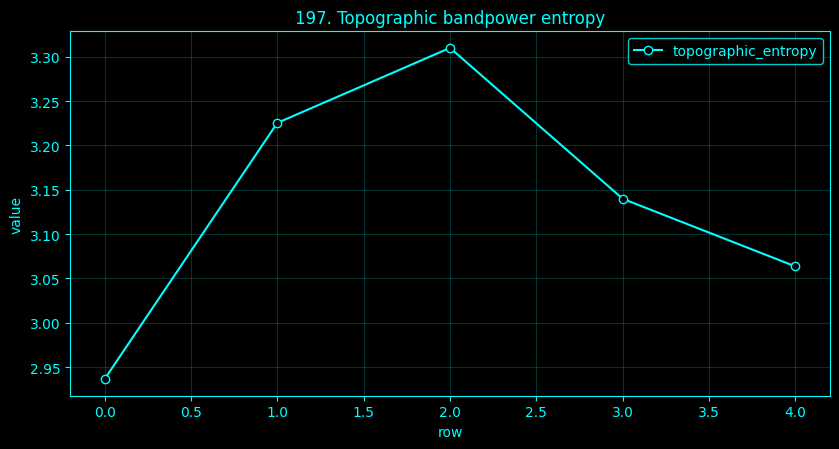

In [173]:
# =======================================================
# 197. Topographic bandpower entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For each EEG band, channel band powers are normalized as a spatial probability vector
# and Shannon entropy is computed. This measures how broadly band power is distributed over the scalp.
# =======================================================
def _entropy_method_197():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    rows = []
    for name, (lo, hi) in _ENT_BANDS.items():
        if hi < 0.48 * _ent_fs:
            bp = np.array([np.mean(_band(X[:, j], lo, hi) ** 2) for j in range(X.shape[1])])
            rows.append([name, _H(_safe_prob(bp))])
    _ent_display_result = pd.DataFrame(rows, columns=['band', 'topographic_entropy'])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_197()
_ent_auto_plot(197, 'Topographic bandpower entropy', _ent_method_ns, ['X', 'y', 'powv', 'rows', '_ent_display_result', 'G', 'W', 'A', 'name', 'lo', 'hi', 'bp', 'j'])


### 198. Topographic asymmetry entropy

For homologous left-right pairs, normalized asymmetry is $a=(|P_L-P_R|)/(P_L+P_R)$. The positive pairwise asymmetry magnitudes are normalized and their Shannon entropy is reported; this is distinct from mean lateralization.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


topographic asymmetry entropy= 2.564949357461537 pairs= 13


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


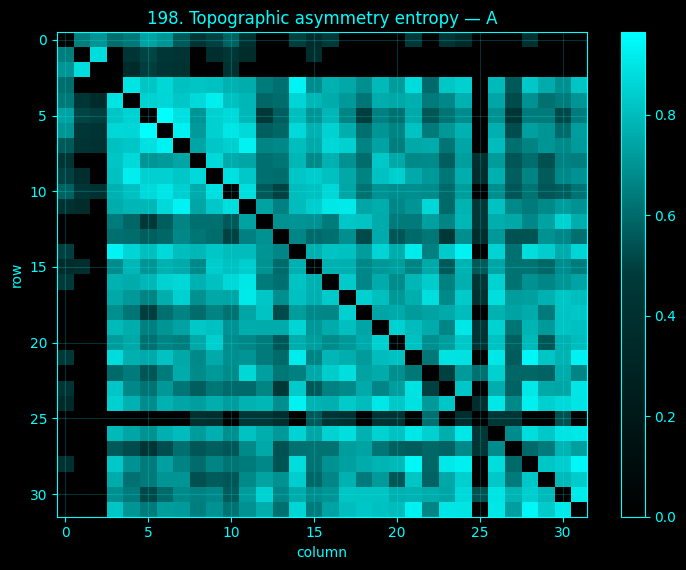

In [174]:
# =======================================================
# 198. Topographic asymmetry entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For homologous left-right pairs, normalized asymmetry is $a=(|P_L-P_R|)/(P_L+P_R)$. The
# positive pairwise asymmetry magnitudes are normalized and their Shannon entropy is reported; this is
# distinct from mean lateralization.
# =======================================================
def _entropy_method_198():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    a = _pair_asymmetry(powv)
    _ent_print_args = ['topographic asymmetry entropy=', _H(_safe_prob(a)) if len(a) else 0.0, 'pairs=', len(a)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_198()
_ent_auto_plot(198, 'Topographic asymmetry entropy', _ent_method_ns, ['X', 'y', 'powv', 'a', '_ent_print_args', 'G', 'W', 'A'])


### 199. Regional topographic entropy

Within each broad scalp region, channel powers are normalized locally and Shannon entropy is computed, giving within-region spatial dispersion rather than a global topographic score.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,region,within-region_topographic_entropy
0,frontal,2.484907
1,central,1.945910
2,posterior,2.564949


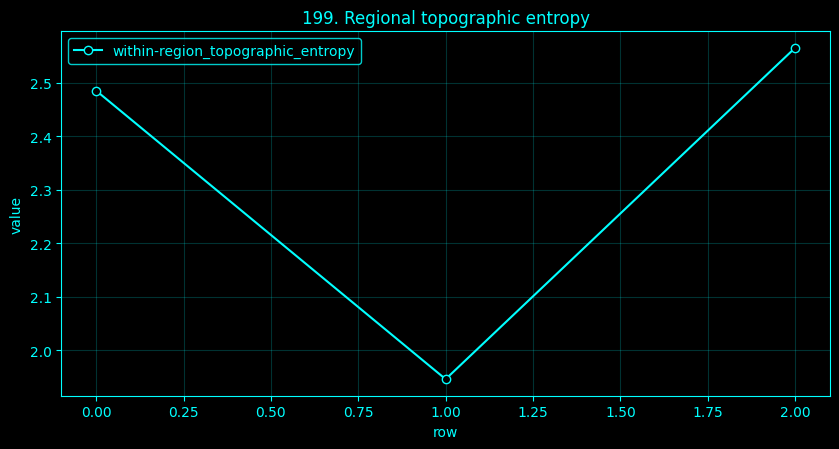

In [175]:
# =======================================================
# 199. Regional topographic entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Within each broad scalp region, channel powers are normalized locally and Shannon
# entropy is computed, giving within-region spatial dispersion rather than a global topographic score.
# =======================================================
def _entropy_method_199():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    rows = []
    for name, ids in _regions_indices().items():
        if ids:
            rows.append([name, _H(_safe_prob(powv[ids]))])
    _ent_display_result = pd.DataFrame(rows, columns=['region', 'within-region_topographic_entropy'])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_199()
_ent_auto_plot(199, 'Regional topographic entropy', _ent_method_ns, ['X', 'y', 'powv', 'rows', '_ent_display_result', 'G', 'W', 'A', 'name', 'ids'])


### 200. Time-resolved topographic entropy

Windowed channel powers $P_i(t)$ define $p_i(t)=P_i(t)/\sum_jP_j(t)$. The trajectory $H(t)=-\sum_ip_i(t)\ln p_i(t)$ tracks time-varying spatial dispersion.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


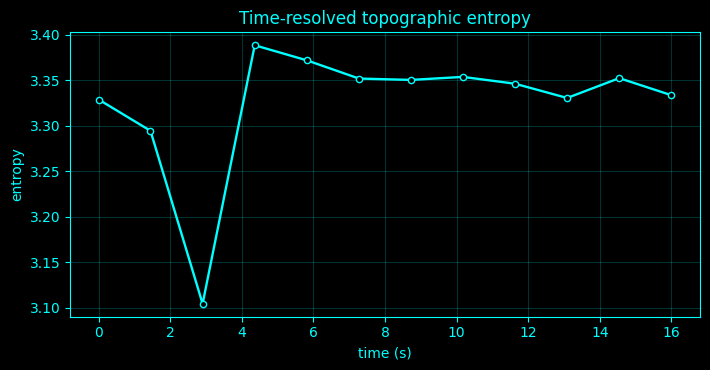

In [176]:
# =======================================================
# 200. Time-resolved topographic entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Windowed channel powers $P_i(t)$ define $p_i(t)=P_i(t)/\sum_jP_j(t)$. The trajectory
# $H(t)=-\sum_ip_i(t)\ln p_i(t)$ tracks time-varying spatial dispersion.
# =======================================================
def _entropy_method_200():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    Wn = max(100, int(2 * _ent_fs))
    starts = np.linspace(0, max(0, len(X) - Wn), _ENT_SPEED['windows']).astype(int)
    v = []
    for s in starts:
        v.append(_H(_safe_prob(np.var(X[s:s + Wn], axis=0))))
    _line(starts / _ent_fs, v, 'Time-resolved topographic entropy', 'time (s)', 'entropy')
    return locals()
_ent_method_ns = _entropy_method_200()


### 201. Microstate entropy

EEG microstates are polarity-invariant clusters of normalized scalp maps. If $p_k$ is the temporal occupancy of microstate $k$, microstate entropy is $H=-\sum_kp_k\ln p_k$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


microstate occupancy entropy= 1.3474887432669131


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


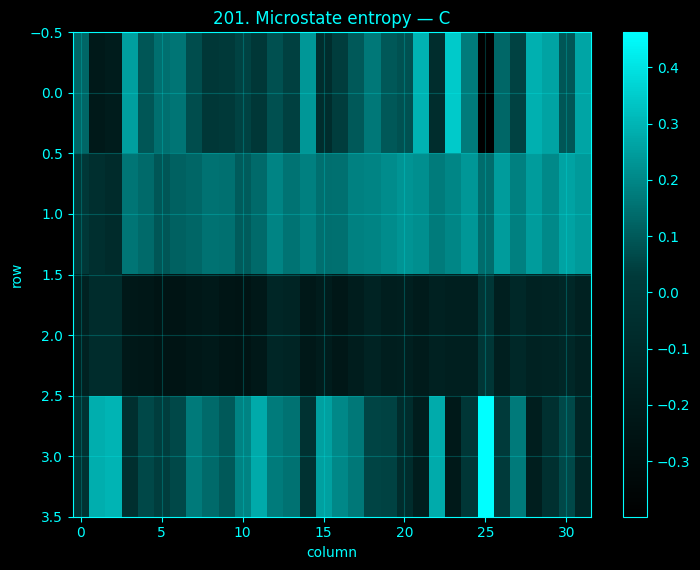

In [177]:
# =======================================================
# 201. Microstate entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: EEG microstates are polarity-invariant clusters of normalized scalp maps. If $p_k$ is
# the temporal occupancy of microstate $k$, microstate entropy is $H=-\sum_kp_k\ln p_k$.
# =======================================================
def _entropy_method_201():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    lab, C = _microstates(4)
    states, runs = _run_lengths(lab)
    _ent_print_args = ['microstate occupancy entropy=', _H(_p_from_labels(lab))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_201()
_ent_auto_plot(201, 'Microstate entropy', _ent_method_ns, ['X', 'y', 'powv', '_ent_print_args', 'G', 'W', 'A', 'lab', 'C', 'states', 'runs'])


### 202. Microstate transition entropy

Transition entropy here is the joint Shannon entropy $H(S_t,S_{t+1})$ of consecutive microstate labels. Method 205 separately reports the conditional entropy rate $H(S_{t+1}|S_t)$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


microstate transition-pair entropy= 2.6103809860873


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


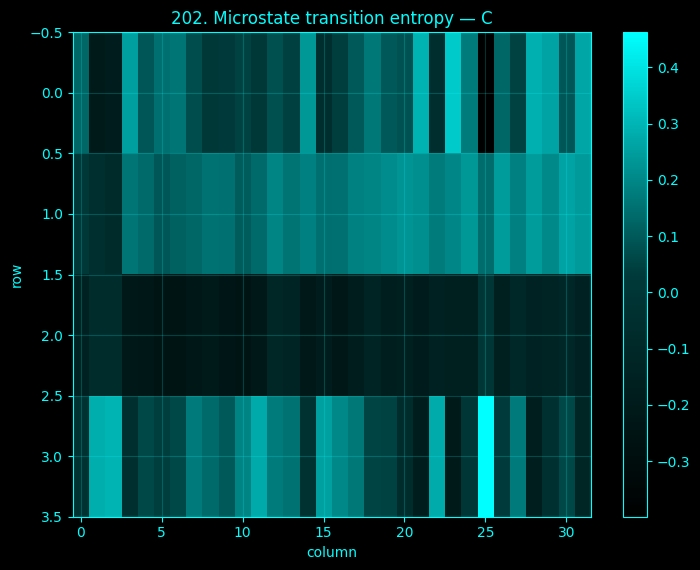

In [178]:
# =======================================================
# 202. Microstate transition entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Transition entropy here is the joint Shannon entropy $H(S_t,S_{t+1})$ of consecutive
# microstate labels. Method 205 separately reports the conditional entropy rate $H(S_{t+1}|S_t)$.
# =======================================================
def _entropy_method_202():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    lab, C = _microstates(4)
    states, runs = _run_lengths(lab)
    pairs = np.column_stack([lab[:-1], lab[1:]]) if len(lab) > 1 else np.empty((0, 2), int)
    _ent_print_args = ['microstate transition-pair entropy=', _H(_p_from_labels(pairs)) if len(pairs) else 0.0]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_202()
_ent_auto_plot(202, 'Microstate transition entropy', _ent_method_ns, ['X', 'y', 'powv', 'pairs', '_ent_print_args', 'G', 'W', 'A', 'lab', 'C', 'states', 'runs'])


### 203. Microstate duration entropy

Consecutive identical labels define dwell lengths $L$. Microstate duration entropy is Shannon entropy of the empirical run-length distribution $p(L)$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


microstate duration entropy= 0.6473706730717066 mean duration samples= 1.3873355263157894


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


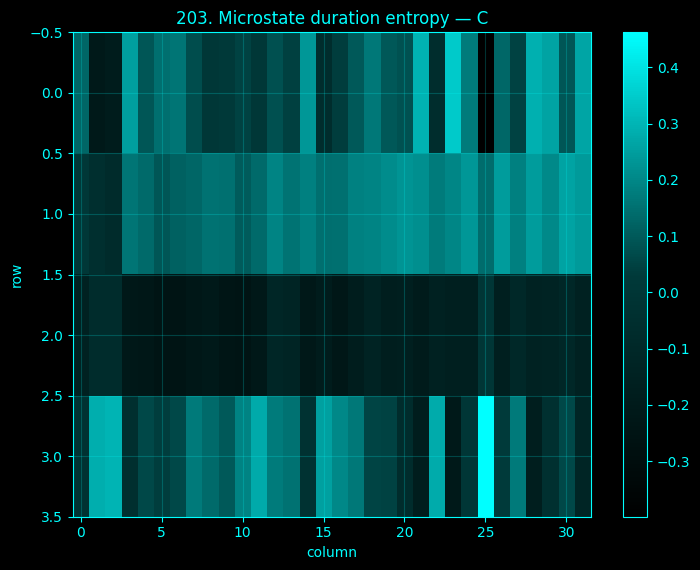

In [179]:
# =======================================================
# 203. Microstate duration entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Consecutive identical labels define dwell lengths $L$. Microstate duration entropy is
# Shannon entropy of the empirical run-length distribution $p(L)$.
# =======================================================
def _entropy_method_203():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    lab, C = _microstates(4)
    states, runs = _run_lengths(lab)
    pairs = np.column_stack([lab[:-1], lab[1:]]) if len(lab) > 1 else np.empty((0, 2), int)
    _ent_print_args = ['microstate duration entropy=', _H(_p_from_labels(runs)) if len(runs) else 0.0, 'mean duration samples=', float(np.mean(runs)) if len(runs) else np.nan]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_203()
_ent_auto_plot(203, 'Microstate duration entropy', _ent_method_ns, ['X', 'y', 'powv', 'pairs', '_ent_print_args', 'G', 'W', 'A', 'lab', 'C', 'states', 'runs'])


### 204. Microstate syntax entropy

Microstate syntax removes self-transitions and treats ordered state changes $(S_t,S_{t+1})$ as symbols. Syntax entropy is Shannon entropy of those change-transition symbols.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


microstate syntax entropy (state changes only)= 2.375094002652313


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


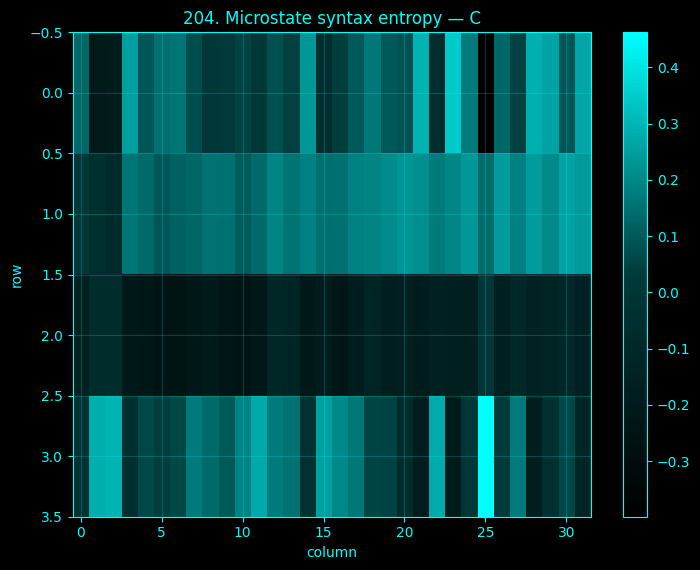

In [180]:
# =======================================================
# 204. Microstate syntax entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Microstate syntax removes self-transitions and treats ordered state changes
# $(S_t,S_{t+1})$ as symbols. Syntax entropy is Shannon entropy of those change-transition symbols.
# =======================================================
def _entropy_method_204():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    lab, C = _microstates(4)
    states, runs = _run_lengths(lab)
    pairs = np.column_stack([lab[:-1], lab[1:]]) if len(lab) > 1 else np.empty((0, 2), int)
    q = pairs[pairs[:, 0] != pairs[:, 1]] if len(pairs) else pairs
    _ent_print_args = ['microstate syntax entropy (state changes only)=', _H(_p_from_labels(q)) if len(q) else 0.0]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_204()
_ent_auto_plot(204, 'Microstate syntax entropy', _ent_method_ns, ['X', 'y', 'powv', 'pairs', 'q', '_ent_print_args', 'G', 'W', 'A', 'lab', 'C', 'states', 'runs'])


### 205. Microstate sequence entropy rate

Under a first-order Markov description, the microstate sequence entropy rate is $H(S_{t+1}|S_t)=H(S_t,S_{t+1})-H(S_t)$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


microstate sequence entropy rate H(S_t+1|S_t)= 1.263128092982849


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


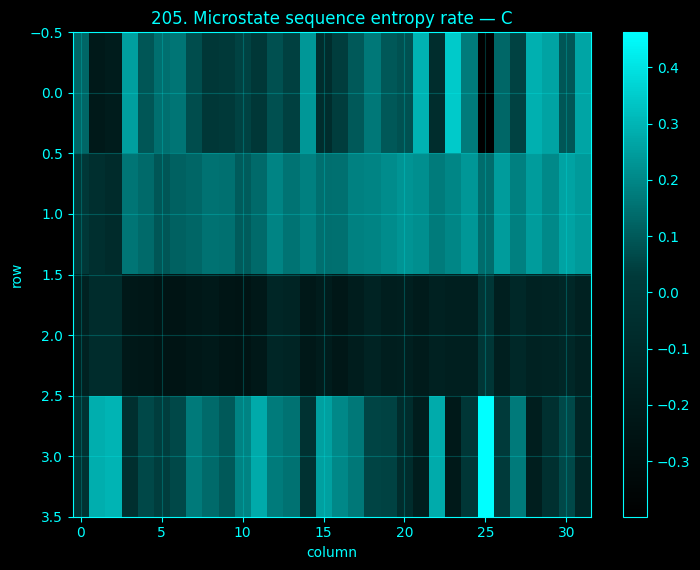

In [181]:
# =======================================================
# 205. Microstate sequence entropy rate
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Under a first-order Markov description, the microstate sequence entropy rate is
# $H(S_{t+1}|S_t)=H(S_t,S_{t+1})-H(S_t)$.
# =======================================================
def _entropy_method_205():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    lab, C = _microstates(4)
    states, runs = _run_lengths(lab)
    pairs = np.column_stack([lab[:-1], lab[1:]]) if len(lab) > 1 else np.empty((0, 2), int)
    hxy = _H(_p_from_labels(pairs)) if len(pairs) else 0
    hx = _H(_p_from_labels(lab[:-1])) if len(lab) > 1 else 0
    _ent_print_args = ['microstate sequence entropy rate H(S_t+1|S_t)=', hxy - hx]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_205()
_ent_auto_plot(205, 'Microstate sequence entropy rate', _ent_method_ns, ['X', 'y', 'powv', 'pairs', 'hxy', 'hx', '_ent_print_args', 'G', 'W', 'A', 'lab', 'C', 'states', 'runs'])


### 206. Recurrence plot entropy

For recurrence matrix $R_{ij}=1[\|X_i-X_j\|\le\varepsilon]$, the recurrence rate is $r=\langle R\rangle$. This cell uses the binary recurrence-plot entropy $-r\ln r-(1-r)\ln(1-r)$; line-structure entropies are handled separately.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Recurrence analysis compares pairs of reconstructed states and marks them as recurrent when their distance is below a chosen threshold. The recurrence rate is simply the fraction of state pairs that satisfy this condition. Diagonal line structures indicate that similar state sequences evolve in similar ways for several steps, which motivates determinism-related measures. Vertical line structures indicate that the trajectory stays near a region of state space for several samples, which motivates laminarity-related measures. These quantities depend on embedding choices, distance scaling, and the recurrence threshold, so those settings should be held consistent when channels are compared.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


recurrence-plot binary entropy= 0.19817469329047604 recurrence rate= 0.04988438909365628


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


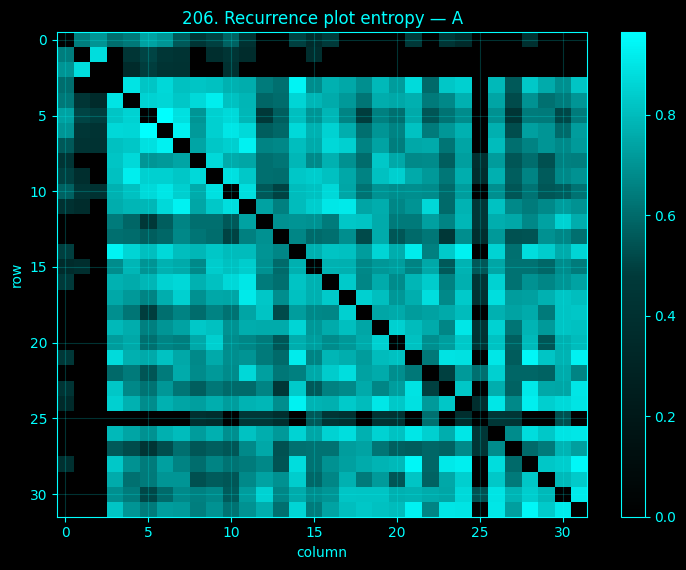

In [182]:
# =======================================================
# 206. Recurrence plot entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For recurrence matrix $R_{ij}=1[\|X_i-X_j\|\le\varepsilon]$, the recurrence rate is
# $r=\langle R\rangle$. This cell uses the binary recurrence-plot entropy $-r\ln r-(1-r)\ln(1-r)$;
# line-structure entropies are handled separately.
# =======================================================
def _entropy_method_206():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    R = _recurrence()
    rr = float(np.mean(R)) if R.size else 0
    _ent_print_args = ['recurrence-plot binary entropy=', _H(np.array([rr, 1 - rr])), 'recurrence rate=', rr]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_206()
_ent_auto_plot(206, 'Recurrence plot entropy', _ent_method_ns, ['X', 'y', 'powv', 'R', 'rr', '_ent_print_args', 'G', 'W', 'A'])


### 207. Diagonal-line entropy

Diagonal recurrence lines have lengths $\ell\ge2$. Diagonal-line entropy is $-\sum_\ell p(\ell)\ln p(\ell)$ and measures diversity of deterministic recurrence durations.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


diagonal-line entropy= 1.3250684201938139 lines= 2106


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


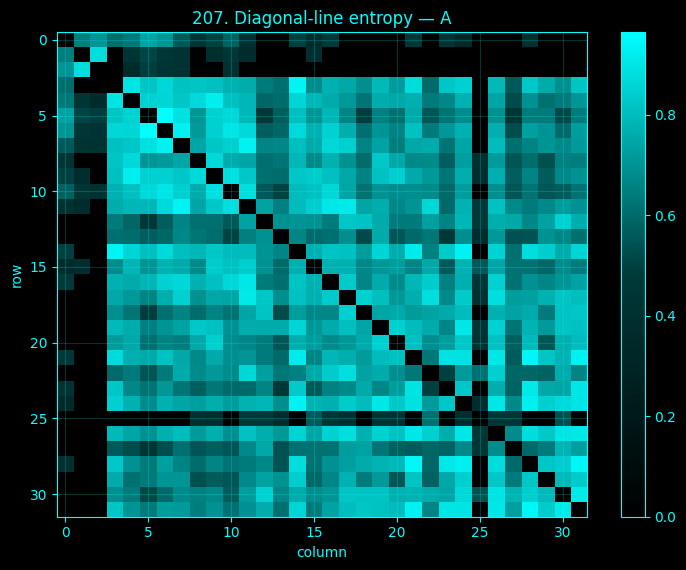

In [183]:
# =======================================================
# 207. Diagonal-line entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Diagonal recurrence lines have lengths $\ell\ge2$. Diagonal-line entropy is $-\sum_\ell
# p(\ell)\ln p(\ell)$ and measures diversity of deterministic recurrence durations.
# =======================================================
def _entropy_method_207():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    R = _recurrence()
    rr = float(np.mean(R)) if R.size else 0
    L = _diag_lengths(R)
    _ent_print_args = ['diagonal-line entropy=', _H(_p_from_labels(L)) if len(L) else 0.0, 'lines=', len(L)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_207()
_ent_auto_plot(207, 'Diagonal-line entropy', _ent_method_ns, ['X', 'y', 'powv', 'R', 'rr', 'L', '_ent_print_args', 'G', 'W', 'A'])


### 208. Vertical-line entropy

Vertical recurrence-line lengths quantify laminar persistence. Their empirical length distribution $p(v)$ gives vertical-line entropy $-\sum_vp(v)\ln p(v)$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


vertical-line entropy= 1.1602019616080315


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


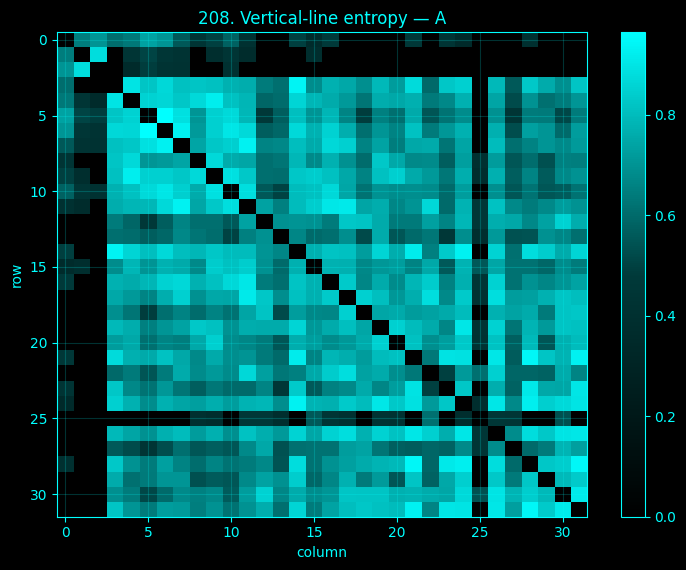

In [184]:
# =======================================================
# 208. Vertical-line entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Vertical recurrence-line lengths quantify laminar persistence. Their empirical length
# distribution $p(v)$ gives vertical-line entropy $-\sum_vp(v)\ln p(v)$.
# =======================================================
def _entropy_method_208():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    R = _recurrence()
    rr = float(np.mean(R)) if R.size else 0
    L = _vert_lengths(R, True)
    _ent_print_args = ['vertical-line entropy=', _H(_p_from_labels(L)) if len(L) else 0.0]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_208()
_ent_auto_plot(208, 'Vertical-line entropy', _ent_method_ns, ['X', 'y', 'powv', 'R', 'rr', 'L', '_ent_print_args', 'G', 'W', 'A'])


### 209. White-vertical-line entropy

White vertical lines are consecutive non-recurrence gaps in recurrence-matrix columns. Their length entropy describes diversity of recurrence times between visits.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


white-vertical-line entropy= 3.6352533821966584


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


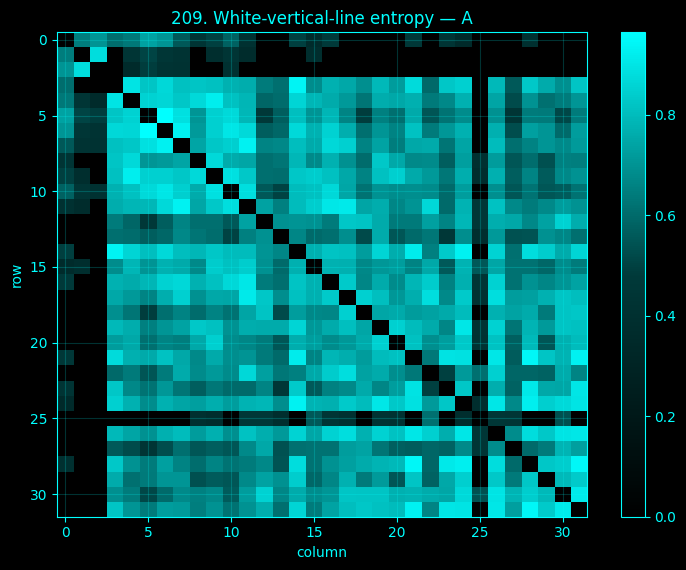

In [185]:
# =======================================================
# 209. White-vertical-line entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: White vertical lines are consecutive non-recurrence gaps in recurrence-matrix columns.
# Their length entropy describes diversity of recurrence times between visits.
# =======================================================
def _entropy_method_209():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    R = _recurrence()
    rr = float(np.mean(R)) if R.size else 0
    L = _vert_lengths(R, False)
    _ent_print_args = ['white-vertical-line entropy=', _H(_p_from_labels(L)) if len(L) else 0.0]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_209()
_ent_auto_plot(209, 'White-vertical-line entropy', _ent_method_ns, ['X', 'y', 'powv', 'R', 'rr', 'L', '_ent_print_args', 'G', 'W', 'A'])


### 210. Recurrence network entropy

Treating the recurrence matrix as an unweighted graph, recurrence-network entropy is Shannon entropy of its degree distribution.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


recurrence-network degree entropy= 3.747010661312128


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


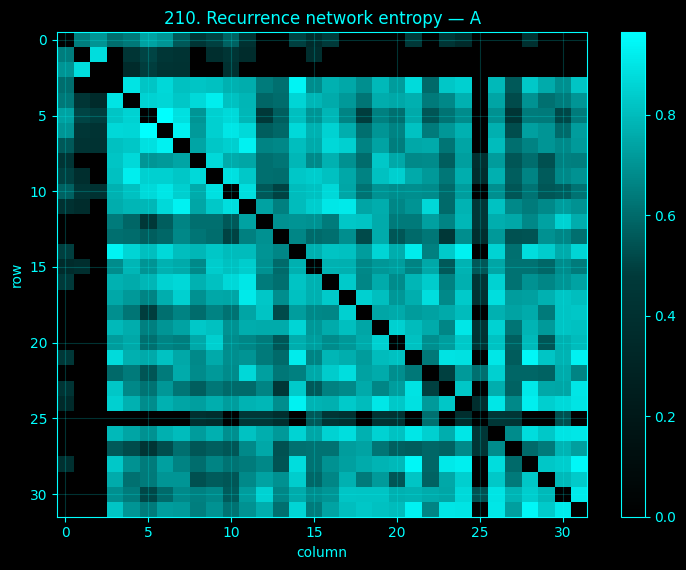

In [186]:
# =======================================================
# 210. Recurrence network entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Treating the recurrence matrix as an unweighted graph, recurrence-network entropy is
# Shannon entropy of its degree distribution.
# =======================================================
def _entropy_method_210():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    R = _recurrence()
    rr = float(np.mean(R)) if R.size else 0
    GR = nx.from_numpy_array(R.astype(int))
    _ent_print_args = ['recurrence-network degree entropy=', _degree_distribution_entropy(GR)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_210()
_ent_auto_plot(210, 'Recurrence network entropy', _ent_method_ns, ['X', 'y', 'powv', 'R', 'rr', 'GR', '_ent_print_args', 'G', 'W', 'A'])


### 211. Recurrence state-transition entropy

Row recurrence counts are quantized into occupancy states. Entropy of consecutive state pairs measures diversity of recurrence-state transitions.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


recurrence state-transition entropy= 2.560580176514725


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


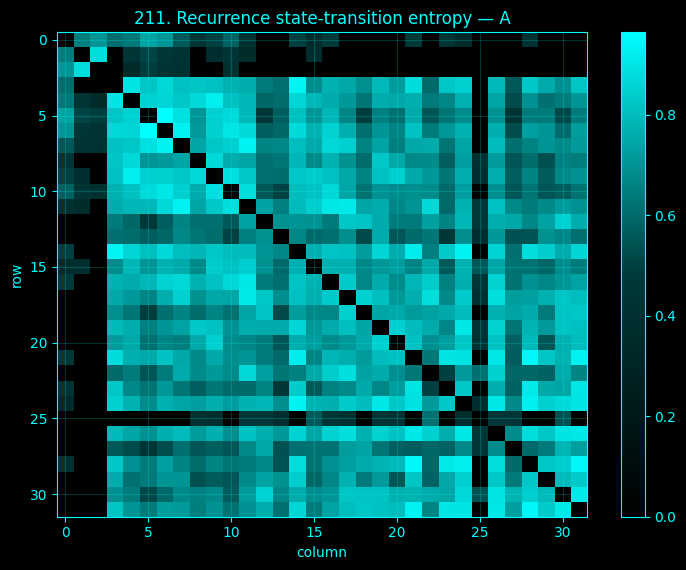

In [187]:
# =======================================================
# 211. Recurrence state-transition entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Row recurrence counts are quantized into occupancy states. Entropy of consecutive state
# pairs measures diversity of recurrence-state transitions.
# =======================================================
def _entropy_method_211():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    R = _recurrence()
    rr = float(np.mean(R)) if R.size else 0
    deg = R.sum(1)
    q = np.digitize(deg, np.quantile(deg, [0.25, 0.5, 0.75]))
    pairs = np.column_stack([q[:-1], q[1:]])
    _ent_print_args = ['recurrence state-transition entropy=', _H(_p_from_labels(pairs))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_211()
_ent_auto_plot(211, 'Recurrence state-transition entropy', _ent_method_ns, ['X', 'y', 'powv', 'R', 'rr', 'deg', 'q', 'pairs', '_ent_print_args', 'G', 'W', 'A'])


### 212. Recurrence motif entropy

Three recurrence-network vertices are sampled and classified by the number of induced edges (0–3). Motif entropy is Shannon entropy of this induced 3-node edge-count distribution.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


recurrence 3-node motif edge-count entropy= 0.4427503929089874


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


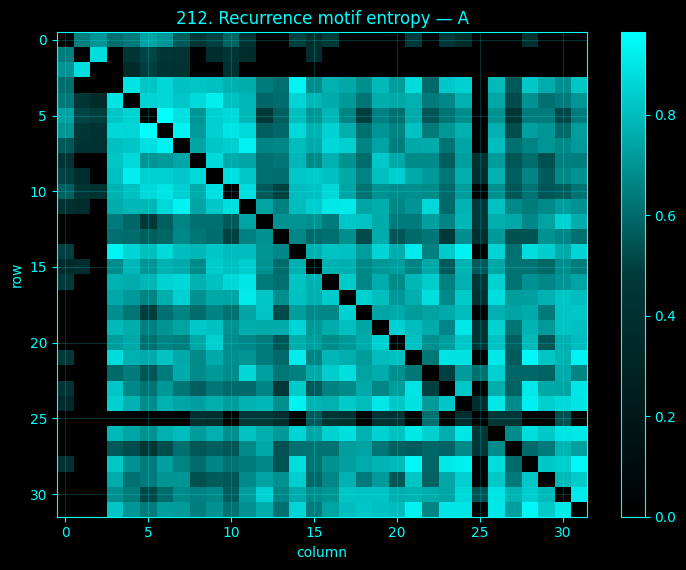

In [188]:
# =======================================================
# 212. Recurrence motif entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Three recurrence-network vertices are sampled and classified by the number of induced
# edges (0–3). Motif entropy is Shannon entropy of this induced 3-node edge-count distribution.
# =======================================================
def _entropy_method_212():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    R = _recurrence()
    rr = float(np.mean(R)) if R.size else 0
    rng = np.random.default_rng(212)
    n = len(R)
    m = min(3000, max(1, n * (n - 1) * (n - 2) // 6))
    counts = []
    for _ in range(m):
        tri = rng.choice(n, 3, replace=False)
        counts.append(int(np.sum(R[np.ix_(tri, tri)]) / 2))
    _ent_print_args = ['recurrence 3-node motif edge-count entropy=', _H(_p_from_labels(counts))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_212()
_ent_auto_plot(212, 'Recurrence motif entropy', _ent_method_ns, ['X', 'y', 'powv', 'R', 'rr', 'rng', 'n', 'm', 'counts', '_', '_ent_print_args', 'G', 'W', 'A', 'tri'])


### 213. Multiscale recurrence entropy

The signal is coarse-grained across scales and a recurrence matrix is rebuilt at each scale. Binary recurrence entropy is then tracked versus scale.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


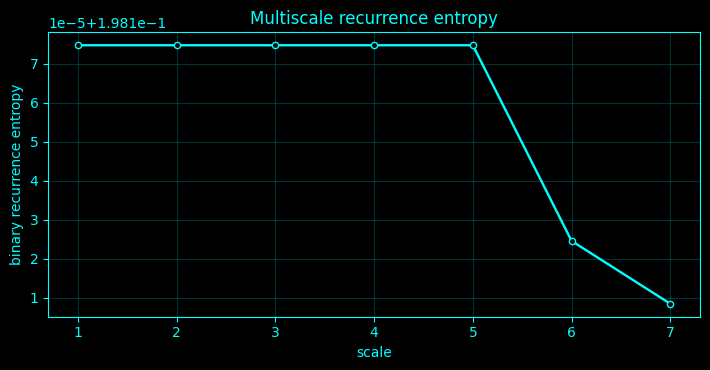

In [189]:
# =======================================================
# 213. Multiscale recurrence entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: The signal is coarse-grained across scales and a recurrence matrix is rebuilt at each
# scale. Binary recurrence entropy is then tracked versus scale.
# =======================================================
def _entropy_method_213():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    R = _recurrence()
    rr = float(np.mean(R)) if R.size else 0
    sc = np.arange(1, _ENT_SPEED['scales'] + 1)
    v = []
    for s in sc:
        RR = _recurrence(_coarse(y, int(s)))
        r = float(np.mean(RR)) if RR.size else 0
        v.append(_H(np.array([r, 1 - r])))
    _line(sc, v, 'Multiscale recurrence entropy', 'scale', 'binary recurrence entropy')
    return locals()
_ent_method_ns = _entropy_method_213()


### 214. Phase entropy

Analytic phase $\phi(t)=\arg\mathcal H[x](t)$ is histogrammed on $[-\pi,\pi)$. Phase entropy is Shannon entropy of the circular-bin probabilities.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


phase entropy= 3.1291272109851826


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


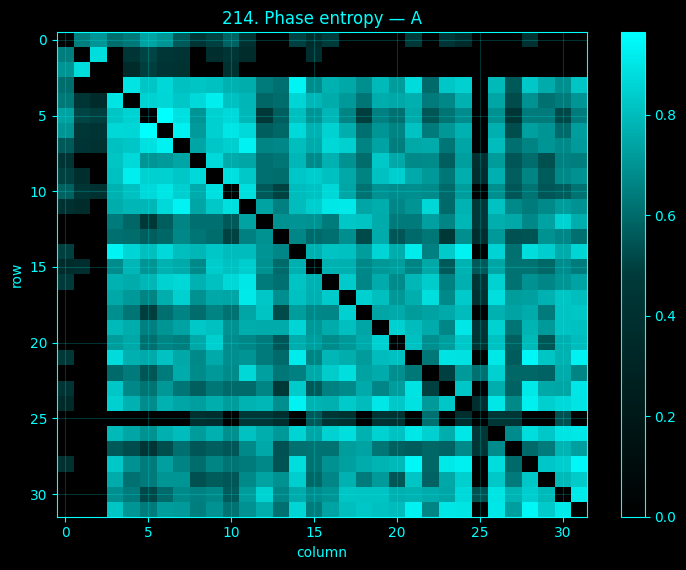

In [190]:
# =======================================================
# 214. Phase entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Analytic phase $\phi(t)=\arg\mathcal H[x](t)$ is histogrammed on $[-\pi,\pi)$. Phase
# entropy is Shannon entropy of the circular-bin probabilities.
# =======================================================
def _entropy_method_214():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    _ent_print_args = ['phase entropy=', _H(_hist_p(_phase(y), 24))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_214()
_ent_auto_plot(214, 'Phase entropy', _ent_method_ns, ['X', 'y', 'powv', '_ent_print_args', 'G', 'W', 'A'])


### 215. Circular Shannon entropy

For a circular phase density $f(\phi)$, differential circular entropy is $h=-\int_{-\pi}^{\pi}f(\phi)\ln f(\phi)\,d\phi$, with maximum $\ln(2\pi)$ for the uniform distribution. A histogram density estimator is used.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


circular differential Shannon entropy= 1.7890477281655106 maximum ln(2pi)= 1.8378770664093453


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


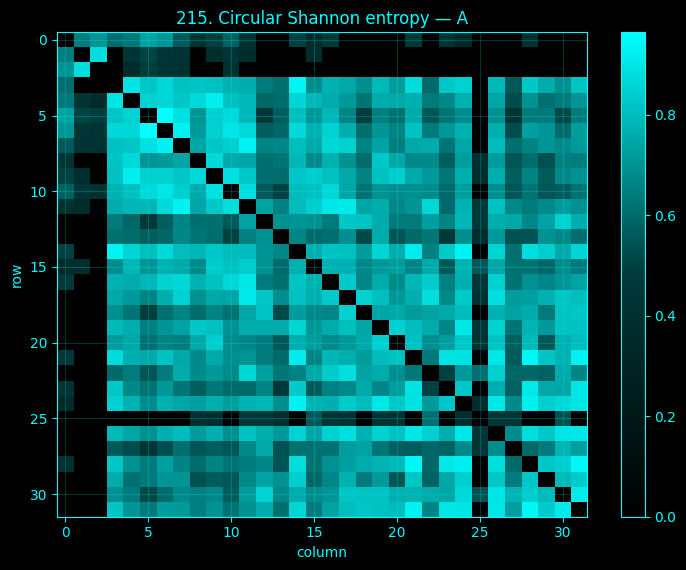

In [191]:
# =======================================================
# 215. Circular Shannon entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For a circular phase density $f(\phi)$, differential circular entropy is
# $h=-\int_{-\pi}^{\pi}f(\phi)\ln f(\phi)\,d\phi$, with maximum $\ln(2\pi)$ for the uniform
# distribution. A histogram density estimator is used.
# =======================================================
def _entropy_method_215():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    ph = _phase(y)
    h, e = np.histogram(ph, bins=24, range=(-np.pi, np.pi), density=True)
    w = e[1] - e[0]
    p = h * w
    p = p[p > 0]
    _ent_print_args = ['circular differential Shannon entropy=', float(-np.sum(p * np.log(h[h > 0] + ENT_EPS))), 'maximum ln(2pi)=', np.log(2 * np.pi)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_215()
_ent_auto_plot(215, 'Circular Shannon entropy', _ent_method_ns, ['X', 'y', 'powv', 'ph', 'w', 'p', '_ent_print_args', 'G', 'W', 'A', 'h', 'e'])


### 216. Phase-locking entropy

For each channel pair, phase-locking value is $\mathrm{PLV}_{ij}=|\langle e^{i(\phi_i-\phi_j)}\rangle|$. The PLV magnitudes are normalized across edges and Shannon entropy measures how distributed phase locking is over the network.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


phase-locking edge entropy= 3.2276632538166856


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


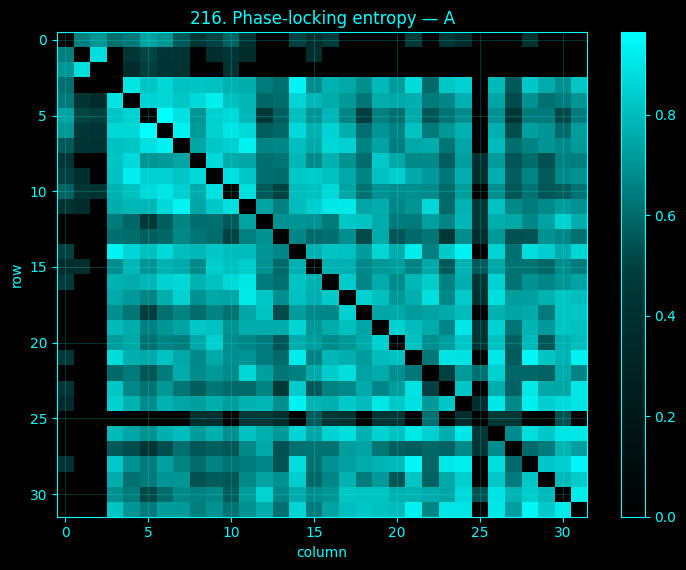

In [192]:
# =======================================================
# 216. Phase-locking entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For each channel pair, phase-locking value is $\mathrm{PLV}_{ij}=|\langle
# e^{i(\phi_i-\phi_j)}\rangle|$. The PLV magnitudes are normalized across edges and Shannon entropy
# measures how distributed phase locking is over the network.
# =======================================================
def _entropy_method_216():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    ph = np.column_stack([_phase(X[:, j]) for j in range(min(8, X.shape[1]))])
    vals = [_plv(ph[:, a], ph[:, b]) for a, b in itertools.combinations(range(ph.shape[1]), 2)]
    _ent_print_args = ['phase-locking edge entropy=', _H(_safe_prob(vals))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_216()
_ent_auto_plot(216, 'Phase-locking entropy', _ent_method_ns, ['X', 'y', 'powv', 'ph', 'vals', '_ent_print_args', 'G', 'W', 'A', 'j', 'a', 'b'])


### 217. Phase-difference entropy

Wrapped phase difference $\Delta\phi=\arg e^{i(\phi_1-\phi_2)}$ is histogrammed circularly. Its Shannon entropy is low for a concentrated preferred phase offset and high for dispersed phase differences.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


phase-difference entropy= 2.92846940027402


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


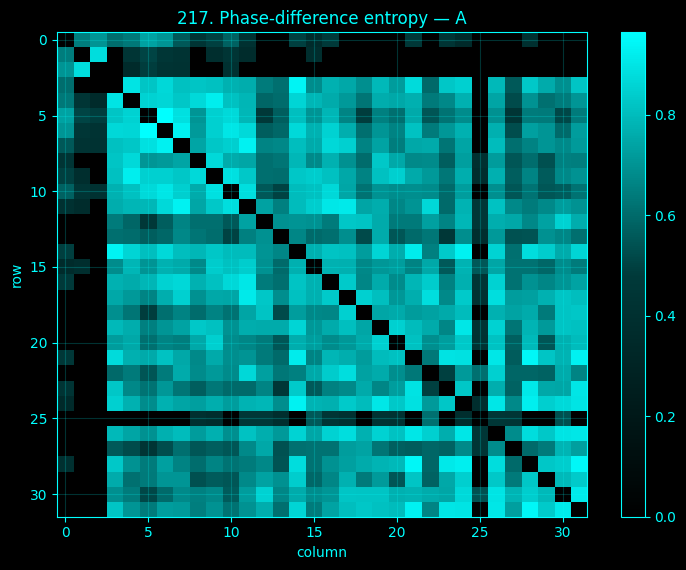

In [193]:
# =======================================================
# 217. Phase-difference entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Wrapped phase difference $\Delta\phi=\arg e^{i(\phi_1-\phi_2)}$ is histogrammed
# circularly. Its Shannon entropy is low for a concentrated preferred phase offset and high for
# dispersed phase differences.
# =======================================================
def _entropy_method_217():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    d = np.angle(np.exp(1j * (_phase(X[:, 0]) - _phase(X[:, 1]))))
    _ent_print_args = ['phase-difference entropy=', _H(_hist_p(d, 24))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_217()
_ent_auto_plot(217, 'Phase-difference entropy', _ent_method_ns, ['X', 'y', 'powv', 'd', '_ent_print_args', 'G', 'W', 'A'])


### 218. Kuramoto order-parameter entropy

The Kuramoto order parameter is $R(t)=|N^{-1}\sum_je^{i\phi_j(t)}|\in[0,1]$. Its empirical-value entropy measures variability of global synchrony strength.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-oscillator and circle-map models describe how a phase variable advances under its own natural rotation plus periodic forcing or coupling. Mode locking occurs when the average phase advance becomes a rational multiple of the forcing cycle. Arnold tongues are parameter regions where a particular locking ratio remains stable. These models are useful simplified descriptions of synchronization structure, but their parameters are effective model quantities rather than direct physiological measurements unless independently calibrated.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Kuramoto order-parameter entropy= 2.915251598191528


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


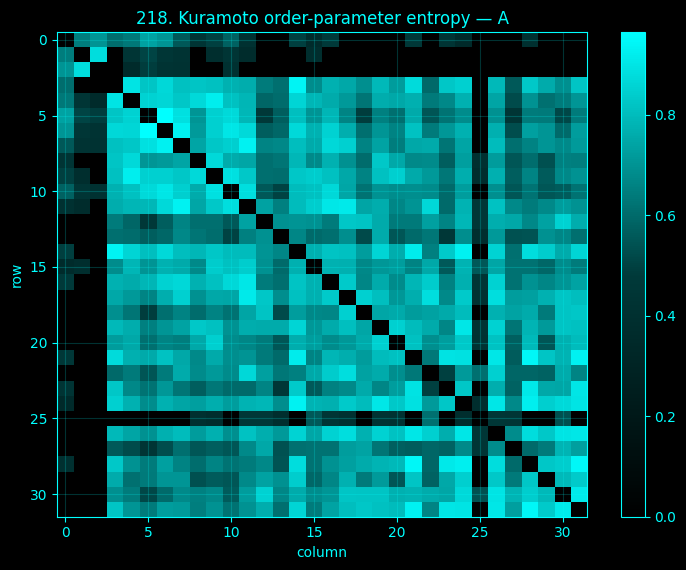

In [194]:
# =======================================================
# 218. Kuramoto order-parameter entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: The Kuramoto order parameter is $R(t)=|N^{-1}\sum_je^{i\phi_j(t)}|\in[0,1]$. Its
# empirical-value entropy measures variability of global synchrony strength.
# =======================================================
def _entropy_method_218():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    ph = np.column_stack([_phase(X[:, j]) for j in range(min(8, X.shape[1]))])
    R = np.abs(np.mean(np.exp(1j * ph), axis=1))
    _ent_print_args = ['Kuramoto order-parameter entropy=', _H(_hist_p(R, 24))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_218()
_ent_auto_plot(218, 'Kuramoto order-parameter entropy', _ent_method_ns, ['X', 'y', 'powv', 'ph', 'R', '_ent_print_args', 'G', 'W', 'A', 'j'])


### 219. Inter-channel phase entropy

For every channel pair, Shannon entropy of the wrapped phase-difference distribution is computed. The reported statistic is the mean inter-channel phase-difference entropy.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


mean inter-channel phase-difference entropy= 2.7247870968208074


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


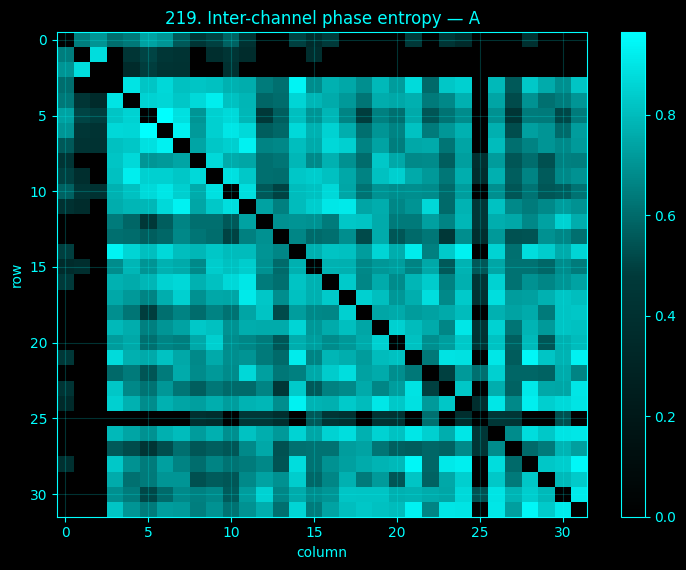

In [195]:
# =======================================================
# 219. Inter-channel phase entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For every channel pair, Shannon entropy of the wrapped phase-difference distribution is
# computed. The reported statistic is the mean inter-channel phase-difference entropy.
# =======================================================
def _entropy_method_219():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    ph = np.column_stack([_phase(X[:, j]) for j in range(min(8, X.shape[1]))])
    vals = []
    for a, b in itertools.combinations(range(ph.shape[1]), 2):
        vals.append(_H(_hist_p(np.angle(np.exp(1j * (ph[:, a] - ph[:, b]))), 24)))
    _ent_print_args = ['mean inter-channel phase-difference entropy=', float(np.mean(vals))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_219()
_ent_auto_plot(219, 'Inter-channel phase entropy', _ent_method_ns, ['X', 'y', 'powv', 'ph', 'vals', '_ent_print_args', 'G', 'W', 'A', 'a', 'b', 'j'])


### 220. Phase-amplitude coupling entropy

Phase–amplitude coupling forms phase-bin amplitude masses $p_k=\bar A_k/\sum_j\bar A_j$. This cell reports $H=-\sum_kp_k\ln p_k$; Tort modulation index is equivalently $(\ln K-H)/\ln K$.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


phase-amplitude coupling phase-bin entropy= 2.8897181086093777 normalized= 0.9997738528668497


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


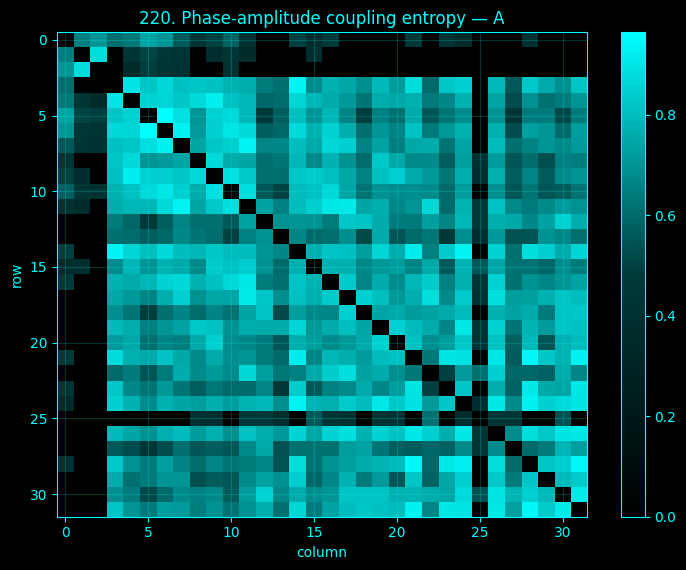

In [196]:
# =======================================================
# 220. Phase-amplitude coupling entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Phase–amplitude coupling forms phase-bin amplitude masses $p_k=\bar A_k/\sum_j\bar
# A_j$. This cell reports $H=-\sum_kp_k\ln p_k$; Tort modulation index is equivalently $(\ln K-H)/\ln
# K$.
# =======================================================
def _entropy_method_220():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    p = _pac_distribution(y)
    _ent_print_args = ['phase-amplitude coupling phase-bin entropy=', _H(p), 'normalized=', _H(p) / np.log(len(p))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_220()
_ent_auto_plot(220, 'Phase-amplitude coupling entropy', _ent_method_ns, ['X', 'y', 'powv', 'p', '_ent_print_args', 'G', 'W', 'A'])


### 221. Cross-frequency coupling entropy

PAC strength is computed over several phase-band/amplitude-band pairs. The resulting nonnegative CFC weights are normalized and their Shannon entropy measures whether coupling is concentrated in a few cross-frequency pairs.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


cross-frequency coupling weight entropy 1.5560039924910127


,0,1
0,0.002259,0.001929
1,0.000587,0.001258
2,0.000187,0.000581


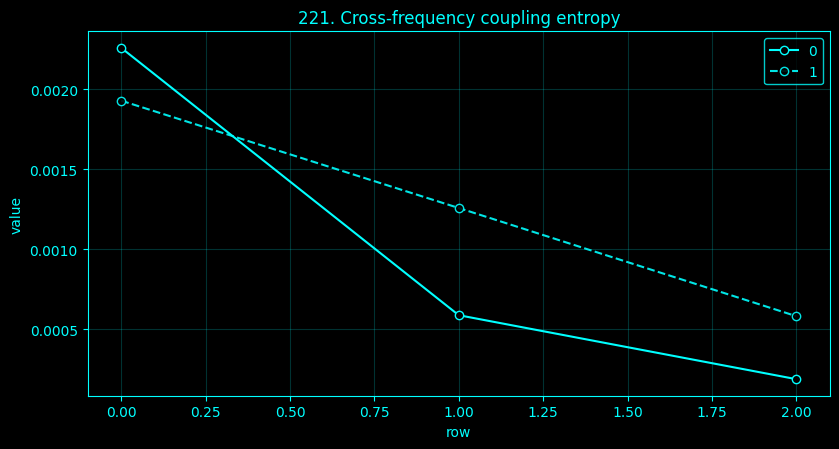

In [197]:
# =======================================================
# 221. Cross-frequency coupling entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: PAC strength is computed over several phase-band/amplitude-band pairs. The resulting
# nonnegative CFC weights are normalized and their Shannon entropy measures whether coupling is
# concentrated in a few cross-frequency pairs.
# =======================================================
def _entropy_method_221():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    phasebands = [(2, 4), (4, 8), (8, 12)]
    ampbands = [(15, 25), (25, min(40, 0.45 * _ent_fs))]
    M = np.zeros((len(phasebands), len(ampbands)))
    for a, (pl, ph) in enumerate(phasebands):
        for b, (al, ah) in enumerate(ampbands):
            if ah > al and ph < al:
                p = _pac_distribution(y, pl, ph, al, ah)
                M[a, b] = np.log(len(p)) - _H(p)
    h = _H(_safe_prob(M.ravel()))
    _ent_print_args = ['cross-frequency coupling weight entropy', h]
    print(*_ent_print_args)
    _ent_display_result = pd.DataFrame(M)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_221()
_ent_auto_plot(221, 'Cross-frequency coupling entropy', _ent_method_ns, ['X', 'y', 'powv', 'phasebands', 'ampbands', 'M', 'h', '_ent_print_args', '_ent_display_result', 'G', 'W', 'A', 'a', 'pl', 'ph', 'b', 'al', 'ah', 'p'])


### 222. Comodulogram entropy

A comodulogram is the 2-D matrix of PAC strengths across phase and amplitude bands. Comodulogram entropy is Shannon entropy of the normalized matrix entries.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


comodulogram entropy 1.5560039924910127


,0,1
0,0.002259,0.001929
1,0.000587,0.001258
2,0.000187,0.000581


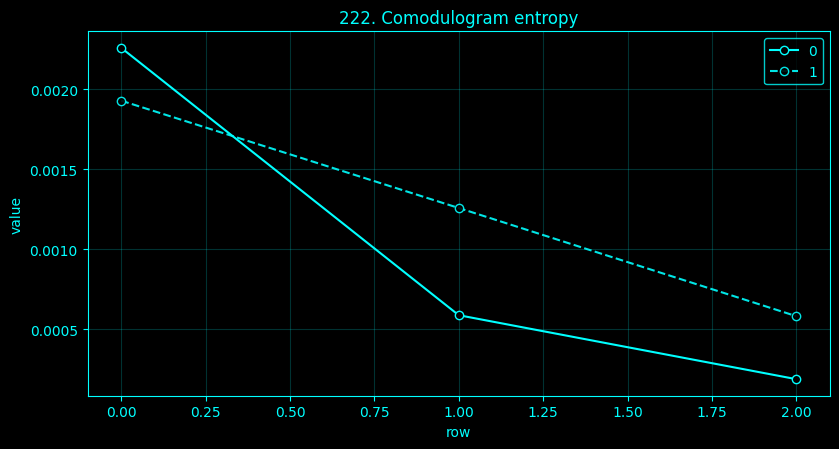

In [198]:
# =======================================================
# 222. Comodulogram entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: A comodulogram is the 2-D matrix of PAC strengths across phase and amplitude bands.
# Comodulogram entropy is Shannon entropy of the normalized matrix entries.
# =======================================================
def _entropy_method_222():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    phasebands = [(2, 4), (4, 8), (8, 12)]
    ampbands = [(15, 25), (25, min(40, 0.45 * _ent_fs))]
    M = np.zeros((len(phasebands), len(ampbands)))
    for a, (pl, ph) in enumerate(phasebands):
        for b, (al, ah) in enumerate(ampbands):
            if ah > al and ph < al:
                p = _pac_distribution(y, pl, ph, al, ah)
                M[a, b] = np.log(len(p)) - _H(p)
    h = _H(_safe_prob(M.ravel()))
    _ent_print_args = ['comodulogram entropy', h]
    print(*_ent_print_args)
    _ent_display_result = pd.DataFrame(M)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_222()
_ent_auto_plot(222, 'Comodulogram entropy', _ent_method_ns, ['X', 'y', 'powv', 'phasebands', 'ampbands', 'M', 'h', '_ent_print_args', '_ent_display_result', 'G', 'W', 'A', 'a', 'pl', 'ph', 'b', 'al', 'ah', 'p'])


### 223. Amplitude-envelope synchrony entropy by channel

For each channel, alpha-envelope correlations with other channels define nonnegative synchrony weights. Their normalized Shannon entropy measures whether envelope synchrony is diffuse or concentrated.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,channel,envelope_synchrony_entropy
0,Fp1,1.864492
1,Fpz,1.893688
2,Fp2,1.885979
3,F7,1.922727
4,F3,1.922819
5,Fz,1.931473
6,F4,1.914818
7,F8,1.898703


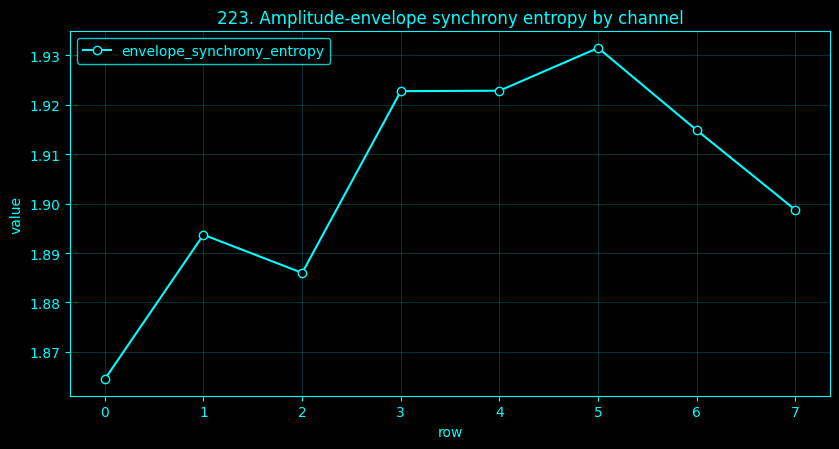

In [199]:
# =======================================================
# 223. Amplitude-envelope synchrony entropy by channel
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For each channel, alpha-envelope correlations with other channels define nonnegative
# synchrony weights. Their normalized Shannon entropy measures whether envelope synchrony is diffuse
# or concentrated.
# =======================================================
def _entropy_method_223():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    env = np.column_stack([np.abs(signal.hilbert(_band(X[:, j], 8, min(13, 0.45 * _ent_fs)))) for j in range(min(8, X.shape[1]))])
    C = np.abs(np.corrcoef(env, rowvar=False))
    np.fill_diagonal(C, 0)
    rows = []
    for j in range(len(C)):
        rows.append([_ent_names[j], _H(_safe_prob(C[j]))])
    _ent_display_result = pd.DataFrame(rows, columns=['channel', 'envelope_synchrony_entropy'])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_223()
_ent_auto_plot(223, 'Amplitude-envelope synchrony entropy by channel', _ent_method_ns, ['X', 'y', 'powv', 'env', 'C', 'rows', 'j', '_ent_display_result', 'G', 'W', 'A'])


### 224. Phase synchrony state entropy

Instantaneous vectors of pairwise phase-synchrony features are clustered into discrete states. Phase-synchrony state entropy is Shannon entropy of the resulting state occupancies.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


phase synchrony state entropy= 1.2546759212083807


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


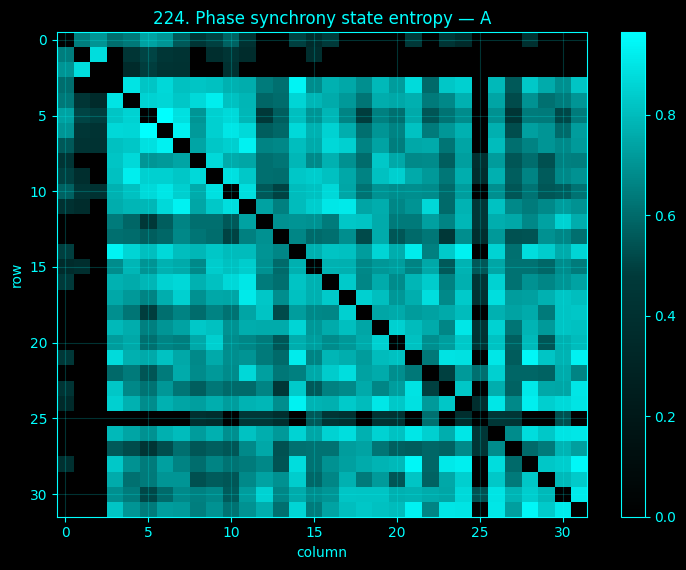

In [200]:
# =======================================================
# 224. Phase synchrony state entropy
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Instantaneous vectors of pairwise phase-synchrony features are clustered into discrete
# states. Phase-synchrony state entropy is Shannon entropy of the resulting state occupancies.
# =======================================================
def _entropy_method_224():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    ph = np.column_stack([_phase(X[:, j]) for j in range(min(6, X.shape[1]))])
    step = max(1, len(ph) // 300)
    ph = ph[::step]
    F = np.column_stack([np.cos(ph[:, a] - ph[:, b]) for a, b in itertools.combinations(range(ph.shape[1]), 2)])
    K = 4
    C = F[np.linspace(0, len(F) - 1, K).astype(int)]
    for _ in range(15):
        D = ((F[:, None, :] - C[None, :, :]) ** 2).sum(2)
        lab = D.argmin(1)
        C = np.array([F[lab == k].mean(0) if np.any(lab == k) else C[k] for k in range(K)])
    _ent_print_args = ['phase synchrony state entropy=', _H(_p_from_labels(lab))]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_224()
_ent_auto_plot(224, 'Phase synchrony state entropy', _ent_method_ns, ['X', 'y', 'powv', 'ph', 'step', 'F', 'K', 'C', '_', '_ent_print_args', 'G', 'W', 'A', 'D', 'lab', 'j', 'a', 'b', 'k'])


### 225. Jensen-Shannon entropy maps

For distributions $P,Q$, Jensen–Shannon divergence is $\mathrm{JSD}(P,Q)=\tfrac12D_{KL}(P\|M)+\tfrac12D_{KL}(Q\|M)$ with $M=(P+Q)/2$. The cell computes a channel-by-channel JSD map on shared amplitude bins.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,Fp1,Fpz,Fp2,F7,F3,Fz,F4,F8
Fp1,0.000000,0.006892,0.034446,0.041604,0.032328,0.024049,0.031808,0.034495
Fpz,0.006892,0.000000,0.029034,0.044537,0.035484,0.022983,0.032114,0.036810
Fp2,0.034446,0.029034,0.000000,0.083534,0.059582,0.054340,0.066880,0.059651
F7,0.041604,0.044537,0.083534,0.000000,0.009030,0.008289,0.004146,0.008793
F3,0.032328,0.035484,0.059582,0.009030,0.000000,0.008310,0.007432,0.001464
Fz,0.024049,0.022983,0.054340,0.008289,0.008310,0.000000,0.002222,0.008160
F4,0.031808,0.032114,0.066880,0.004146,0.007432,0.002222,0.000000,0.007567
F8,0.034495,0.036810,0.059651,0.008793,0.001464,0.008160,0.007567,0.000000


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


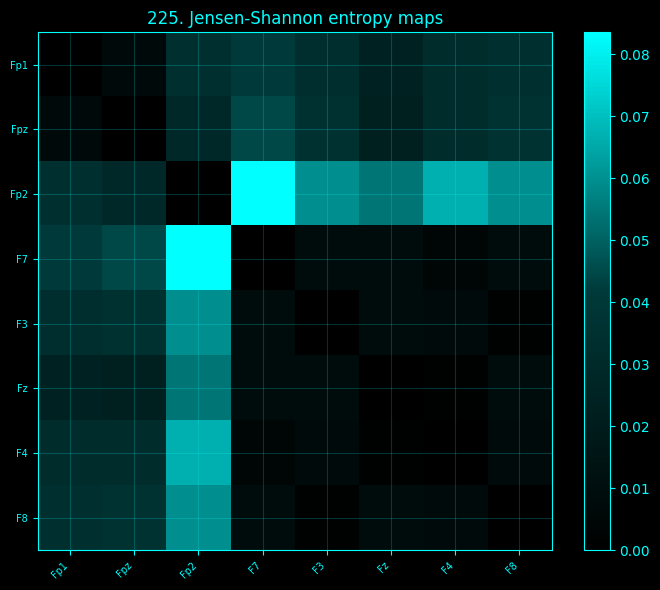

In [201]:
# =======================================================
# 225. Jensen-Shannon entropy maps
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: For distributions $P,Q$, Jensen–Shannon divergence is
# $\mathrm{JSD}(P,Q)=\tfrac12D_{KL}(P\|M)+\tfrac12D_{KL}(Q\|M)$ with $M=(P+Q)/2$. The cell computes a
# channel-by-channel JSD map on shared amplitude bins.
# =======================================================
def _entropy_method_225():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    n = min(8, X.shape[1])
    P = []
    edges = np.linspace(np.min(X[:, :n]), np.max(X[:, :n]), 33)
    for j in range(n):
        P.append(_safe_prob(np.histogram(X[:, j], edges)[0] + 0.5))
    M = np.zeros((n, n))
    for a in range(n):
        for b in range(n):
            M[a, b] = _jsd(P[a], P[b])
    _ent_display_result = pd.DataFrame(M, index=_ent_names[:n], columns=_ent_names[:n])
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_225()
_ent_auto_plot(225, 'Jensen-Shannon entropy maps', _ent_method_ns, ['X', 'y', 'powv', 'n', 'P', 'edges', 'j', 'M', 'a', '_ent_display_result', 'G', 'W', 'A', 'b'])


### 226. Jensen-Shannon divergence between channels

This cell reports the Jensen–Shannon divergence between the first two channel amplitude distributions using common histogram support and a small pseudocount.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Jensen-Shannon divergence ch0,ch1= 0.006891793427773843


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


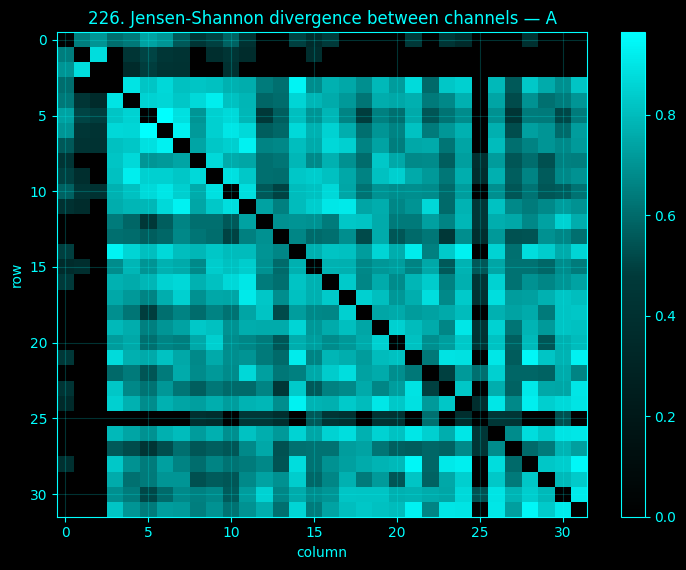

In [202]:
# =======================================================
# 226. Jensen-Shannon divergence between channels
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: This cell reports the Jensen–Shannon divergence between the first two channel amplitude
# distributions using common histogram support and a small pseudocount.
# =======================================================
def _entropy_method_226():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    n = min(8, X.shape[1])
    P = []
    edges = np.linspace(np.min(X[:, :n]), np.max(X[:, :n]), 33)
    for j in range(n):
        P.append(_safe_prob(np.histogram(X[:, j], edges)[0] + 0.5))
    p, q = (P[0], P[1])
    _ent_print_args = ['Jensen-Shannon divergence ch0,ch1=', _jsd(p, q)]
    print(*_ent_print_args)
    return locals()
_ent_method_ns = _entropy_method_226()
_ent_auto_plot(226, 'Jensen-Shannon divergence between channels', _ent_method_ns, ['X', 'y', 'powv', 'n', 'P', 'edges', 'j', '_ent_print_args', 'G', 'W', 'A', 'p', 'q'])


### 227. Jensen-Shannon divergence between regions

Regional mean signals are converted to amplitude distributions on common bins and pairwise Jensen–Shannon divergences are assembled into a regional matrix.

**Implementation.** The existing EEG segment, channel naming, black/cyan plotting style, and the notebook's `full / balanced / fast / ultra` runtime policy are retained.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,frontal,central,posterior
frontal,0.000000,0.012224,0.013571
central,0.012224,0.000000,0.003899
posterior,0.013571,0.003899,0.000000


/tmp/ipykernel_122194/2362577716.py:271: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(bool(grid), alpha=0.20, color=ENT_ACCENT)


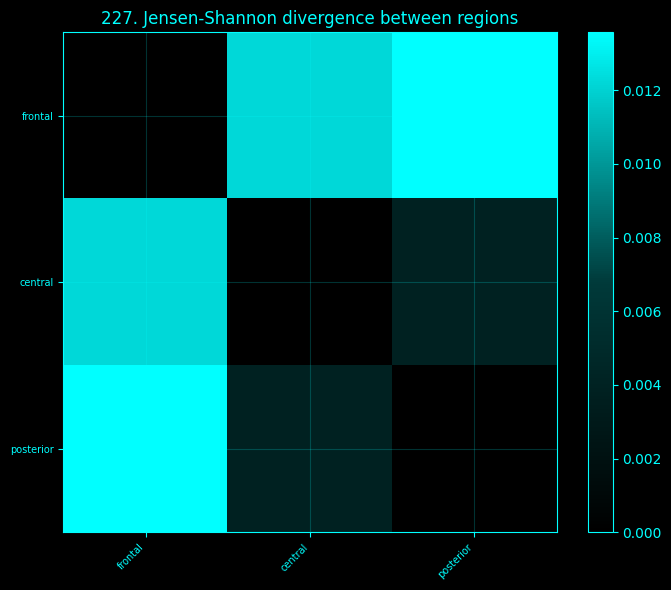

In [203]:
# =======================================================
# 227. Jensen-Shannon divergence between regions
# Explicit method implementation — no catalogue dispatcher.
# Mathematics: Regional mean signals are converted to amplitude distributions on common bins and
# pairwise Jensen–Shannon divergences are assembled into a regional matrix.
# =======================================================
def _entropy_method_227():
    X = _ent_x
    y = _ent_y
    G, W, A = _corr_graph(threshold=0.35)
    powv = np.var(X, axis=0)
    n = min(8, X.shape[1])
    P = []
    edges = np.linspace(np.min(X[:, :n]), np.max(X[:, :n]), 33)
    for j in range(n):
        P.append(_safe_prob(np.histogram(X[:, j], edges)[0] + 0.5))
    p, q = (P[0], P[1])
    regs = _regions_indices()
    rp = []
    rn = []
    for name, ids in regs.items():
        if ids:
            rp.append(_safe_prob(np.histogram(np.mean(X[:, ids], axis=1), edges)[0] + 0.5))
            rn.append(name)
    M = np.array([[_jsd(a, b) for b in rp] for a in rp])
    _ent_display_result = pd.DataFrame(M, index=rn, columns=rn)
    display(_ent_display_result)
    return locals()
_ent_method_ns = _entropy_method_227()
_ent_auto_plot(227, 'Jensen-Shannon divergence between regions', _ent_method_ns, ['X', 'y', 'powv', 'n', 'P', 'edges', 'j', 'regs', 'rp', 'rn', 'M', '_ent_display_result', 'G', 'W', 'A', 'p', 'q', 'name', 'ids', 'a', 'b'])
